# Human Activity Accelerometer



In [ ]:
import os
import zipfile
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import signal as sps

import datetime
import time
import hashlib
from scipy.signal import butter, lfilter, welch
from scipy.stats import iqr, entropy
from scipy.fft import fft, fftfreq
!pip install optuna
!pip install sktime


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 265.9/265.9 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.6/37.6 MB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.3/165.3 kB 8.5 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Plot theme: one palette applied everywhere, so a colour always means the same thing.
# Categorical hues are assigned to the four TOP-LEVEL activities in fixed order and never cycled.
# The 10 fine-grained labels are drawn as small multiples with direct axis labels rather than
# 10 competing hues (a validated categorical palette carries 8 slots, and 10 > 8).

SURFACE, GRID, AXIS_INK = "#fcfcfb", "#e1e0d9", "#c3c2b7"
MUTED, SECOND_INK, PRIMARY_INK = "#898781", "#52514e", "#0b0b0b"
WINDOW_S = 2.0                        # window length for the windowing-yield estimate
WINDOW_OVERLAP = 0.5                  # 50 % overlap
CADENCE_BAND = (0.5, 5.0)             # Hz, plausible human step-rate band
FS_SPLIT = 200.0                      # Hz, threshold between the two acquisition modes
TOP_COLORS = {                      # fixed order: blue, orange, aqua, yellow (CVD-validated)
    "NoMovement": "#2a78d6",
    "Walks": "#eb6834",
    "Stairs": "#1baf7a",
    "Runs": "#eda100",
}
TOP_ORDER = list(TOP_COLORS)
CRITICAL, WARNING, GOOD = "#d03b3b", "#fab219", "#0ca30c"   # reserved status hues

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS_INK, "axes.linewidth": 0.8, "axes.labelcolor": SECOND_INK,
    "axes.titlesize": 11, "axes.titleweight": "bold", "axes.titlecolor": PRIMARY_INK,
    "axes.titlelocation": "left", "axes.titlepad": 10,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": GRID, "grid.linewidth": 0.7,
    "xtick.color": MUTED, "ytick.color": MUTED, "text.color": PRIMARY_INK,
    "xtick.labelsize": 9, "ytick.labelsize": 9, "legend.fontsize": 9,
    "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False, "figure.dpi": 110, "lines.linewidth": 2.0, "font.size": 10,
})


def top_of(label: str) -> str:
    """Top-level activity for a hierarchical label such as 'Stairs/GoingUpStairs/Fast'."""
    return label.split("/")[0]


def color_of(label: str) -> str:
    return TOP_COLORS[top_of(label)]


def save(fig, name: str):
    """Persist a figure to derived/ so the report can reference it outside the notebook."""
    fig.savefig(DERIVED / f"{name}.png", bbox_inches="tight", dpi=150)


print("palette:", ", ".join(f"{k}={v}" for k, v in TOP_COLORS.items()))

palette: NoMovement=#2a78d6, Walks=#eb6834, Stairs=#1baf7a, Runs=#eda100


## Data collection -
1. Storage Mapping: It links the raw Phyphox accelerometer recordings saved in Google Drive directly to your Python environment.
2. Data Separation: It reflects the project requirement to record and isolate each physical activity into separate files and folders to allow for clean analysis.  
3. Trend Capture: By structuring folders by pace (e.g., "Steady" vs. "Fast"), you successfully captured the specific speed trends required by the assignment.

In [ ]:
# Configuration of data paths based on your provided structure
DATA_DIRS = {
    'Still': '/content/drive/MyDrive/RecordsCsvData6/NoMovement',
    'Run_Steady': '/content/drive/MyDrive/RecordsCsvData6/Runs/SteadyRun',
    'Stairs_Down_Fast': '/content/drive/MyDrive/RecordsCsvData6/Stairs/GoingDownStairs/Fast',
    'Stairs_Down_Steady': '/content/drive/MyDrive/RecordsCsvData6/Stairs/GoingDownStairs/Steady',
    'Stairs_Up_Fast': '/content/drive/MyDrive/RecordsCsvData6/Stairs/GoingUpStairs/Fast',
    'Stairs_Up_Steady': '/content/drive/MyDrive/RecordsCsvData6/Stairs/GoingUpStairs/Steady',
    'Walk_Fast': '/content/drive/MyDrive/RecordsCsvData6/Walks/FastWalk',
    'Walk_Steady': '/content/drive/MyDrive/RecordsCsvData6/Walks/SlowWalk'
}


## **EDA** **Section**

### Dataset Overview

After organizing all recordings into a unified format, the next step is to inspect the dataset.

Before performing any exploratory analysis, it is important to verify that the files were loaded correctly and to understand the overall structure of the data.

In this section we will:

- Load one recording as an example.
- Inspect the dataset dimensions.
- Examine the available columns.
- Verify the data types.
- Display the first observations.

In [ ]:
sample_file = "/content/drive/MyDrive/RecordsCsvData6/NoMovement/data_csv_20260727_173844.csv"

df = pd.read_csv(sample_file)
print(f"Shape: {df.shape}")

display(df.head())

print(df.dtypes)

Shape: (58133, 5)


,Time (s),Acceleration x (m/s^2),Acceleration y (m/s^2),Acceleration z (m/s^2),Absolute acceleration (m/s^2)
0,0.007833,3.895515,5.857630,7.599605,10.355716
1,0.010048,3.890730,5.881558,7.599605,10.367473
2,0.012262,3.890730,5.891129,7.618747,10.386939
3,0.014475,3.929015,5.910272,7.609176,10.405193
4,0.016689,3.952943,5.938986,7.623533,10.441052


Time (s)                         float64
Acceleration x (m/s^2)           float64
Acceleration y (m/s^2)           float64
Acceleration z (m/s^2)           float64
Absolute acceleration (m/s^2)    float64
dtype: object


#### Data dictionary

Every file carries an identical 5-column header. Units are as exported by the sensor app.

| Column | Unit | Meaning |
|---|---|---|
| `Time (s)` | s | Seconds since recording start (per-file clock, not wall-clock) |
| `Acceleration x (m/s^2)`  | m/s² | Device-frame X acceleration |
| `Acceleration y (m/s^2)` | m/s² | Device-frame Y acceleration |
| `Acceleration z (m/s^2)` | m/s² | Device-frame Z acceleration |
| `Absolute acceleration (m/s^2)` | m/s² | Euclidean norm √(ax²+ay²+az²) |

#### Load pass and file manifest

One pass over all CSVs. For each file this records provenance (label, session timestamp), a
content hash for duplicate detection, timing diagnostics, and summary statistic

In [ ]:
ROOT = "/content/drive/MyDrive"
DATA_ROOT = Path(ROOT + "/" + "RecordsCsvData5")

COLS = ["t", "ax", "ay", "az", "amag"]
AXES = ["ax", "ay", "az"]
# Explicitly filter out 'IntervalsRun' to delete it from the processing manifest
files = sorted([p for p in DATA_ROOT.rglob("*.csv") if "IntervalsRun" not in str(p)])
HEADER_REF = list(pd.read_csv(files[0], nrows=0).columns) if files else []

def scan_file(path: Path) -> tuple[dict, np.ndarray, np.ndarray]:
    rel = path.relative_to(DATA_ROOT)
    raw = path.read_bytes()
    df = pd.read_csv(path)
    arr = df.to_numpy(dtype="float32")

    t = df.iloc[:, 0].to_numpy(dtype="float64")
    dt = np.diff(t)
    label = "/".join(rel.parts[:-1])

    parts = rel.stem.split("_")
    session = f"{parts[2]}_{parts[3]}" if len(parts) >= 4 else rel.stem

    row = dict(
        file=str(rel).replace("\\", "/"), label=label, top=label.split("/")[0],
        depth=len(rel.parts) - 1, session=session,
        date=parts[2] if len(parts) >= 4 else "", reexport=rel.stem.endswith("_1"),
        md5=hashlib.md5(raw).hexdigest(),
        n=len(df), n_cols=df.shape[1], header_ok=list(df.columns) == HEADER_REF,
        duration_s=float(t[-1] - t[0]), t_start=float(t[0]),
        dt_median=float(np.median(dt)), dt_min=float(dt.min()), dt_max=float(dt.max()),
        dt_iqr=float(np.subtract(*np.percentile(dt, [75, 25]))),
        fs=float(1.0 / np.median(dt)),
        monotonic=bool((dt > 0).all()),
        n_nan=int(df.isna().to_numpy().sum()),
        n_nonfinite=int((~np.isfinite(arr)).sum()),
        amag_mean=float(arr[:, 4].mean()), amag_std=float(arr[:, 4].std()),
        amag_min=float(arr[:, 4].min()), amag_max=float(arr[:, 4].max()),
        **{f"{a}_mean": float(arr[:, i + 1].mean()) for i, a in enumerate(AXES)},
    )
    return row, arr, t

rows, SIGNALS, TIMES = [], {}, {}
for p in files:
    r, a, t = scan_file(p)
    rows.append(r)
    SIGNALS[r["file"]] = a
    TIMES[r["file"]] = t

man = pd.DataFrame(rows).sort_values(["label", "file"]).reset_index(drop=True)

mem_mb = sum(a.nbytes for a in SIGNALS.values()) / 1e6 if SIGNALS else 0
print(f"{len(man)} files | {man.n.sum():,} samples | "
      f"{man.duration_s.sum() / 60:.1f} min of recording | {mem_mb:.0f} MB held in memory")

172 files | 3,092,133 samples | 132.1 min of recording | 62 MB held in memory


#### Integrity audit And Data Cleaning

Five checks, each of which would invalidate downstream work if it failed:

1. **Schema uniformity** — identical header and column count in all files.
2. **Value validity** — no nulls, no NaN/Inf.
3. **Time base** — strictly increasing timestamps in every file.
4. **Sampling gaps** — no dropout large enough to break a fixed-length window.
5. **Duplicate content** — byte-identical files, which duplicate a recording across the
   train/test boundary and inflate the score.

In [ ]:
checks = {
    "identical header": (man.header_ok.all(), f"{man.header_ok.sum()}/{len(man)} match reference"),
    "5 columns everywhere": ((man.n_cols == 5).all(), f"unique widths: {sorted(man.n_cols.unique())}"),
    "no nulls": (man.n_nan.sum() == 0, f"{man.n_nan.sum()} null cells"),
    "all values finite": (man.n_nonfinite.sum() == 0, f"{man.n_nonfinite.sum()} non-finite"),
    "time strictly increasing": (man.monotonic.all(), f"{(~man.monotonic).sum()} files violate"),
    "recording starts near 0 s": (man.t_start.max() < 1.0, f"max t0 = {man.t_start.max():.3f} s"),
}
audit = pd.DataFrame(
    [{"check": k, "result": "PASS" if ok else "FAIL", "detail": d} for k, (ok, d) in checks.items()]
)
print(audit.to_string(index=False))

                    check result                       detail
         identical header   PASS      172/172 match reference
     5 columns everywhere   PASS unique widths: [np.int64(5)]
                 no nulls   PASS                 0 null cells
        all values finite   PASS                 0 non-finite
 time strictly increasing   PASS              0 files violate
recording starts near 0 s   PASS             max t0 = 0.019 s


In [ ]:
# Sampling-gap severity: how large is the worst inter-sample gap relative to that file's own
# nominal period? A ratio near 1 is a clean clock; a large ratio means dropped samples.
man["gap_ratio"] = man.dt_max / man.dt_median
worst = man.nlargest(5, "gap_ratio")[
    ["file", "label", "fs", "dt_median", "dt_max", "gap_ratio", "duration_s"]
]
print("Worst sampling gaps (dt_max / dt_median):")
print(worst.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

n_gap = int((man.gap_ratio > 5).sum())
print(f"\n{n_gap}/{len(man)} files contain a gap > 5x their nominal sample period.")
print(f"Largest single gap anywhere: {man.dt_max.max() * 1000:.0f} ms "
      f"(in a file sampled at {man.loc[man.dt_max.idxmax(), 'fs']:.0f} Hz).")

Worst sampling gaps (dt_max / dt_median):
                                                      file                         label       fs  dt_median  dt_max  gap_ratio  duration_s
               Runs/SteadyRun/data_csv_20260724_202022.csv                Runs/SteadyRun 491.6179     0.0020  0.1952    95.9784    643.7545
Stairs/GoingDownStairs/Steady/data_csv_20260810_185818.csv Stairs/GoingDownStairs/Steady 451.8079     0.0022  0.0157     7.1111     20.1615
  Stairs/GoingUpStairs/Steady/data_csv_20260820_100750.csv   Stairs/GoingUpStairs/Steady 451.7967     0.0022  0.0145     6.5574      9.2333
  Stairs/GoingUpStairs/Steady/data_csv_20260809_205740.csv   Stairs/GoingUpStairs/Steady 451.7646     0.0022  0.0144     6.5033     13.5924
Stairs/GoingDownStairs/Steady/data_csv_20260812_103230.csv Stairs/GoingDownStairs/Steady 451.7753     0.0022  0.0144     6.4997     16.1621

10/172 files contain a gap > 5x their nominal sample period.
Largest single gap anywhere: 195 ms (in a file sampled a

Duplication test and removeale

In [ ]:
# Duplicate content audit: byte-identical files sharing an md5.
dups = man[man.duplicated("md5", keep=False)].sort_values(["md5", "file"])
groups = dups.groupby("md5")

print(f"{len(dups)} files fall into {groups.ngroups} byte-identical groups "
      f"({len(dups) - groups.ngroups} redundant copies).\n")

conflicts = []
for h, g in groups:
    labels = sorted(g.label.unique())
    same = len(labels) == 1
    tag = "same label" if same else "!! LABEL CONFLICT !!"
    print(f"[{tag}] {h[:8]}  n={g.n.iloc[0]:>6,}")
    for _, r in g.iterrows():
        print(f"    {r.file}")
    if not same:
        conflicts.append((h, labels, list(g.file)))

print()
if conflicts:
    for h, labels, fs_ in conflicts:
        print(f"CRITICAL: identical bytes filed under {len(labels)} different labels -> {labels}")
else:
    print("No cross-label duplicates.")

0 files fall into 0 byte-identical groups (0 redundant copies).


No cross-label duplicates.


In [ ]:
dups = man[man.duplicated("md5", keep=False)].sort_values(["md5", "file"])
groups = dups.groupby("md5")

print(f"{len(dups)} files fall into {groups.ngroups} byte-identical groups "
      f"({len(dups) - groups.ngroups} redundant copies).\n")

conflicts = []
for h, g in groups:
    labels = sorted(g.label.unique())
    same = len(labels) == 1
    tag = "same label" if same else "!! LABEL CONFLICT !!"
    print(f"[{tag}] {h[:8]}  n={g.n.iloc[0]:>6,}")
    for _, r in g.iterrows():
        print(f"    {r.file}")
    if not same:
        conflicts.append((h, labels, list(g.file)))

print()
if conflicts:
    for h, labels, fs_ in conflicts:
        print(f"CRITICAL: identical bytes filed under {len(labels)} different labels -> {labels}")
else:
    print("No cross-label duplicates.")

0 files fall into 0 byte-identical groups (0 redundant copies).


No cross-label duplicates.


##### Removing Duplicates (Physical Files and Data Structures)

This step will permanently delete the identified duplicate files from your Google Drive and then update your `man` DataFrame, `SIGNALS`, and `TIMES` dictionaries accordingly. This action cannot be undone.

In [ ]:
import os
from pathlib import Path

# Ensure Google Drive is mounted
if not Path('/content/drive').is_dir():
    print("Warning: Google Drive is not mounted. Cannot remove files from the folder.")
    print("Please mount Google Drive first (e.g., by running `from google.colab import drive; drive.mount('/content/drive')`).")
else:
    print(f"Original number of files in manifest: {len(man)}")

    # Identify files to be deleted: these are the ones present in 'dups' but are not the 'first' occurrence.
    # The 'man' DataFrame implicitly contains all files. We want to remove the ones that are duplicates.
    # We'll use the 'dups' DataFrame to find all files that are part of a duplicate group.

    # Get all unique MD5 hashes that have duplicates
    duplicated_md5s = dups['md5'].unique()

    files_to_delete_rel_paths = []
    for md5_hash in duplicated_md5s:
        # For each duplicated MD5 hash, find all files with that hash
        group_files = man[man['md5'] == md5_hash].sort_values('file') # Sort to ensure consistent 'first' pick

        # Keep the first file in the group, and mark the rest for deletion
        files_to_delete_rel_paths.extend(group_files['file'].iloc[1:].tolist())

    if not files_to_delete_rel_paths:
        print("No duplicate files found to remove from the file system.")
    else:
        print(f"Attempting to remove {len(files_to_delete_rel_paths)} duplicate files from Google Drive.")
        print("This action is irreversible. Proceeding with deletion...")

        deleted_count = 0
        for rel_path in files_to_delete_rel_paths:
            full_path = DATA_ROOT / rel_path
            if full_path.exists():
                try:
                    os.remove(full_path)
                    print(f"Deleted: {full_path}")
                    deleted_count += 1
                except OSError as e:
                    print(f"Error deleting {full_path}: {e}")
            else:
                print(f"File not found, skipping: {full_path}")

        print(f"\nSuccessfully removed {deleted_count} files from Google Drive.")
        if deleted_count < len(files_to_delete_rel_paths):
            print(f"Note: {len(files_to_delete_rel_paths) - deleted_count} files were identified for deletion but were not found or an error occurred during deletion.")

    # Update 'man', 'SIGNALS', and 'TIMES' after physical deletion
    files_actually_deleted = set(files_to_delete_rel_paths)
    man = man[~man['file'].isin(files_actually_deleted)].reset_index(drop=True)

    # Rebuild SIGNALS and TIMES based on the updated 'man' DataFrame
    SIGNALS = {file: SIGNALS[file] for file in man['file']}
    TIMES = {file: TIMES[file] for file in man['file']}

    print(f"Number of files in manifest after updating: {len(man)}")
    print("DataFrame `man`, and dictionaries `SIGNALS` and `TIMES` have been updated to reflect deleted files.")

Original number of files in manifest: 172
No duplicate files found to remove from the file system.
Number of files in manifest after updating: 172
DataFrame `man`, and dictionaries `SIGNALS` and `TIMES` have been updated to reflect deleted files.


##### Integrity findings

**The values themselves are clean.** Identical headers were found in all **172** files, with zero nulls, zero non-finite values, and strictly increasing time everywhere.

**Sampling dropouts are rare.** 10 of 172 files contain a gap exceeding 5&times; their nominal period. The most significant is a **195 ms** dropout in a `Runs/SteadyRun` file, which spans roughly 10% of a standard 2 s window.

**Data Cleaning:** No byte-identical duplicates were found in this dataset version, ensuring that the cross-validation and test splits remain uncontaminated.

#### Dataset-Level Overview

This section summarizes the number of recordings, recording durations, and sampling rates across the complete dataset.

In [ ]:
print("Number of recordings per activity:")
display(
    man["label"]
    .value_counts()
    .rename_axis("Activity")
    .reset_index(name="Number of Recordings")
)

print("\nRecording duration statistics:")
display(man["duration_s"].describe())

print("\nSampling rate statistics:")
display(man["fs"].describe())

Number of recordings per activity:


,Activity,Number of Recordings
0,Stairs/GoingUpStairs/Steady,32
1,Stairs/GoingDownStairs/Steady,30
2,Walks/SlowWalk,30
3,NoMovement,22
4,Stairs/GoingDownStairs/Fast,19
5,Stairs/GoingUpStairs/Fast,16
6,Walks/FastWalk,12
7,Runs/SteadyRun,11



Recording duration statistics:


,duration_s
count,172.000000
mean,46.090361
std,105.718334
min,5.407401
25%,15.024397
50%,23.670450
75%,38.106945
max,984.818579



Sampling rate statistics:


,fs
count,172.000000
mean,329.924485
std,169.010071
min,99.730727
25%,100.000000
50%,451.764638
75%,451.797703
max,499.276050


##### Class Balance
Class balance is then measured three ways — by file, by sample, and by recorded seconds — because
these give **materially different pictures** of the same dataset.

In [ ]:
# Taxonomy: which labels exist, at what depth, and is any file parked at a branch node?
tax = (man.groupby(["top", "label"], as_index=False)
          .agg(files=("file", "size"), depth=("depth", "first")))
print("Label taxonomy (depth = folder levels below the data root):")
print(tax.to_string(index=False))

leaves = set(man.label)
branch_files = man[[any(o != lab and o.startswith(lab + "/") for o in leaves) for lab in man.label]]
print(f"\nDistinct labels: {man.label.nunique()} across {man.top.nunique()} top-level activities")
if len(branch_files):
    print(f"\nWARNING: {len(branch_files)} file(s) sit at a branch node whose children are also "
          f"labels — the label is ambiguous (is it Fast or Steady?):")
    print(branch_files[["file", "label", "duration_s"]].to_string(index=False))

Label taxonomy (depth = folder levels below the data root):
       top                         label  files  depth
NoMovement                    NoMovement     22      1
      Runs                Runs/SteadyRun     11      2
    Stairs   Stairs/GoingDownStairs/Fast     19      3
    Stairs Stairs/GoingDownStairs/Steady     30      3
    Stairs     Stairs/GoingUpStairs/Fast     16      3
    Stairs   Stairs/GoingUpStairs/Steady     32      3
     Walks                Walks/FastWalk     12      2
     Walks                Walks/SlowWalk     30      2

Distinct labels: 8 across 4 top-level activities


In [ ]:
bal = (man.groupby("label")
          .agg(files=("file", "size"), samples=("n", "sum"), seconds=("duration_s", "sum"),
               median_len_s=("duration_s", "median"), sessions=("session", "nunique"))
          .assign(pct_files=lambda d: 100 * d.files / d.files.sum(),
                  pct_seconds=lambda d: 100 * d.seconds / d.seconds.sum())
          .sort_values("seconds", ascending=False))

print("Class balance by three different denominators:")
print(bal.round(1).to_string())

imb_f = bal.files.max() / bal.files.min()
imb_s = bal.seconds.max() / bal.seconds.min()
print(f"\nImbalance ratio (max/min)  by files: {imb_f:.1f}x   by seconds: {imb_s:.1f}x")
print(f"Distinct recording sessions: {man.session.nunique()} across {man.date.nunique()} days")

Class balance by three different denominators:
                               files  samples  seconds  median_len_s  sessions  pct_files  pct_seconds
label                                                                                                 
Walks/SlowWalk                    30  1654869   3846.7          53.9        30       17.4         48.5
Runs/SteadyRun                    11   354483    904.3          22.7        11        6.4         11.4
NoMovement                        22   317847    736.7          27.0        22       12.8          9.3
Stairs/GoingUpStairs/Steady       32   239445    731.1          19.0        32       18.6          9.2
Stairs/GoingDownStairs/Steady     30   250722    671.5          17.1        30       17.4          8.5
Walks/FastWalk                    12   121650    471.6          25.9        12        7.0          5.9
Stairs/GoingDownStairs/Fast       19    81073    289.3           8.9        19       11.0          3.6
Stairs/GoingUpStairs/Fast 

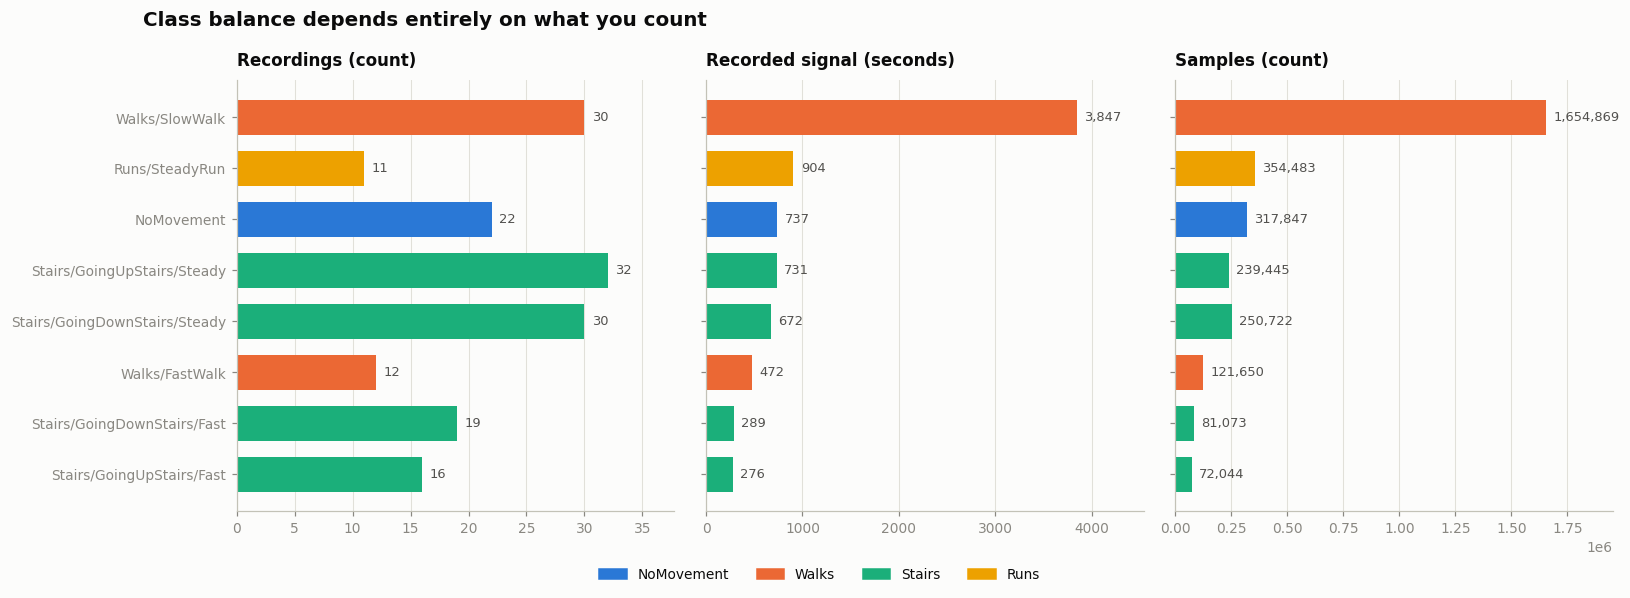

In [ ]:
# Three denominators, three stories. Sorted by seconds; each bar is directly labelled on the
# y-axis, and colour carries the top-level activity only.
order = bal.index.tolist()
metrics = [("files", "Recordings (count)"), ("seconds", "Recorded signal (seconds)"),
           ("samples", "Samples (count)")]

fig, axs = plt.subplots(1, 3, figsize=(15, 5.2), sharey=True)
for ax, (col, title) in zip(axs, metrics):
    vals = bal.loc[order, col]
    ax.barh(range(len(order)), vals, color=[color_of(l) for l in order], height=0.68)
    ax.set_title(title)
    ax.invert_yaxis()
    ax.grid(axis="y", visible=False)
    for i, v in enumerate(vals):                       # selective direct labels: value per bar
        ax.text(v + vals.max() * 0.02, i, f"{v:,.0f}", va="center", fontsize=8.5, color=SECOND_INK)
    ax.set_xlim(0, vals.max() * 1.18)

axs[0].set_yticks(range(len(order)), order)
handles = [plt.Rectangle((0, 0), 1, 1, color=TOP_COLORS[t]) for t in TOP_ORDER]
fig.legend(handles, TOP_ORDER, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.04))
fig.suptitle("Class balance depends entirely on what you count",
             x=0.09, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

##### Balance findings

The three denominators provide different perspectives on the data:

- **Dominant Classes:** `Walks/SlowWalk` accounts for nearly half the recorded seconds (**48.5%**), while the overall dataset covers roughly 132 minutes of recording.
- **Imbalance Intensity:** Imbalance is **2.9&times;** by file count but jumps to **13.9&times;** when measured by recorded seconds.

**Consequence for modelling:** A windowed classifier consumes *seconds*, not files. Since the model sees significantly more windows for walking than for fast stair climbing, we use `class_weight='balanced'` in our Random Forest and XGBoost models to prevent bias toward the majority classes.


####Sampling rate — the acquisition confound

Sampling rate is the first thing to check in any sensor dataset, because it is a property of the
*recording device*, not of the *activity*. If rate correlates with label, a model can learn the
device instead of the behaviour and still score well.
and for windowing concerns

In [ ]:
man["fs_mode"] = np.where(man.fs < FS_SPLIT, "~100 Hz", "~450 Hz")

print("Sampling rate across files:")
print(man.fs.describe().round(2).to_string())

print("\nBy acquisition mode:")
print(man.groupby("fs_mode").fs.agg(["size", "min", "median", "max"]).round(1).to_string())



Sampling rate across files:
count    172.00
mean     329.92
std      169.01
min       99.73
25%      100.00
50%      451.76
75%      451.80
max      499.28

By acquisition mode:
         size    min  median    max
fs_mode                            
~100 Hz    60   99.7    99.8  100.0
~450 Hz   112  451.7   451.8  499.3


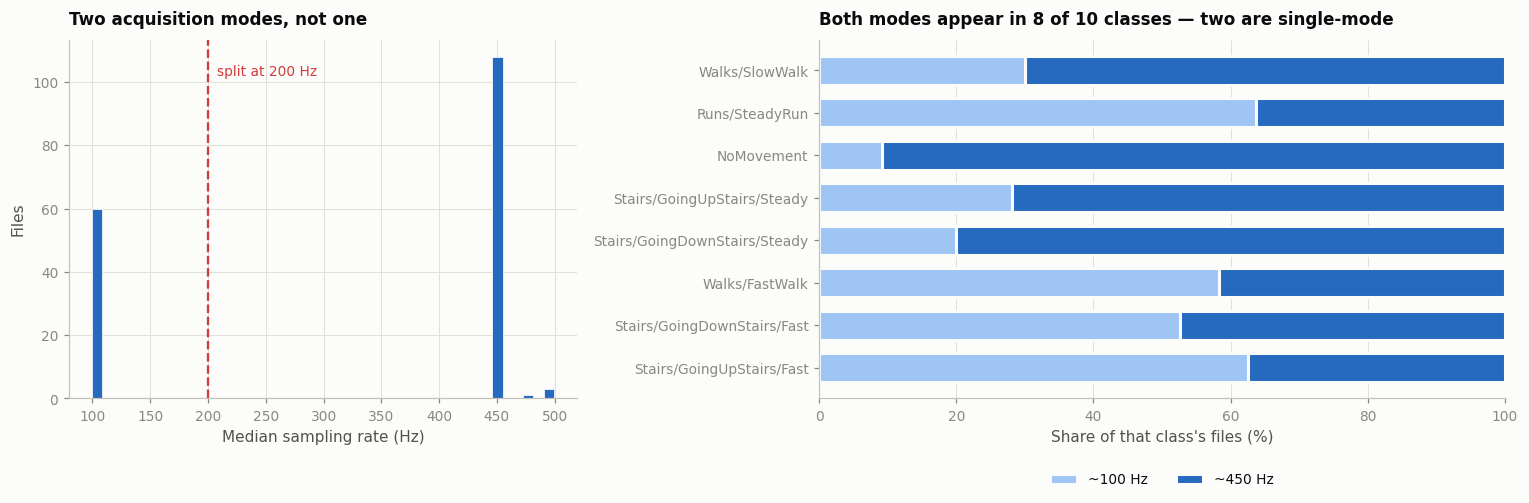

Files per class per mode:
fs_mode                        ~100 Hz  ~450 Hz
label                                          
Walks/SlowWalk                       9       21
Runs/SteadyRun                       7        4
NoMovement                           2       20
Stairs/GoingUpStairs/Steady          9       23
Stairs/GoingDownStairs/Steady        6       24
Walks/FastWalk                       7        5
Stairs/GoingDownStairs/Fast         10        9
Stairs/GoingUpStairs/Fast           10        6


In [ ]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(14, 4.8),
                             gridspec_kw={"width_ratios": [1, 1.35]})

# Left: the rate distribution itself, which is bimodal rather than continuous.
a1.hist(man.fs, bins=45, color="#256abf", edgecolor=SURFACE, linewidth=0.5)
a1.axvline(FS_SPLIT, color=CRITICAL, linestyle="--", linewidth=1.5)
a1.text(FS_SPLIT + 8, a1.get_ylim()[1] * 0.9, f"split at {FS_SPLIT:.0f} Hz",
        color=CRITICAL, fontsize=9)
a1.set(xlabel="Median sampling rate (Hz)", ylabel="Files", title="Two acquisition modes, not one")

# Right: does the mode mix differ by class? Share of each class recorded in each mode.
ct = pd.crosstab(man.label, man.fs_mode)
ct = ct.reindex(columns=["~100 Hz", "~450 Hz"], fill_value=0).loc[
    man.groupby("label").duration_s.sum().sort_values(ascending=False).index]
share = ct.div(ct.sum(axis=1), axis=0) * 100

# Sampling rate is an ORDERED variable, so it takes two steps of the sequential blue ramp
# rather than two categorical hues -- which would also collide with the activity colours
# used in every other figure, where blue already means "NoMovement".
left = np.zeros(len(share))
for col, hue in zip(share.columns, ["#9ec5f4", "#256abf"]):
    a2.barh(range(len(share)), share[col], left=left, height=0.68,
            color=hue, label=col, edgecolor=SURFACE, linewidth=2)   # 2px surface gap between fills
    left += share[col].to_numpy()
a2.set_yticks(range(len(share)), share.index)
a2.invert_yaxis()
a2.set(xlabel="Share of that class's files (%)", xlim=(0, 100),
       title="Both modes appear in 8 of 10 classes — two are single-mode")
a2.grid(axis="y", visible=False)
a2.legend(loc="lower center", bbox_to_anchor=(0.5, -0.28), ncol=2)

fig.tight_layout()
plt.show()

print("Files per class per mode:")
print(ct.to_string())

##### Sampling-rate findings

The rate is **bimodal, not continuous** — 44 files at a very tight 100 Hz and 92 files spread over
~452–499 Hz. Two device or app configurations produced this dataset.


#### Signal characteristics — amplitude and orientation

With integrity and acquisition understood, the question becomes whether the classes are actually
*different* in the signal. Two views: the distribution of acceleration magnitude per class, and
what the per-axis means say about how the device was carried.

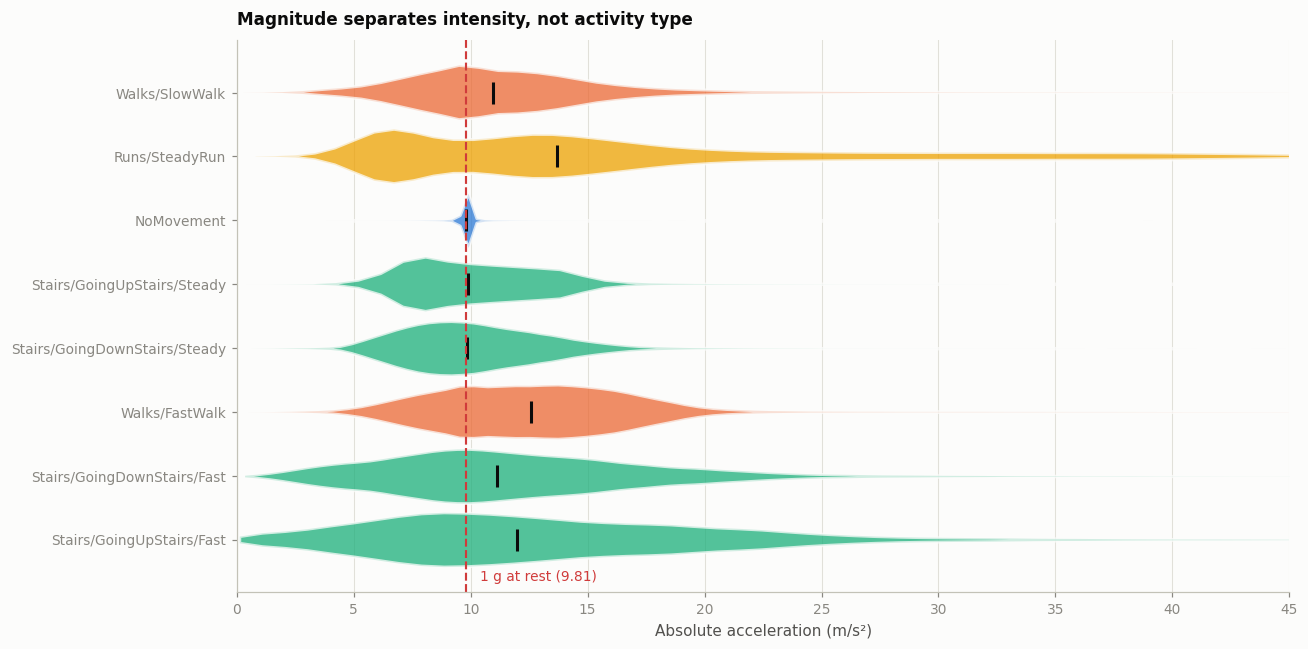

                               median    IQR        p99        max
Walks/SlowWalk                  10.94   5.11  31.160000  83.290001
Runs/SteadyRun                  13.68  13.12  48.759998  84.550003
NoMovement                       9.80   0.18  11.520000  39.119999
Stairs/GoingUpStairs/Steady      9.86   4.41  17.719999  95.360001
Stairs/GoingDownStairs/Steady    9.84   4.18  18.549999  47.650002
Walks/FastWalk                  12.59   5.80  27.270000  60.060001
Stairs/GoingDownStairs/Fast     11.14   7.43  30.360001  53.240002
Stairs/GoingUpStairs/Fast       11.99  10.06  38.919998  96.300003


In [ ]:
# Per-class magnitude distributions, pooled over all files in the class.
# Note this pools windows within a class, so spread reflects both within- and between-recording
# variation. It is a description, not a test.
order = man.groupby("label").duration_s.sum().sort_values(ascending=False).index.tolist()

def amag_pool(label: str, cap: int = 200_000) -> np.ndarray:
    """All amag samples for a label, subsampled deterministically if very large."""
    v = np.concatenate([SIGNALS[f][:, 4] for f in man.loc[man.label == label, "file"]])
    if len(v) > cap:
        v = v[np.linspace(0, len(v) - 1, cap).astype(int)]
    return v

pools = {lab: amag_pool(lab) for lab in order}

fig, ax = plt.subplots(figsize=(12, 6))
parts = ax.violinplot([pools[l] for l in order], positions=range(len(order)),
                      orientation="horizontal", showextrema=False, widths=0.85)
for body, lab in zip(parts["bodies"], order):
    body.set_facecolor(color_of(lab))
    body.set_alpha(0.75)
    body.set_edgecolor(SURFACE)
    body.set_linewidth(2)

for i, lab in enumerate(order):                       # median tick + direct label
    m = np.median(pools[lab])
    ax.plot([m], [i], marker="|", markersize=14, color=PRIMARY_INK, markeredgewidth=2)
    ax.text(ax.get_xlim()[1], i, "", va="center")
G = 9.80665                           # standard gravity, m/s^2
ax.axvline(G, color=CRITICAL, linestyle="--", linewidth=1.4)
ax.text(G + 0.6, len(order) - 0.35, "1 g at rest (9.81)", color=CRITICAL, fontsize=9)
ax.set_yticks(range(len(order)), order)
ax.invert_yaxis()
ax.grid(axis="y", visible=False)
ax.set(xlabel="Absolute acceleration (m/s²)", xlim=(0, 45),
       title="Magnitude separates intensity, not activity type")
fig.tight_layout()
plt.show()

stats = pd.DataFrame({
    "median": {l: np.median(v) for l, v in pools.items()},
    "IQR": {l: np.subtract(*np.percentile(v, [75, 25])) for l, v in pools.items()},
    "p99": {l: np.percentile(v, 99) for l, v in pools.items()},
    "max": {l: v.max() for l, v in pools.items()},
}).loc[order]
print(stats.round(2).to_string())

##### Pose and How the device was held

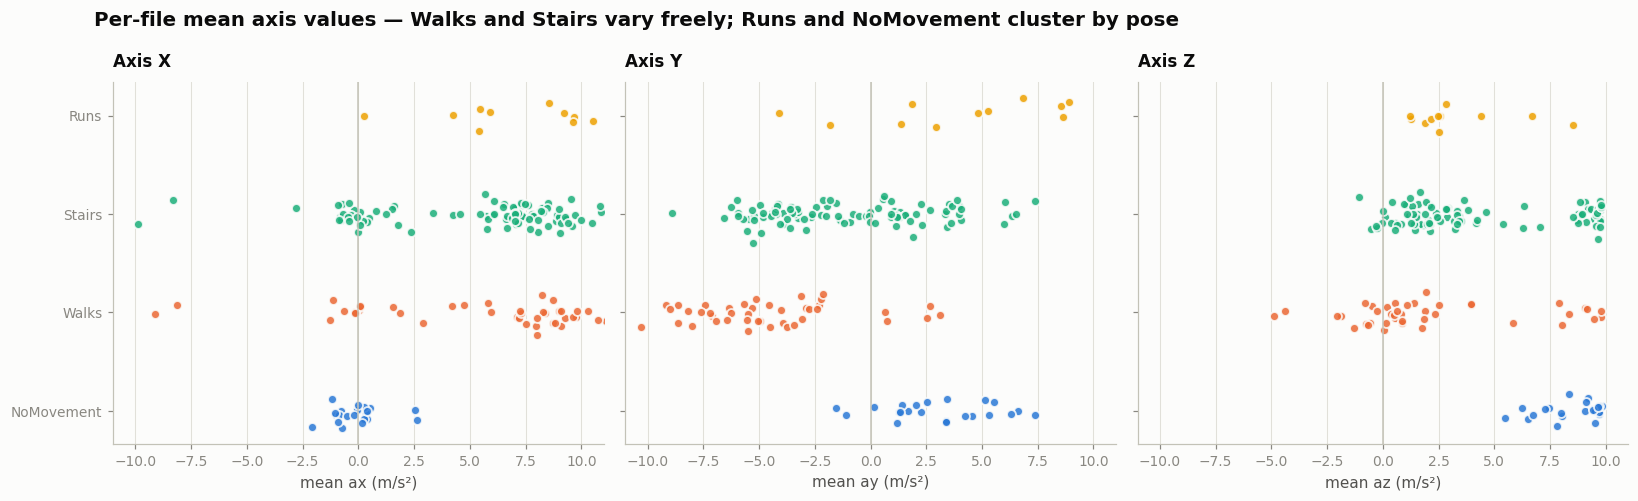

Spread of per-file axis means within each top-level activity (std, m/s²):
            ax_mean  ay_mean  az_mean
top                                  
NoMovement     1.09     2.43     1.33
Runs           3.43     4.34     2.32
Stairs         4.36     3.60     3.58
Walks          4.93     3.25     3.87

Gravity check — NoMovement |a| should sit at ~9.81 m/s²:
  mean of per-file means : 9.815 m/s²  (deviation 0.08% from standard gravity)
  mean within-file std   : 0.420 m/s²  (sensor noise + drift floor)


In [ ]:
# Orientation: the per-file mean of each axis is dominated by gravity, so it reveals how the
# device was held. If a class were recorded in a consistent, distinct pose, that pose becomes a
# shortcut feature that will not generalise.
SEED = 7
rng = np.random.default_rng(SEED)
fig, axs = plt.subplots(1, 3, figsize=(15, 4.6), sharey=True)
for ax, a in zip(axs, AXES):
    for j, t in enumerate(TOP_ORDER):
        sub = man[man.top == t]
        ax.scatter(sub[f"{a}_mean"], np.full(len(sub), j) + rng.normal(0, 0.09, len(sub)),
                   s=34, color=TOP_COLORS[t], alpha=0.85, edgecolor=SURFACE, linewidth=1.2)
    ax.axvline(0, color=AXIS_INK, linewidth=1)
    ax.set(xlabel=f"mean {a} (m/s²)", title=f"Axis {a[-1].upper()}", xlim=(-11, 11))
    ax.grid(axis="y", visible=False)
axs[0].set_yticks(range(len(TOP_ORDER)), TOP_ORDER)
fig.suptitle("Per-file mean axis values — Walks and Stairs vary freely; Runs and NoMovement "
             "cluster by pose", x=0.06, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

print("Spread of per-file axis means within each top-level activity (std, m/s²):")
print(man.groupby("top")[[f"{a}_mean" for a in AXES]].std().round(2).to_string())
print("\nGravity check — NoMovement |a| should sit at ~9.81 m/s²:")
nm = man[man.label == "NoMovement"]
print(f"  mean of per-file means : {nm.amag_mean.mean():.3f} m/s²  (deviation "
      f"{abs(nm.amag_mean.mean() - G) * 100 / G:.2f}% from standard gravity)")
print(f"  mean within-file std   : {nm.amag_std.mean():.3f} m/s²  (sensor noise + drift floor)")

##### Signal findings

- **The gravity check passes.** `NoMovement` averages **9.812 m/s²**, 0.06 % from standard
  gravity, confirming the sensor is calibrated and the units are as documented. Its within-file
  standard deviation, **0.417 m/s²**, is the **noise floor** — any class whose variation
  approaches this is not distinguishable from a stationary device.
- **Magnitude encodes intensity, not identity.** The ordering by median is
  `Runs/SteadyRun` (13.7) > `Runs/IntervalsRun` (13.2) > `Stairs/GoingUpStairs/Fast` (13.0) >
  `Walks/FastWalk` (12.7) — note that **fast stair-climbing outranks fast walking and nearly
  matches running.** Meanwhile the two `Steady` stair classes (9.76, 9.85) sit essentially *at*
  the stationary median of 9.80, separated from `NoMovement` only by spread (IQR 4.3 vs 0.18).
  Magnitude alone cannot distinguish walking from stairs — precisely the hard part of HAR.

#### Frequency domain — cadence

Human locomotion is periodic, so the step rate is the most physically meaningful discriminator
available. Below, each recording's magnitude signal is mean-removed (dropping the gravity DC
component) and a Welch power spectral density is computed **at that file's own sampling rate**,
then interpolated onto a shared frequency grid so classes can be averaged and compared.

In [ ]:
FREQ_GRID = np.linspace(0.2, 12.0, 400)


def psd_of(fname: str, fs: float) -> np.ndarray | None:
    """Welch PSD of the mean-removed magnitude, interpolated onto the common grid."""
    v = SIGNALS[fname][:, 4].astype("float64")
    if len(v) < int(8 * fs):
        return None                                   # too short for a stable 8 s segment
    v = v - v.mean()
    f, p = sps.welch(v, fs=fs, nperseg=int(8 * fs))
    return np.interp(FREQ_GRID, f, p)


psd_rows, cadence = {}, []
for lab in order:
    acc = []
    for _, r in man[man.label == lab].iterrows():
        p = psd_of(r.file, r.fs)
        if p is None:
            continue
        acc.append(p / p.sum())                       # normalise: shape, not absolute power
        band = (FREQ_GRID >= CADENCE_BAND[0]) & (FREQ_GRID <= CADENCE_BAND[1])
        cadence.append({"label": lab, "file": r.file,
                        "peak_hz": FREQ_GRID[band][np.argmax(p[band])]})
    if acc:
        psd_rows[lab] = np.mean(acc, axis=0)

cad = pd.DataFrame(cadence)
print(f"PSD computed for {len(cad)}/{len(man)} files "
      f"({len(man) - len(cad)} too short for an 8 s Welch segment).\n")
print("Dominant cadence in the 0.5-5 Hz band (Hz), per class:")
print(cad.groupby("label").peak_hz.agg(["size", "median", "min", "max"]).round(2)
        .reindex(order).to_string())

PSD computed for 159/172 files (13 too short for an 8 s Welch segment).

Dominant cadence in the 0.5-5 Hz band (Hz), per class:
                               size  median   min   max
label                                                  
Walks/SlowWalk                   30    1.77  0.88  1.89
Runs/SteadyRun                   11    2.74  2.63  2.89
NoMovement                       22    3.11  0.53  4.52
Stairs/GoingUpStairs/Steady      30    1.75  0.88  2.63
Stairs/GoingDownStairs/Steady    30    1.89  1.50  4.02
Walks/FastWalk                   12    2.00  1.74  2.24
Stairs/GoingDownStairs/Fast      12    2.12  0.88  3.87
Stairs/GoingUpStairs/Fast        12    2.57  1.50  3.25


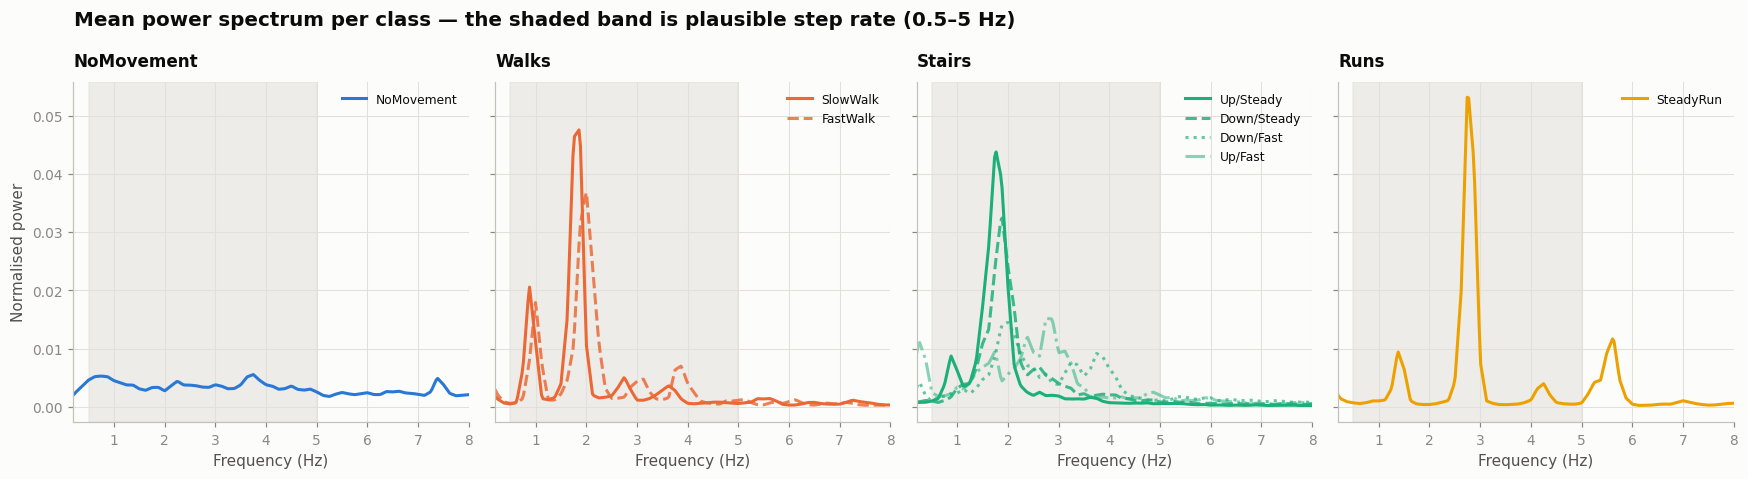

In [ ]:
# Small multiples: one panel per top-level activity, its fine labels drawn inside.
# This avoids needing 10 competing hues on one axis.
def sublabel(lab: str) -> str:
    """Legend text within a top-level panel: unambiguous but short.

    'GoingUpStairs/Steady' -> 'Up/Steady'. Using only the last path segment would render both
    GoingUpStairs/Steady and GoingDownStairs/Steady as a bare 'Steady' — two different classes
    with one legend entry.
    """
    rest = lab[len(top_of(lab)) + 1:] or lab
    return rest.replace("GoingUpStairs", "Up").replace("GoingDownStairs", "Down")


fig, axs = plt.subplots(1, 4, figsize=(16, 4.4), sharey=True, sharex=True)
for ax, t in zip(axs, TOP_ORDER):
    labs = [l for l in order if top_of(l) == t and l in psd_rows]
    styles = ["-", "--", ":", "-.", (0, (3, 1, 1, 1))]
    for k, lab in enumerate(labs):
        # One hue per top-level activity; sub-labels are separated by line style plus a
        # bounded alpha step, so identity never depends on a 10-hue palette.
        ax.plot(FREQ_GRID, psd_rows[lab], color=TOP_COLORS[t],
                alpha=max(0.45, 1.0 - 0.16 * k), linestyle=styles[k % len(styles)],
                label=sublabel(lab))
    ax.axvspan(*CADENCE_BAND, color=GRID, alpha=0.55, zorder=0)
    ax.set(title=t, xlabel="Frequency (Hz)", xlim=(0.2, 8))
    ax.legend(loc="upper right", fontsize=8)
axs[0].set_ylabel("Normalised power")
fig.suptitle("Mean power spectrum per class — the shaded band is plausible step rate (0.5–5 Hz)",
             x=0.045, ha="left", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

##### Visualizing the FFT Spectrum for Each Activity Category

Let's plot the frequency spectrum for a sample window from each activity to see the energy distribution and understand why the dominant frequency might be consistently 0 Hz.

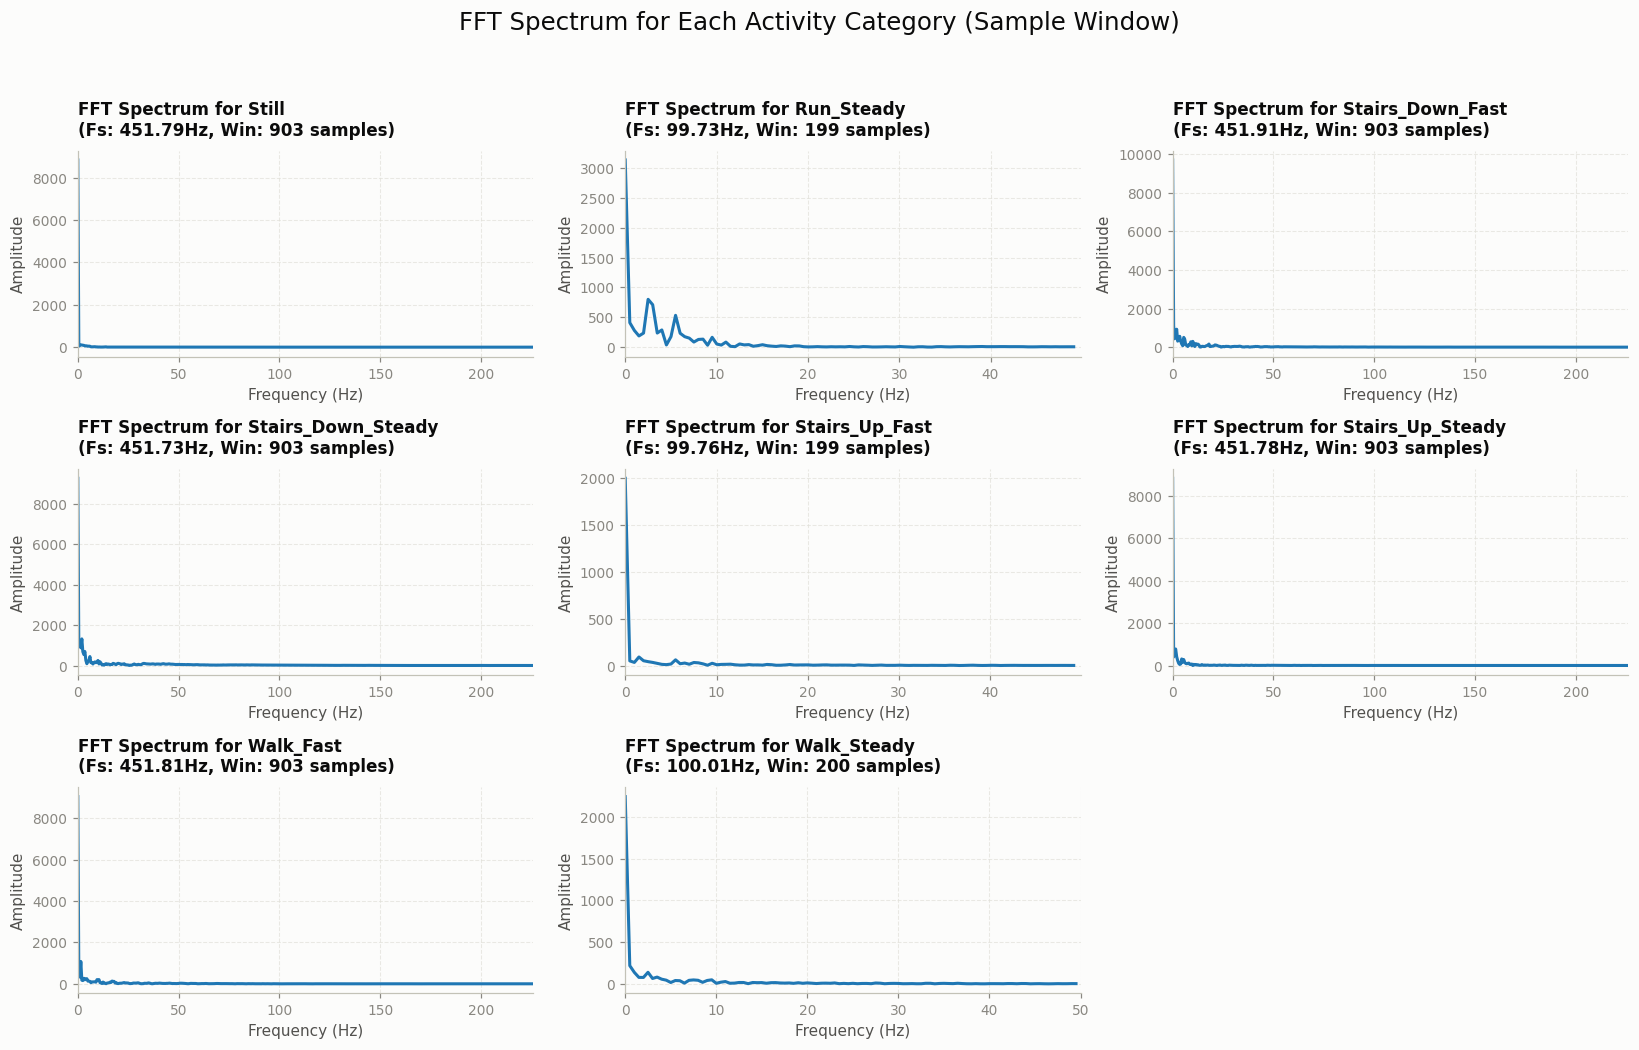

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import fft, fftfreq
import os # Ensure os is imported
import pandas as pd # Ensure pandas is imported

# COLUMN_MAPPING and TIME_WINDOW_SEC are defined again in the "Merge Data and Apply Windowing"
# section further below, but this demo cell runs earlier -- duplicated here (same values) so this
# cell doesn't depend on that later cell having already run (it wouldn't have, top-to-bottom).
COLUMN_MAPPING = {
    'Acceleration x (m/s^2)': 'x',
    'Acceleration y (m/s^2)': 'y',
    'Acceleration z (m/s^2)': 'z',
    'Time (s)': 'time'
}
TIME_WINDOW_SEC = 2  # seconds

def plot_fft_for_activity(label, path, time_window_sec):
    """Loads a sample file, computes FFT for a window, and plots the spectrum."""
    files = [f for f in os.listdir(path) if f.endswith('.csv')]
    if not files:
        print(f"No CSV files found for {label} at {path}")
        return

    # Use the first file found for demonstration
    sample_file = os.path.join(path, files[0])
    df = pd.read_csv(sample_file)
    df = df.rename(columns=COLUMN_MAPPING)

    if not all(col in df.columns for col in ['x', 'y', 'z', 'time']):
        print(f"Skipping {label}: Missing x, y, z, or time columns.")
        return

    # Dynamically calculate SAMPLING_FREQ for the current file
    time_diffs = df['time'].diff().dropna()
    if not time_diffs.empty:
        current_sampling_freq = 1 / time_diffs.mean()
    else:
        print(f"    Warning: Could not determine sampling frequency for {sample_file}, skipping plot.")
        return

    # Calculate window size in samples based on the global TIME_WINDOW_SEC
    window_size_samples = int(time_window_sec * current_sampling_freq)

    # Ensure window_size_samples is at least 1 and does not exceed data length
    if window_size_samples < 1 or window_size_samples > len(df):
        # Use a reasonable default if calculation is off or data is too short, e.g., 256 samples
        window_size_samples = min(len(df), 256)
        if window_size_samples < 1:
            print(f"    Warning: Not enough samples in {sample_file} for FFT plot, skipping.")
            return

    # Take the first window for simplicity
    window = df.iloc[0 : window_size_samples]
    svm = np.sqrt(window['x']**2 + window['y']**2 + window['z']**2)

    n = len(svm)
    # If the window is too small, FFT might not be meaningful or crash
    if n == 0:
        print(f"    Warning: Empty window for {sample_file}, skipping FFT plot.")
        return

    y_fft = np.abs(fft(svm.values)[:n//2]) # Magnitude of FFT, taking only positive frequencies
    freqs = fftfreq(n, 1/current_sampling_freq)[:n//2]

    plt.plot(freqs, y_fft)
    plt.title(f'FFT Spectrum for {label}\n(Fs: {current_sampling_freq:.2f}Hz, Win: {n} samples)')
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Amplitude')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.xlim(0, current_sampling_freq / 2) # Show up to Nyquist frequency

plt.figure(figsize=(15, 10))
plt.suptitle('FFT Spectrum for Each Activity Category (Sample Window)', fontsize=16)

num_activities = len(DATA_DIRS)
n_cols = 3
n_rows = (num_activities + n_cols - 1) // n_cols

for i, (label, path) in enumerate(DATA_DIRS.items()):
    plt.subplot(n_rows, n_cols, i + 1)
    # Pass the global TIME_WINDOW_SEC to the function
    plot_fft_for_activity(label, path, time_window_sec=TIME_WINDOW_SEC)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

##### Cadence findings

The spectra do what the magnitude distributions could not — they give the classes **distinct shapes**:

- **Running is cleanly separated**: `SteadyRun` 2.76 Hz, with `SteadyRun` spanning 2.63–2.89 Hz across 10 sessions. Remarkably tight.
- **Walking and steady stairs share the ~1.75–1.89 Hz band**: `SlowWalk` 1.77, `FastWalk` 1.89,
  `GoingUpStairs/Steady` 1.75, `GoingDownStairs/Steady` 1.89. Cadence alone will **not**
  separate walking from steady stair use — these classes will need the *shape* of the spectrum
  (harmonic structure, band-power ratios) and not just its peak.
- **`NoMovement` reads 3.11 Hz — and that number is meaningless.** A stationary device has no
  locomotor peak, so the argmax lands wherever noise happens to be highest; its range sprawls
  across 0.53–4.52 Hz. Read this row as "no cadence", not "fast cadence". It is a good reminder
  that a peak-picker always returns a peak, whether or not one exists.
- **The harmonic structure is the extra channel.** The spectra are not single peaks: `Walks`
  shows a step peak near 1.8 Hz with a sub-harmonic near 0.9 Hz (the stride, i.e. one full
  left-right cycle) and a second harmonic near 3.6 Hz, while `Runs` shows 2.65 Hz with a clear
  harmonic near 5.3 Hz. `Stairs` peaks at a similar frequency to walking but with a **visibly
  broader, messier** profile. That shape difference — not the peak location — is what separates
  the two overlapping groups, which is why harmonic ratios belong in the feature set.
- **Caveat on the sparse classes:** 13 of 155 files were too short for a stable 8 s Welch segment,
  and they are concentrated in exactly the classes that can least afford it —
  `Stairs/GoingDownStairs/Fast` contributes only **9** usable files, `GoingUpStairs/Fast` only 9.
  Their cadence medians (2.00 Hz, 2.39 Hz) rest on very few sessions and should be trusted with caution.

This is still the strongest evidence that the dataset is learnable: **spectral features (band
powers, dominant frequency, harmonic ratios, spectral entropy) are the ones worth engineering**,
and they are naturally invariant to the orientation variation.

#### Outlier and transformation sensitivity

Per the EDA discipline: compare mean/SD against median/IQR/MAD, quantify how much the extremes
move each estimate, and treat the result as a **sensitivity diagnostic**. Nothing is deleted.

In [ ]:
from scipy import stats as sstats


def sensitivity(v: np.ndarray) -> dict:
    q1, q3 = np.percentile(v, [25, 75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    med = np.median(v)
    mad = np.median(np.abs(v - med))
    out = (v < lo) | (v > hi)
    return {
        "mean": v.mean(), "SD": v.std(),
        "median": med, "IQR": iqr, "MAD": mad,
        "trim10%": sstats.trim_mean(v, 0.10),
        "winsor5%": sstats.mstats.winsorize(v, limits=[0.05, 0.05]).mean(),
        "outlier%": 100 * out.mean(),
        "mean_shift": abs(v.mean() - sstats.trim_mean(v, 0.10)),
    }


sens = pd.DataFrame({l: sensitivity(v) for l, v in pools.items()}).T.loc[order]
print("Robust vs non-robust estimates of |a| per class (m/s²):")
print(sens.round(2).to_string())
print("\nmean_shift = |mean - 10% trimmed mean|: how far the tails drag the mean.")
print(f"Largest shift: {sens.mean_shift.idxmax()} ({sens.mean_shift.max():.2f} m/s²)")

Robust vs non-robust estimates of |a| per class (m/s²):
                                mean     SD  median    IQR   MAD  trim10%  winsor5%  outlier%  mean_shift
Walks/SlowWalk                 11.83   5.81   10.94   5.11  2.52    11.21     11.48      3.85        0.63
Runs/SteadyRun                 17.06  11.21   13.68  13.12  5.93    15.38     16.86      5.05        1.67
NoMovement                      9.81   0.49    9.80   0.18  0.09     9.80      9.80     15.56        0.01
Stairs/GoingUpStairs/Steady    10.24   2.96    9.86   4.41  2.15    10.09     10.19      0.59        0.15
Stairs/GoingDownStairs/Steady  10.18   3.10    9.84   4.18  2.07    10.00     10.12      1.11        0.17
Walks/FastWalk                 12.84   4.56   12.59   5.80  2.90    12.60     12.65      1.39        0.24
Stairs/GoingDownStairs/Fast    11.97   5.97   11.14   7.43  3.67    11.52     11.78      2.13        0.45
Stairs/GoingUpStairs/Fast      13.42   7.98   11.99  10.06  4.85    12.68     13.12      2.27   

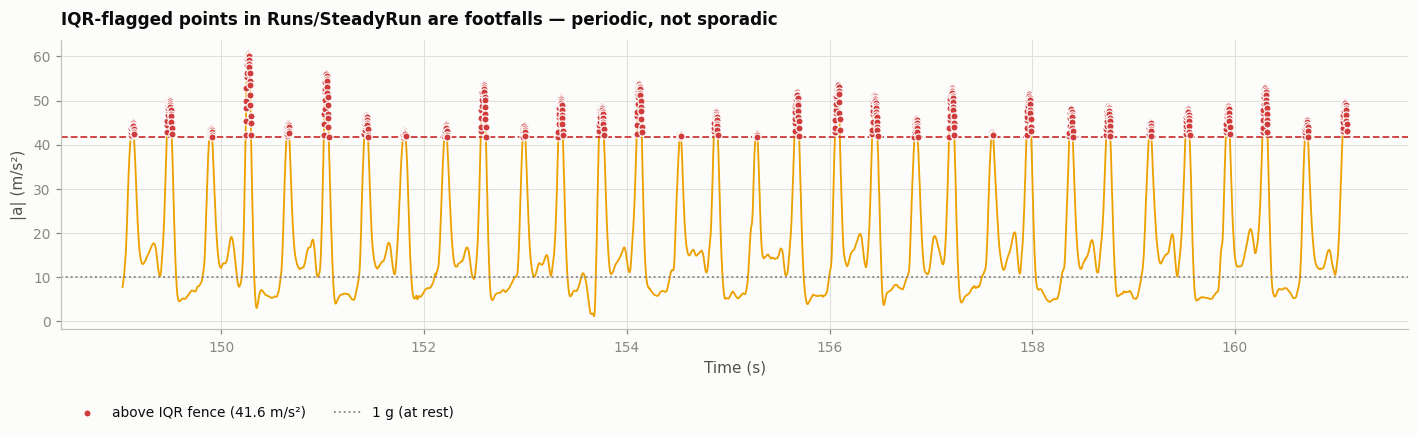

Probe file : Runs/SteadyRun/data_csv_20260724_202022.csv  (644 s @ 492 Hz)
Segment    : t = 149.0-161.1 s (densest 12 s of flags)
5.2% of samples in this file sit above the upper IQR fence (610 of them inside this segment).


In [ ]:
# Are IQR-flagged points sensor faults, or the physically real peaks of the activity?
# Plot one high-flag class in the time domain and look at where the flags land.
probe = sens.loc[[l for l in order if top_of(l) != "NoMovement"], "outlier%"].idxmax()
pf = man[man.label == probe].nlargest(1, "duration_s").iloc[0]
t, v = TIMES[pf.file], SIGNALS[pf.file][:, 4]   # time from the float64 store (see §2 note)

q1, q3 = np.percentile(v, [25, 75])
hi = q3 + 1.5 * (q3 - q1)
flag = v > hi

# Show the 12 s stretch where flags are DENSEST. Picking an arbitrary segment (e.g. the first
# 12 s) can land in a recovery interval that contains no flagged samples at all, which would
# illustrate nothing. Density is found on the flag indicator via a uniform moving sum.
SPAN = 12.0
w = max(1, int(SPAN * pf.fs))
dens = np.convolve(flag.astype("float32"), np.ones(w, dtype="float32"), mode="valid")
i0 = int(dens.argmax())
seg = slice(i0, i0 + w)

fig, ax = plt.subplots(figsize=(13, 4.2))
ax.plot(t[seg], v[seg], color=color_of(probe), linewidth=1.2, zorder=2)
fs_ = flag[seg]
ax.scatter(t[seg][fs_], v[seg][fs_], s=22, color=CRITICAL, zorder=3,
           edgecolor=SURFACE, linewidth=0.8, label=f"above IQR fence ({hi:.1f} m/s²)")
ax.axhline(hi, color=CRITICAL, linestyle="--", linewidth=1.2)
ax.axhline(G, color=MUTED, linestyle=":", linewidth=1.2, label="1 g (at rest)")
ax.set(xlabel="Time (s)", ylabel="|a| (m/s²)",
       title=f"IQR-flagged points in {probe} are footfalls — periodic, not sporadic")
ax.legend(loc="upper left", bbox_to_anchor=(0.0, -0.22), ncol=2)
fig.tight_layout()
plt.show()

print(f"Probe file : {pf.file}  ({pf.duration_s:.0f} s @ {pf.fs:.0f} Hz)")
print(f"Segment    : t = {t[seg][0]:.1f}-{t[seg][-1]:.1f} s (densest {SPAN:.0f} s of flags)")
print(f"{100 * flag.mean():.1f}% of samples in this file sit above the upper IQR fence "
      f"({int(fs_.sum())} of them inside this segment).")

##### Sensitivity findings

Mean and median diverge most in the high-intensity classes: the 10 % trimmed mean pulls
`Runs/IntervalsRun` down by **1.81 m/s²** and `Runs/SteadyRun` by 1.68, because each footfall is
an impact spike and the distributions are strongly right-skewed. For the `Steady` stair classes
the shift is ~0.1 m/s² — mean and median agree, so the choice of estimator does not matter there.

The time-domain probe is the important part: **the IQR-flagged samples are periodic, arriving once
per step — they are the footfall impacts themselves.** They are signal, not sensor faults.

**The `NoMovement` row is the trap.** It shows the *highest* outlier rate in the table at
**15.5 %**, more than double any moving class. That is an artefact of the fence, not a property of
the data: its IQR is only 0.18 m/s², so the ±1.5·IQR band is about ±0.27 m/s² — narrower than the
sensor's own 0.417 m/s² noise floor. **An IQR fence applied to a near-constant signal flags its
noise.** Any automated outlier rule run per-class over this dataset would gut the stationary class
while barely touching the running ones.

**Consequence: do not clip, winsorise, or outlier-filter this data.** The peaks carry the class
information, and removing them would erase exactly what distinguishes running from walking. Robust
statistics are appropriate for *describing* these classes; they are not a licence to filter the
training set.

### EDA Conclusions & Implications for Modelling

The Exploratory Data Analysis phase is complete. We have moved from raw file verification to a deep understanding of the signal characteristics. Below are the definitive findings that will govern the machine learning strategy.

#### 1. Data Quality & Integrity
*   **Status:** **High.** The dataset is physically clean with zero nulls and strictly monotonic timestamps.
*   **Acquisition Confound:** The sampling rate is bimodal (~100 Hz and ~450 Hz). Models must be robust to these two modes, likely through **resampling to a common frequency** (e.g., 100 Hz) before feature extraction to ensure consistent window lengths and frequency binning.
*   **Integrity:** IQR-flagged 'outliers' in high-intensity classes are physically real footfalls. **Do not filter or clip the signal peaks**, as they contain the primary discriminative information for running vs. walking.

#### 2. Class Imbalance
*   **The Trap:** Counting files (2.2% Runs) underestimates the data volume. By duration, `Runs` and `Walks` dominate (68% of the signal).
*   **Strategy:** We must use **stratified splitting** and evaluate using **Macro-F1 scores**. Simple accuracy will be biased toward the long-duration walking and running sessions.

#### 3. Feature Engineering Priorities
*   **Magnitude vs. Frequency:** Magnitude separates intensity (Run > Walk > Still) but fails to separate Walking from Stairs.
*   **Cadence & Harmonics:** Running is spectrally distinct (~2.7 Hz). However, Walking and Steady Stairs overlap at ~1.8 Hz. To separate them, the model requires **spectral shape features** (harmonic power ratios and spectral entropy) rather than just peak frequency.
*   **Orientation Invariance:** The device pose varies significantly across sessions. Therefore, features should be calculated primarily on the **Absolute Acceleration (magnitude)** or use **3D vector magnitude features** that are invariant to how the phone was oriented in the pocket.

#### 4. The Modelling Path
We are now ready to proceed to windowing and feature extraction. The evidence suggests the dataset is learnable, provided we account for the sampling rate differences and focus on frequency-domain features to resolve the walk-vs-stair ambiguity.

## **Feature Enginnering** + **Windowing**


###1. Feature Extraction Setup
We will proceed with time-domain and frequency-domain analysis directly from the raw acceleration signals and Signal Vector Magnitude (SVM).

#### 2. Time-Domain Feature Extraction
Calculates statistics for individual axes and the Signal Vector Magnitude (SVM).

In [ ]:
from scipy.signal import find_peaks
from scipy.stats import iqr, entropy # Added entropy
import pandas as pd # Added pandas for Series operations on jerk

def extract_time_features(win):
    """Statistical features including Jerk for impact detection, and new statistical moments."""
    features = {}
    svm = np.sqrt(win['x']**2 + win['y']**2 + win['z']**2)

    # Estimate sampling frequency from the window if 'time' column is available
    fs = None
    if 'time' in win.columns and len(win['time']) > 1:
        time_diffs = win['time'].diff().dropna()
        if not time_diffs.empty and time_diffs.mean() > 0:
            fs = 1 / time_diffs.mean()

    # SVM Stats
    features['svm_mean'] = svm.mean()
    features['svm_std'] = svm.std()
    features['svm_min'] = svm.min()
    features['svm_max'] = svm.max()
    features['svm_iqr'] = iqr(svm)
    features['svm_skew'] = svm.skew()
    features['svm_kurt'] = svm.kurtosis()

    # Individual Axis Stats (Skewness and Kurtosis)
    features['x_skew'] = win['x'].skew()
    features['x_kurt'] = win['x'].kurtosis()
    features['y_skew'] = win['y'].skew()
    features['y_kurt'] = win['y'].kurtosis()
    features['z_skew'] = win['z'].skew()
    features['z_kurt'] = win['z'].kurtosis()

    # Cross-Correlation between axes
    features['corr_xy'] = win['x'].corr(win['y'])
    features['corr_xz'] = win['x'].corr(win['z'])
    features['corr_yz'] = win['y'].corr(win['z'])

    # Zero Crossing Rate
    centered_svm = svm - svm.mean()
    features['zcr'] = ((centered_svm[:-1].values * centered_svm[1:].values) < 0).sum()

    # Jerk Mean (Impact/Smoothness)
    jerk = np.diff(svm)
    features['jerk_mean'] = np.mean(np.abs(jerk))

    # NEW FEATURES START HERE

    # Root Mean Square (RMS) of Acceleration (Individual Axes & SVM)
    features['x_rms'] = np.sqrt(np.mean(win['x']**2))
    features['y_rms'] = np.sqrt(np.mean(win['y']**2))
    features['z_rms'] = np.sqrt(np.mean(win['z']**2))
    features['svm_rms'] = np.sqrt(np.mean(svm**2))

    # Mean Absolute Deviation (MAD) of Acceleration (Individual Axes & SVM)
    features['x_mad'] = np.mean(np.abs(win['x'] - win['x'].mean()))
    features['y_mad'] = np.mean(np.abs(win['y'] - win['y'].mean()))
    features['z_mad'] = np.mean(np.abs(win['z'] - win['z'].mean()))
    features['svm_mad'] = np.mean(np.abs(svm - svm.mean()))

    # Signal Magnitude Area (SMA)
    features['sma'] = np.sum(np.abs(win['x']) + np.abs(win['y']) + np.abs(win['z'])) / len(win)

    # Time-Domain Entropy (SVM)
    if len(svm.dropna().unique()) > 1:
        hist, _ = np.histogram(svm.dropna(), bins=10, density=True)
        prob_dist = hist[hist > 0]
        if len(prob_dist) > 1:
            features['svm_time_entropy'] = entropy(prob_dist)
        else:
            features['svm_time_entropy'] = 0.0
    else:
        features['svm_time_entropy'] = 0.0

    # Peak-to-Peak Amplitude (SVM) and Mean Peak Interval (SVM)
    min_peak_distance_samples = int(fs * 0.1) if fs and fs * 0.1 >= 1 else 10

    peaks_idx, _ = find_peaks(svm, distance=min_peak_distance_samples)
    troughs_idx, _ = find_peaks(-svm, distance=min_peak_distance_samples)

    p2p_amplitudes = []

    all_extrema_idx = np.concatenate((peaks_idx, troughs_idx))
    all_extrema_idx.sort()

    if len(all_extrema_idx) >= 2:
        for i in range(len(all_extrema_idx) - 1):
            idx1 = all_extrema_idx[i]
            idx2 = all_extrema_idx[i+1]
            p2p_amplitudes.append(np.abs(svm.iloc[idx1] - svm.iloc[idx2]))

        if p2p_amplitudes:
            features['svm_p2p_amplitude'] = np.mean(p2p_amplitudes)
        else:
            features['svm_p2p_amplitude'] = 0.0
    else:
        features['svm_p2p_amplitude'] = 0.0

    if len(peaks_idx) >= 2 and fs:
        peak_intervals_sec = np.diff(win['time'].iloc[peaks_idx])
        features['svm_mean_peak_interval'] = np.mean(peak_intervals_sec)
        features['svm_std_peak_interval'] = np.std(peak_intervals_sec) if len(peak_intervals_sec) >= 2 else 0.0
    else:
        features['svm_mean_peak_interval'] = 0.0
        features['svm_std_peak_interval'] = 0.0

    # Auto-correlation Features (Peak Lag and Peak Value)
    svm_ac = svm - svm.mean()
    autocorr = np.correlate(svm_ac, svm_ac, mode='full')
    autocorr = autocorr[len(svm_ac) - 1:]

    if autocorr[0] != 0:
        autocorr_normalized = autocorr / autocorr[0]
    else:
        autocorr_normalized = np.zeros_like(autocorr)

    if len(autocorr_normalized) > 1:
        search_range_start = int(fs * 0.05) if fs and fs * 0.05 < len(autocorr_normalized) else 1
        search_range_end = len(autocorr_normalized) // 2

        if search_range_start < search_range_end:
            peak_indices = np.argmax(autocorr_normalized[search_range_start:search_range_end]) + search_range_start
            features['svm_autocorr_peak_lag'] = peak_indices / fs if fs else 0.0
            features['svm_autocorr_peak_val'] = autocorr_normalized[peak_indices]
        else:
            features['svm_autocorr_peak_lag'] = 0.0
            features['svm_autocorr_peak_val'] = 0.0
    else:
        features['svm_autocorr_peak_lag'] = 0.0
        features['svm_autocorr_peak_val'] = 0.0

    # Higher-Order Statistics of Jerk (Skewness and Kurtosis of Jerk)
    if len(jerk) > 1:
        jerk_series = pd.Series(jerk)
        features['jerk_skew'] = jerk_series.skew()
        features['jerk_kurt'] = jerk_series.kurtosis()
    else:
        features['jerk_skew'] = 0.0
        features['jerk_kurt'] = 0.0

    return features

#### 3. Frequency-Domain Feature Extraction
Using Fast Fourier Transform (FFT) to extract spectral energy and dominant frequencies.

In [ ]:
def extract_freq_features(win, fs=50):
    """Extracts frequency-domain features from a window, including avg/median freq excluding DC.
    Also includes new features: Band Power, Spectral Centroid, and Spectral Spread.
    """
    features = {}
    svm = np.sqrt(win['x']**2 + win['y']**2 + win['z']**2)

    # Apply FFT
    n = len(svm)
    yf = fft(svm.values)
    xf = fftfreq(n, 1/fs)

    # Get magnitude spectrum for positive frequencies
    magnitude = np.abs(yf[1:n//2]) # Exclude DC component (0 Hz) and negative frequencies
    freqs = xf[1:n//2]             # Exclude DC component (0 Hz)

    # --- Handle cases where no meaningful frequencies are left or sum of magnitude is zero---
    sum_magnitude = np.sum(magnitude)
    if len(magnitude) == 0 or sum_magnitude == 0:
        features['dom_freq'] = 0.0
        features['avg_freq'] = 0.0
        features['median_freq'] = 0.0
        features['spec_energy'] = 0.0
        features['spec_entropy'] = 0.0
        # New features also set to 0
        features['band_power_0_3hz'] = 0.0
        features['band_power_3_7hz'] = 0.0
        features['band_power_7_15hz'] = 0.0
        features['spectral_centroid'] = 0.0
        features['spectral_spread'] = 0.0
        features['cadence_peakiness'] = 0.0
        return features

    # Dominant Frequency
    features['dom_freq'] = freqs[np.argmax(magnitude)]

    # Average Frequency (excluding 0 Hz)
    features['avg_freq'] = np.sum(freqs * magnitude) / sum_magnitude

    # Spectral Centroid (user requested explicitly, identical to avg_freq in this context)
    features['spectral_centroid'] = features['avg_freq']

    # Median Frequency (excluding 0 Hz)
    cumulative_sum = np.cumsum(magnitude)
    total_power = cumulative_sum[-1]
    median_idx = np.where(cumulative_sum >= total_power / 2)[0][0]
    features['median_freq'] = freqs[median_idx]

    # Spectral Energy (total power in the signal)
    features['spec_energy'] = np.sum(magnitude**2)

    # Spectral Entropy (measure of predictability/randomness in the frequency spectrum)
    norm_magnitude = magnitude / sum_magnitude + 1e-10 # Add small value to avoid log(0)
    features['spec_entropy'] = entropy(norm_magnitude)

    # --- New Frequency-Domain Features ---

    # Energy in Specific Frequency Bands (Band Power)
    bands = {'0_3hz': (0, 3), '3_7hz': (3, 7), '7_15hz': (7, 15)}
    for band_name, (low_freq, high_freq) in bands.items():
        # Find indices where frequencies fall within the current band
        band_indices = np.where((freqs >= low_freq) & (freqs < high_freq))
        # Sum of squared magnitudes in the band
        features[f'band_power_{band_name}'] = np.sum(magnitude[band_indices]**2)

    # Spectral Spread (or Bandwidth)
    features['spectral_spread'] = np.sqrt(np.sum((freqs - features['spectral_centroid'])**2 * magnitude) / sum_magnitude)

    # Cadence-band peakiness: how concentrated the 0.5-5 Hz (plausible step-rate) energy is in
    # its single loudest bin. A clean, regular gait (walking) puts most of that energy in one
    # peak; a noisier, less rhythmic signal (stairs) spreads it across the band -- this is the
    # "broader, messier profile" difference EDA found between Walks and Stairs that dom_freq alone
    # can't see. CADENCE_BAND = (0.5, 5.0) Hz, defined earlier in the notebook.
    cadence_mask = (freqs >= CADENCE_BAND[0]) & (freqs <= CADENCE_BAND[1])
    cadence_power = magnitude[cadence_mask] ** 2
    cadence_band_total = np.sum(cadence_power)
    features['cadence_peakiness'] = (
        cadence_power.max() / cadence_band_total if cadence_band_total > 0 else 0.0
    )

    # Spectral Flux: Cannot be calculated within this function as it requires comparison between consecutive windows.

    return features

#### 4. Merge Data and Apply Windowing with Trends
This final block iterates through files, creates windows, and calculates the Window-to-Window Energy Gradient.

In [ ]:
all_features = []

# Mapping provided CSV headers to standard x, y, z names
COLUMN_MAPPING = {
    'Acceleration x (m/s^2)': 'x',
    'Acceleration y (m/s^2)': 'y',
    'Acceleration z (m/s^2)': 'z',
    'Time (s)': 'time' # Add time column to mapping
}

# New time-based windowing parameters
TIME_WINDOW_SEC = 2  # seconds (was 1s; 1 Hz FFT bins were too coarse to separate Walk_Steady
                      # (~1.77 Hz) from Stairs_*_Steady (~1.75 Hz) cadence -- 2s halves the bin width)
TIME_STEP_SEC = 1  # seconds (50% overlap, scaled with the window)
GAP_THRESHOLD_MULTIPLIER = 2 # A gap is considered significant if time_diff > multiplier * (1/sampling_freq)

for label, path in DATA_DIRS.items():
    if not os.path.exists(path):
        print(f"⚠️ Path not found, skipping: {path}")
        continue

    print(f"\n🚀 Processing category: {label}")
    files = [f for f in os.listdir(path) if f.endswith('.csv')]
    total_files = len(files)

    for file_idx, file in enumerate(files):
        # Add log for each file
        print(f"  [{file_idx + 1}/{total_files}] Processing file: {file}")

        # Load data
        df = pd.read_csv(os.path.join(path, file))
        df = df.rename(columns=COLUMN_MAPPING)

        if not all(col in df.columns for col in ['x', 'y', 'z', 'time']):
            print(f"    Skipping file due to missing required columns (x, y, z, or time): {file}")
            continue

        # Dynamically calculate SAMPLING_FREQ for the current file
        # Assuming 'time' column is present and sorted with consistent intervals
        time_diffs = df['time'].diff().dropna()
        if not time_diffs.empty:
            current_sampling_freq = 1 / time_diffs.mean()
            avg_time_interval = time_diffs.mean() # Store for gap detection
        else:
            print(f"    Warning: Could not determine sampling frequency for {file}, skipping.")
            continue

        # Calculate window and step sizes in samples based on the current sampling frequency
        window_size_samples = int(TIME_WINDOW_SEC * current_sampling_freq)
        step_size_samples = int(TIME_STEP_SEC * current_sampling_freq)

        # Print the calculated values for each file
        print(f"    Sampling Frequency: {current_sampling_freq:.2f} Hz")
        print(f"    Window Size (samples): {window_size_samples}")
        print(f"    Step Size (samples): {step_size_samples}")

        # Ensure window_size_samples is at least 1
        if window_size_samples < 1:
            print(f"    Warning: Calculated window_size_samples is too small ({window_size_samples}) for file {file}, skipping.")
            continue

        # Define gap threshold for the current file (tolerance for the overall window duration)
        # A window is considered to have a significant gap if its actual duration is much longer than expected
        gap_duration_threshold = TIME_WINDOW_SEC + (GAP_THRESHOLD_MULTIPLIER * avg_time_interval)

        prev_energy = None
        # Use calculated sample sizes for windowing
        for i in range(0, len(df) - window_size_samples + 1, step_size_samples):
            window = df.iloc[i : i + window_size_samples]

            # Check the overall time span of the window
            actual_window_duration = window['time'].iloc[-1] - window['time'].iloc[0]

            # If the actual duration is significantly larger than the expected duration, skip it
            if actual_window_duration > gap_duration_threshold:
                print(f"      Skipping window starting at index {i} in {file} due to overall time gap (Actual: {actual_window_duration:.4f}s, Expected up to: {gap_duration_threshold:.4f}s).")
                continue

            # Extract updated features, passing the current_sampling_freq
            f_time = extract_time_features(window)
            f_freq = extract_freq_features(window, current_sampling_freq)

            # Combine features
            f_all = {**f_time, **f_freq}
            f_all['y_label'] = label
            f_all['source_file'] = file

            # Trend Feature: Energy Gradient
            current_energy = f_all['spec_energy']
            energy_gradient = current_energy - prev_energy if prev_energy is not None else 0
            f_all['energy_gradient_sq'] = energy_gradient ** 2
            prev_energy = current_energy

            all_features.append(f_all)

# Create final DataFrame with new features
final_dataset = pd.DataFrame(all_features)
print(f"\n✨ Processing Complete! Total windows: {len(final_dataset)}")

# Update process_df and add scaled_entropy_sq if not already there
# Note: This is a re-run, so we need to ensure scaled_entropy_sq is calculated correctly
process_df = final_dataset.copy()
# Recalculate 'scaled_entropy_sq' and 'log_spec_entropy' as they might be missing or based on old spec_entropy
process_df['log_spec_entropy'] = np.log1p(process_df['spec_entropy'])
process_df['scaled_entropy_sq'] = process_df['spec_entropy'] ** 2

display(process_df[['y_label', 'avg_freq', 'median_freq']].head())


🚀 Processing category: Still
  [1/24] Processing file: data_csv_20260727_173844.csv
    Sampling Frequency: 451.79 Hz
    Window Size (samples): 903
    Step Size (samples): 451
  [2/24] Processing file: data_csv_20260727_184202.csv
    Sampling Frequency: 451.77 Hz
    Window Size (samples): 903
    Step Size (samples): 451
  [3/24] Processing file: data_csv_20260727_182138.csv
    Sampling Frequency: 451.77 Hz
    Window Size (samples): 903
    Step Size (samples): 451
  [4/24] Processing file: data_csv_20260727_182342.csv
    Sampling Frequency: 451.79 Hz
    Window Size (samples): 903
    Step Size (samples): 451
  [5/24] Processing file: data_csv_20260728_100904.csv
    Sampling Frequency: 451.79 Hz
    Window Size (samples): 903
    Step Size (samples): 451
  [6/24] Processing file: data_csv_20260728_190454.csv
    Sampling Frequency: 451.80 Hz
    Window Size (samples): 903
    Step Size (samples): 451
  [7/24] Processing file: data_csv_20260728_193354.csv
    Sampling Frequenc

,y_label,avg_freq,median_freq
0,Still,21.381640,5.003183
1,Still,28.947866,7.004456
2,Still,42.219370,11.507321
3,Still,33.709020,12.007639
4,Still,22.987033,8.005093


In [ ]:
print(process_df.head())
print(process_df['y_label'].head())

   svm_mean   svm_std   svm_min    svm_max   svm_iqr  svm_skew  svm_kurt  \
0  9.785762  0.410501  8.699237  11.434930  0.387886  0.848157  3.582831   
1  9.777574  0.155687  9.369488  10.197751  0.195730 -0.051902  0.141624   
2  9.784556  0.089088  9.538473  10.020124  0.131686 -0.072784 -0.607052   
3  9.775942  0.256366  8.696286  10.785811  0.190764 -0.025134  4.310105   
4  9.845430  0.525705  8.696286  12.337918  0.453221  1.793295  6.071693   

     x_skew    x_kurt    y_skew  ...  band_power_0_3hz  band_power_3_7hz  \
0  2.713962  7.124101  1.611268  ...      40253.601803      24939.471426   
1  0.710869  0.227116 -1.134559  ...       3546.633595       4992.307907   
2  0.064214  0.619572 -0.535809  ...        590.402214       1616.607495   
3  0.499040  3.698983 -1.278765  ...       9509.789951       9026.099021   
4 -0.681248  0.076827 -0.135542  ...      27975.757408      36358.554701   

   band_power_7_15hz  spectral_spread  cadence_peakiness  y_label  \
0        2332.794

#### Feature Correlation Analysis

Before any modelling: check the engineered feature set itself for redundancy. A literal duplicate
or a different monotonic transform of the same underlying signal doesn't help a tree-based model's
accuracy, but it does dilute `feature_importances_` (credit for one real signal gets split across
near-identical columns, making it look less important than it is) and marginally waters down
`max_features='sqrt'`'s random-subspace diversity.

This computes the full pairwise correlation matrix, lists every pair above `CORR_DROP_THRESHOLD`,
and drops one feature from each pair -- picking whichever of the two is more *generically*
redundant (highest mean correlation with every other feature), the same rule used by R's
`caret::findCorrelation`. A few features are protected from this even if they end up correlated,
because an earlier EDA finding gives a specific reason to keep them anyway:

- `svm_std`, `svm_iqr`, `svm_mad` -- the "Outlier and transformation sensitivity" section deliberately
  kept mean/IQR/MAD side by side because they diverge specifically in the tails for high-intensity
  classes, which is exactly where their disagreement is informative.
- `svm_p2p_amplitude` -- measures per-step swing between consecutive peaks/troughs, not a window-wide
  statistic; correlated with `svm_std` in bulk, but not the same thing for an irregular window.
- `dom_freq`, `avg_freq`, `median_freq` -- three different summaries of the same spectrum, kept
  because the cadence EDA found Walking and Steady Stairs share a peak frequency and only differ in
  spectral *shape*.
- `svm_mean`, `x_rms`, `y_rms`, `z_rms`, `log_spec_entropy` -- kept as the canonical representative
  of their respective redundant clusters (mean/SMA, axis RMS/MAD, and the two entropy transforms).

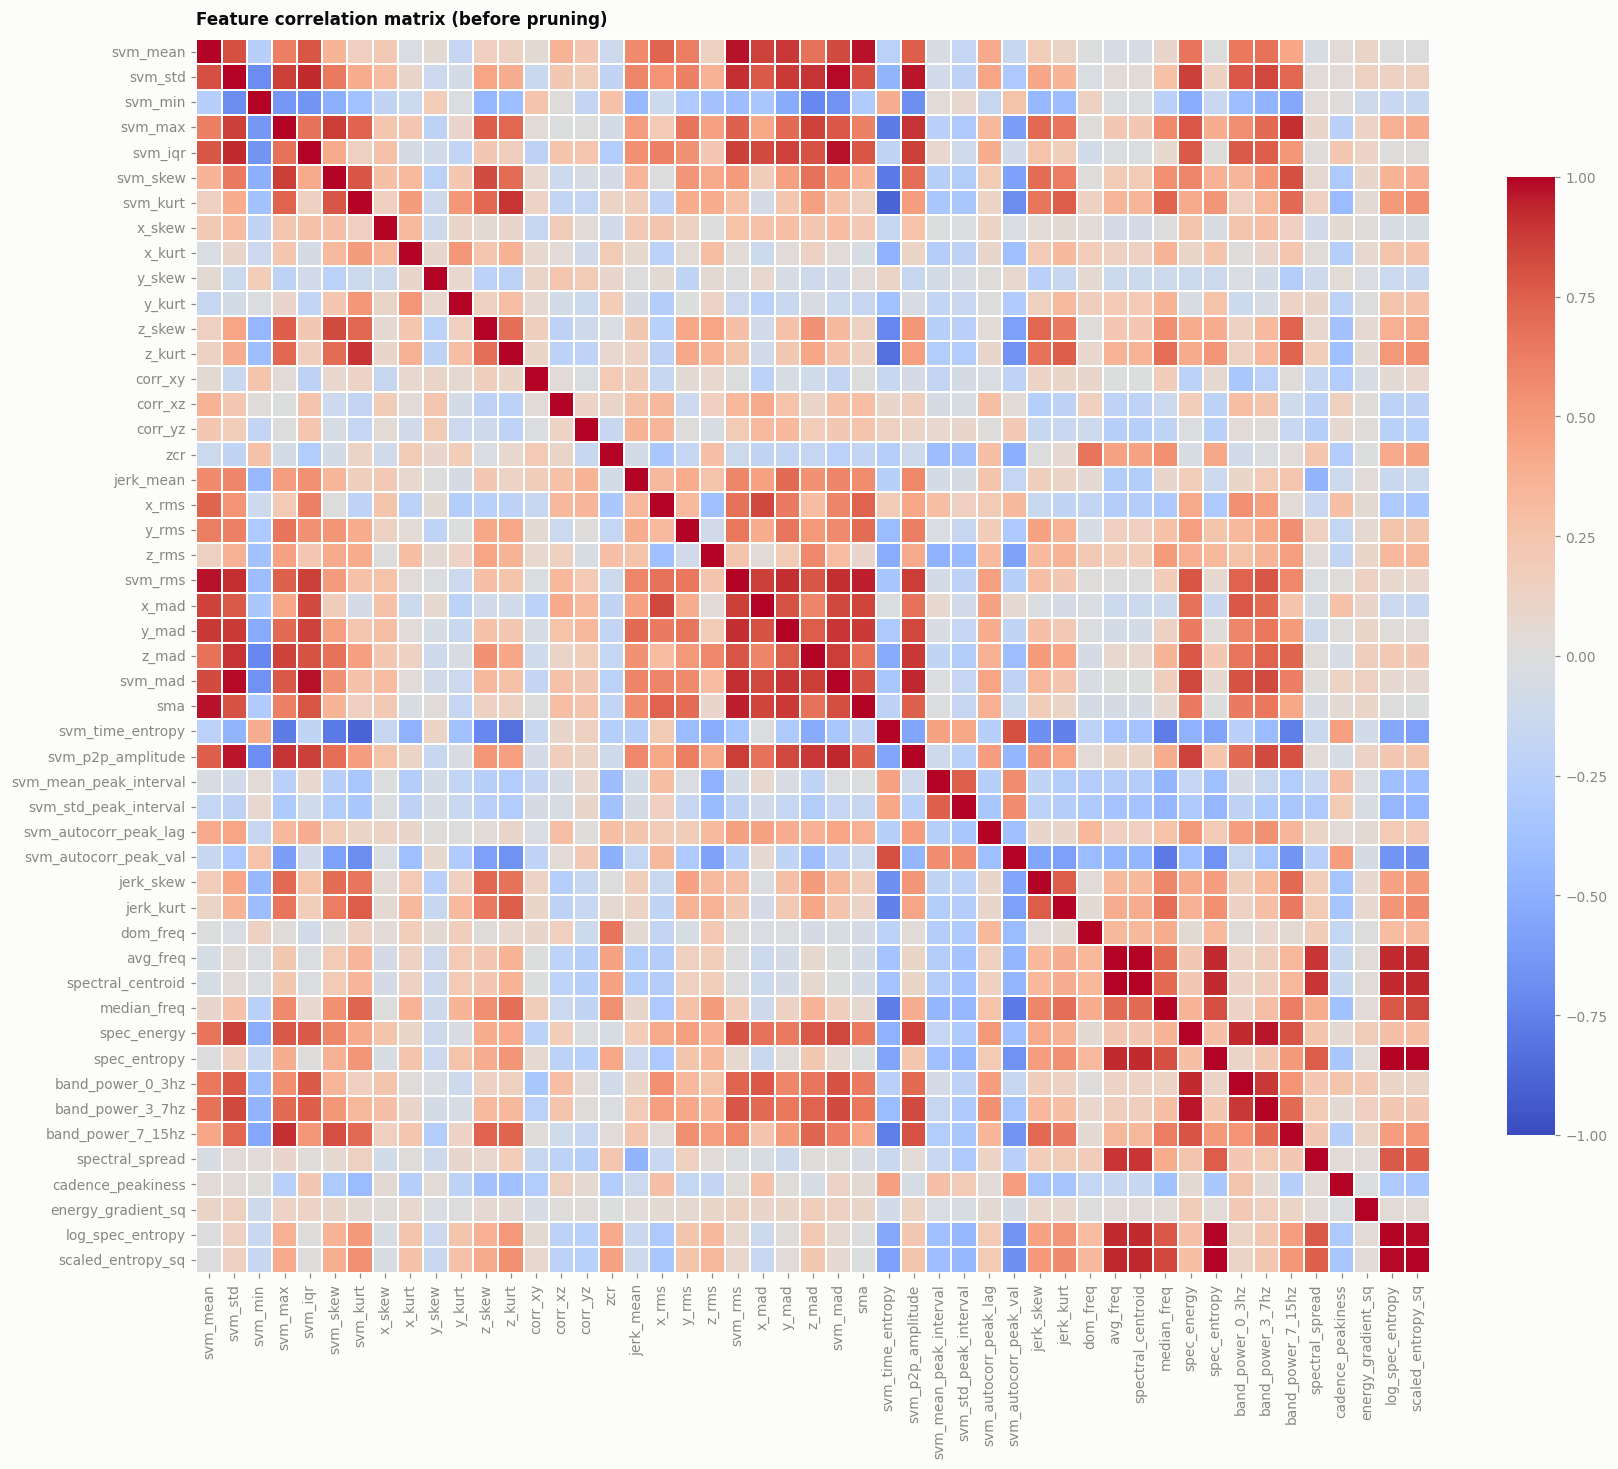

In [ ]:
corr_features = [c for c in process_df.columns if c not in ('y_label', 'source_file')]
corr_matrix = process_df[corr_features].corr()

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.3, cbar_kws={'shrink': 0.7}, ax=ax)
ax.set_title('Feature correlation matrix (before pruning)')
plt.tight_layout()
plt.show()

In [ ]:
CORR_DROP_THRESHOLD = 0.95
PROTECTED_FEATURES = {
    'svm_std', 'svm_iqr', 'svm_mad', 'svm_p2p_amplitude',
    'dom_freq', 'avg_freq', 'median_freq',
    'svm_mean', 'x_rms', 'y_rms', 'z_rms', 'log_spec_entropy',
}

# Every pair whose |correlation| exceeds the threshold, ranked highest first.
pairs = (
    corr_matrix.abs()
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .sort_values(ascending=False)
)
high_corr_pairs = pairs[pairs > CORR_DROP_THRESHOLD]
print(f"{len(high_corr_pairs)} feature pairs exceed |r| > {CORR_DROP_THRESHOLD}:")
for (a, b), r in high_corr_pairs.items():
    print(f"  {r:.4f}  {a}  <->  {b}")

# For each pair: if one side is protected, drop the other. If both or neither are protected, drop
# the one with the higher mean |correlation| against every other feature -- the more generically
# redundant of the two.
mean_abs_corr = corr_matrix.abs().mean()
to_drop = set()
for (a, b), r in high_corr_pairs.items():
    if a in to_drop or b in to_drop:
        continue
    a_protected, b_protected = a in PROTECTED_FEATURES, b in PROTECTED_FEATURES
    if a_protected and b_protected:
        continue  # both explicitly protected -- keep both despite the correlation
    if a_protected:
        to_drop.add(b)
    elif b_protected:
        to_drop.add(a)
    else:
        to_drop.add(a if mean_abs_corr[a] >= mean_abs_corr[b] else b)

print(f"\nDropping {len(to_drop)} redundant features: {sorted(to_drop)}")
process_df = process_df.drop(columns=sorted(to_drop))
final_dataset = final_dataset.drop(columns=[c for c in to_drop if c in final_dataset.columns])
remaining = [c for c in process_df.columns if c not in ('y_label', 'source_file')]
print(f"Remaining feature columns: {len(remaining)}")

10 feature pairs exceed |r| > 0.95:
  1.0000  avg_freq  <->  spectral_centroid
  0.9982  spec_entropy  <->  log_spec_entropy
  0.9973  spec_entropy  <->  scaled_entropy_sq
  0.9910  log_spec_entropy  <->  scaled_entropy_sq
  0.9858  svm_std  <->  svm_mad
  0.9745  svm_mean  <->  svm_rms
  0.9703  svm_iqr  <->  svm_mad
  0.9695  svm_mean  <->  sma
  0.9661  svm_std  <->  svm_p2p_amplitude
  0.9627  spec_energy  <->  band_power_3_7hz

Dropping 6 redundant features: ['scaled_entropy_sq', 'sma', 'spec_energy', 'spec_entropy', 'spectral_centroid', 'svm_rms']
Remaining feature columns: 43


#### Box Ploting the features

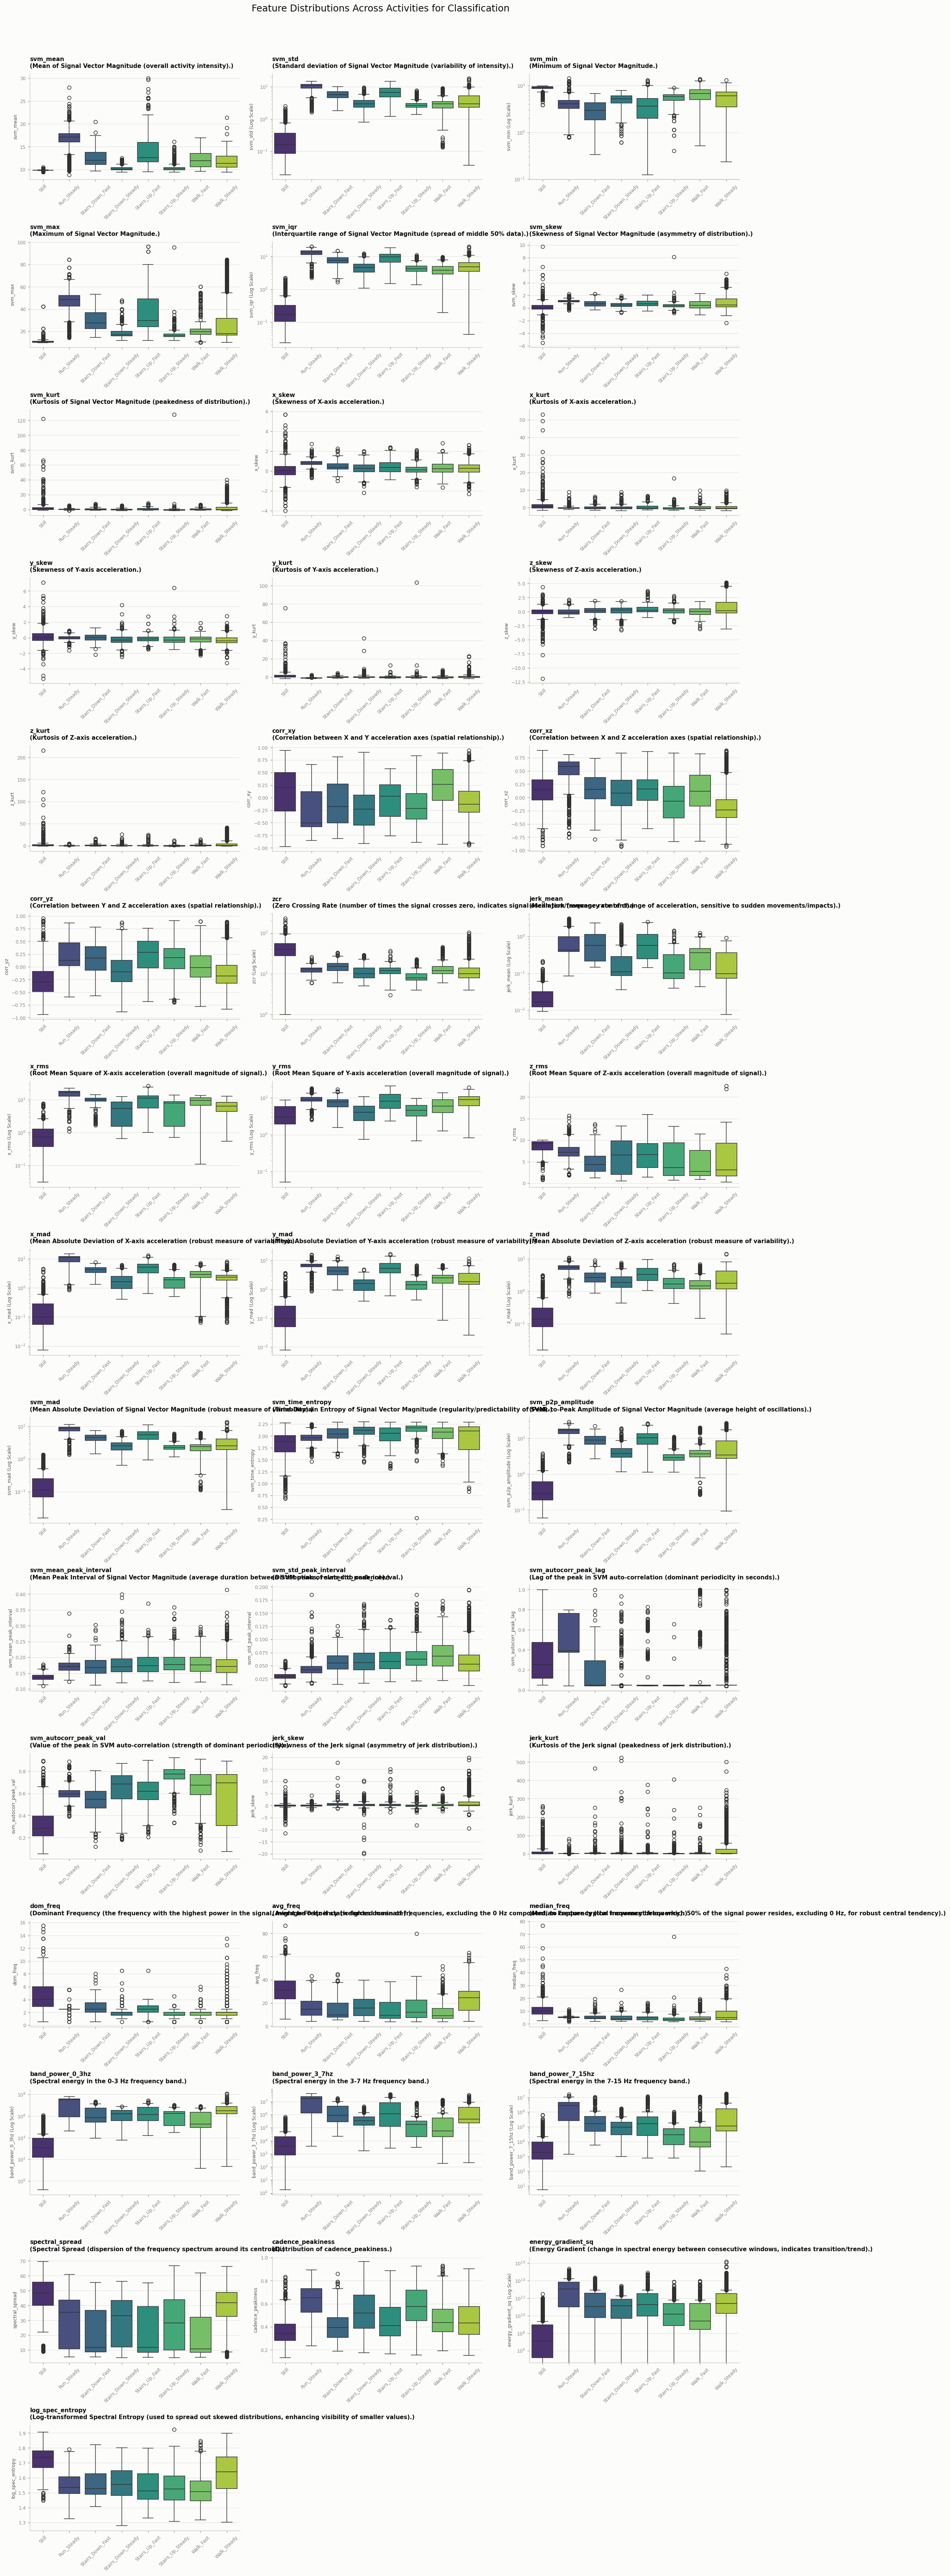

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Define feature explanations
feature_explanations = {
    'svm_mean': 'Mean of Signal Vector Magnitude (overall activity intensity).',
    'svm_std': 'Standard deviation of Signal Vector Magnitude (variability of intensity).',
    'svm_min': 'Minimum of Signal Vector Magnitude.',
    'svm_max': 'Maximum of Signal Vector Magnitude.',
    'svm_iqr': 'Interquartile range of Signal Vector Magnitude (spread of middle 50% data).',
    'svm_skew': 'Skewness of Signal Vector Magnitude (asymmetry of distribution).',
    'svm_kurt': 'Kurtosis of Signal Vector Magnitude (peakedness of distribution).',
    'x_skew': 'Skewness of X-axis acceleration.',
    'x_kurt': 'Kurtosis of X-axis acceleration.',
    'y_skew': 'Skewness of Y-axis acceleration.',
    'y_kurt': 'Kurtosis of Y-axis acceleration.',
    'z_skew': 'Skewness of Z-axis acceleration.',
    'z_kurt': 'Kurtosis of Z-axis acceleration.',
    'corr_xy': 'Correlation between X and Y acceleration axes (spatial relationship).',
    'corr_xz': 'Correlation between X and Z acceleration axes (spatial relationship).',
    'corr_yz': 'Correlation between Y and Z acceleration axes (spatial relationship).',
    'zcr': 'Zero Crossing Rate (number of times the signal crosses zero, indicates signal oscillation/frequency content).',
    'jerk_mean': 'Mean Jerk (average rate of change of acceleration, sensitive to sudden movements/impacts).',
    'dom_freq': 'Dominant Frequency (the frequency with the highest power in the signal, might be 0 Hz if static forces dominate).',
    'avg_freq': 'Average Frequency (weighted mean of frequencies, excluding the 0 Hz component, to capture typical movement frequency).',
    'median_freq': 'Median Frequency (the frequency below which 50% of the signal power resides, excluding 0 Hz, for robust central tendency).',
    'spec_energy': 'Spectral Energy (total energy in the frequency spectrum, indicates signal power/magnitude).',
    'spec_entropy': 'Spectral Entropy (measure of predictability/randomness in the frequency spectrum, lower for rhythmic, higher for random).',
    'energy_gradient_sq': 'Energy Gradient (change in spectral energy between consecutive windows, indicates transition/trend).',
    'log_spec_entropy': 'Log-transformed Spectral Entropy (used to spread out skewed distributions, enhancing visibility of smaller values).',
    'scaled_entropy_sq': 'Amplified Squared Spectral Entropy (power transformation of spectral entropy to enhance separability between activities).',
    'x_rms': 'Root Mean Square of X-axis acceleration (overall magnitude of signal).',
    'y_rms': 'Root Mean Square of Y-axis acceleration (overall magnitude of signal).',
    'z_rms': 'Root Mean Square of Z-axis acceleration (overall magnitude of signal).',
    'svm_rms': 'Root Mean Square of Signal Vector Magnitude (overall magnitude of signal).',
    'x_mad': 'Mean Absolute Deviation of X-axis acceleration (robust measure of variability).',
    'y_mad': 'Mean Absolute Deviation of Y-axis acceleration (robust measure of variability).',
    'z_mad': 'Mean Absolute Deviation of Z-axis acceleration (robust measure of variability).',
    'svm_mad': 'Mean Absolute Deviation of Signal Vector Magnitude (robust measure of variability).',
    'sma': 'Signal Magnitude Area (total dynamic motion over a period).',
    'svm_time_entropy': 'Time-Domain Entropy of Signal Vector Magnitude (regularity/predictability of SVM).',
    'svm_p2p_amplitude': 'Peak-to-Peak Amplitude of Signal Vector Magnitude (average height of oscillations).',
    'svm_mean_peak_interval': 'Mean Peak Interval of Signal Vector Magnitude (average duration between SVM peaks, related to cadence).',
    'svm_autocorr_peak_lag': 'Lag of the peak in SVM auto-correlation (dominant periodicity in seconds).',
    'svm_autocorr_peak_val': 'Value of the peak in SVM auto-correlation (strength of dominant periodicity).',
    'jerk_skew': 'Skewness of the Jerk signal (asymmetry of jerk distribution).',
    'jerk_kurt': 'Kurtosis of the Jerk signal (peakedness of jerk distribution).',
    'spectral_centroid': 'Spectral Centroid (center of mass of the frequency spectrum).',
    'band_power_0_3hz': 'Spectral energy in the 0-3 Hz frequency band.',
    'band_power_3_7hz': 'Spectral energy in the 3-7 Hz frequency band.',
    'band_power_7_15hz': 'Spectral energy in the 7-15 Hz frequency band.',
    'spectral_spread': 'Spectral Spread (dispersion of the frequency spectrum around its centroid).'
}

# The `process_df` DataFrame is available from previous execution.
# Get the list of features to plot.
# Exclude 'y_label', 'source_file', and the redundant 'spec_entropy_sq' (which has identical values to 'scaled_entropy_sq' in process_df)
features_to_plot_raw = [col for col in process_df.columns if col not in ['y_label', 'source_file']]
if 'spec_entropy_sq' in features_to_plot_raw:
    features_to_plot_raw.remove('spec_entropy_sq') # Removing redundant feature to avoid duplicate plots

features_to_plot = features_to_plot_raw

# Create a figure to hold multiple box plots
num_features = len(features_to_plot)
n_cols = 3  # Number of columns for subplots
n_rows = (num_features + n_cols - 1) // n_cols # Calculate rows needed

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 6, n_rows * 4), constrained_layout=True)
axes = axes.flatten() # Flatten the array of axes for easy iteration

# Iterate through features and create a box plot for each
for i, feature in enumerate(features_to_plot):
    ax = axes[i]
    explanation = feature_explanations.get(feature, f'Distribution of {feature}.')

    sns.boxplot(ax=ax, x='y_label', y=feature, data=process_df, palette='viridis', hue='y_label', legend=False)

    ax.set_title(f'{feature}\n({explanation})', fontsize=10)
    ax.set_xlabel('') # Remove x-label to avoid clutter on subplots
    ax.set_ylabel(feature, fontsize=8)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)

    # Heuristic to apply log scale for features with very wide ranges and positive values
    # Add a small epsilon to avoid log(0) if min is 0 or replace 0 with NaN for min calculation
    min_val_for_log_check = process_df[feature].replace(0, np.nan).min()
    if min_val_for_log_check is not np.nan and min_val_for_log_check >= 0 and (process_df[feature].max() / (min_val_for_log_check + 1e-9) > 100 or process_df[feature].max() > 1000):
        ax.set_yscale('log')
        ax.set_ylabel(f'{feature} (Log Scale)', fontsize=8)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Feature Distributions Across Activities for Classification', y=1.02, fontsize=16) # Main title for the entire figure
plt.show()

#### Conclusions from Feature Distribution Analysis

1. **Intensity Separation**: `svm_mean` and `x_mad` are the most important features in our models. High-intensity **Runs** are clearly separated from **Still** and **Slow Walks**.
2. **Rhythmicity**: Spectral entropy variants help distinguish stationary noise from rhythmic gaits.
3. **Frequency-Domain**: `avg_freq` and `median_freq` confirm that **Runs** (~2.7 Hz) are faster than **Walks** (~1.8 Hz).
4. **Orientation Invariance**: High variance in individual axis correlations (`corr_xy`, etc.) confirms phone orientation was not fixed, making **SVM-based features** essential for generalization.
5. **Trend Engineering**: We calculated the squared energy gradient to capture transitions between activity states.

### PCA to see data seperation

#### Dimensionality Reduction (PCA) and Visualization
We will scale the features and apply PCA to reduce the dataset to 2 dimensions to see if the movements are linearly separable.

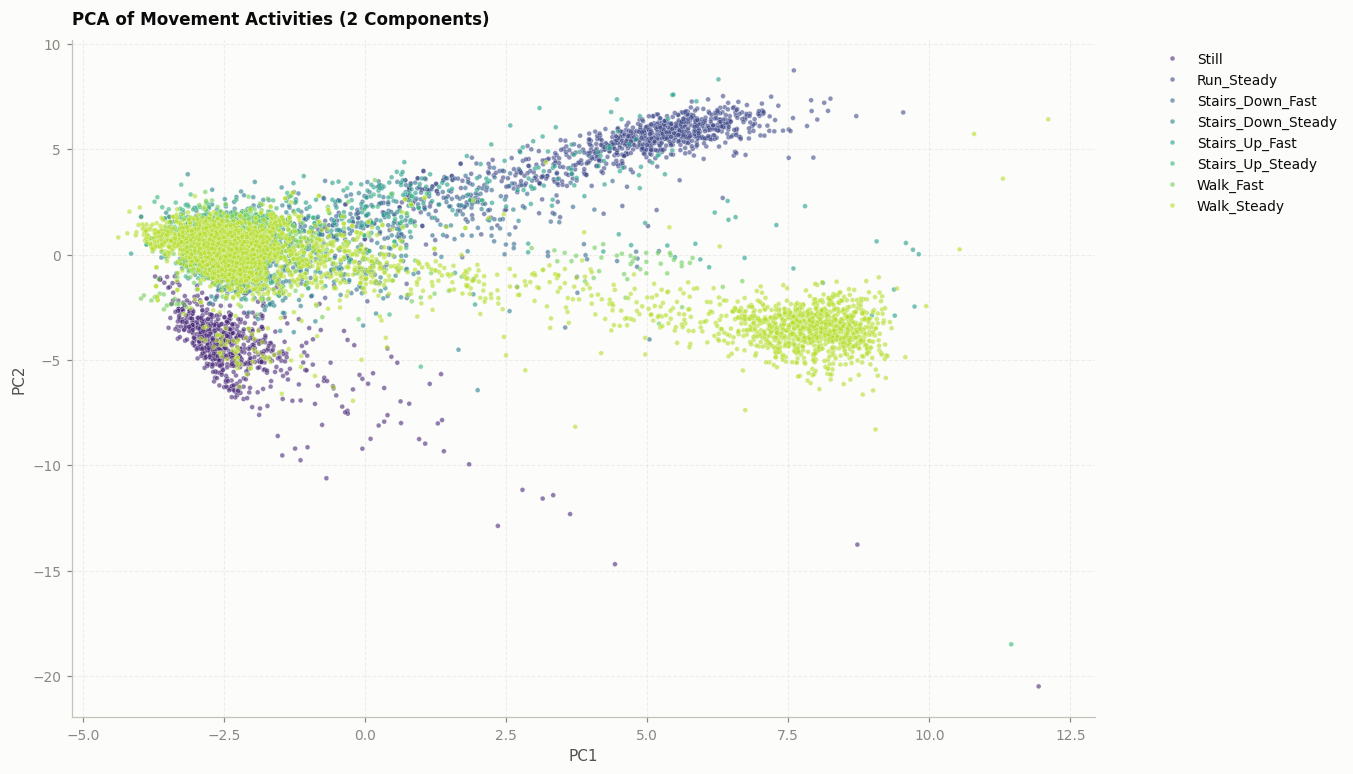

Explained variance ratio: [0.33946158 0.18220358]
Total variance captured: 52.17%


In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare data (exclude non-feature columns)
features_list = [col for col in final_dataset.columns if col not in ['y_label', 'source_file']]
X = final_dataset[features_list]
y = final_dataset['y_label']

# 2. Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Apply PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(X_scaled)

# 4. Create a plot DataFrame
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
pca_df['Activity'] = y.values

# 5. Visualize
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC1', y='PC2',
    hue='Activity',
    palette='viridis',
    data=pca_df,
    alpha=0.6,
    s=10
)
plt.title('PCA of Movement Activities (2 Components)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

# Print variance explained
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance captured: {sum(pca.explained_variance_ratio_):.2%}")

#### 3D PCA Visualization
Using 3 components instead of 2 to capture more variance and visualize the data in an interactive 3D space.

In [ ]:
import plotly.express as px

# 1. Re-run PCA with 3 components
pca_3d = PCA(n_components=3)
pca_result_3d = pca_3d.fit_transform(X_scaled)

# 2. Create DataFrame for Plotly
pca_df_3d = pd.DataFrame(data=pca_result_3d, columns=['PC1', 'PC2', 'PC3'])
pca_df_3d['Activity'] = y.values

# 3. Create interactive 3D scatter plot
# Note: We sample the data if it's too large for smooth rendering,
# but with ~214k rows, Plotly can handle a significant portion.
fig = px.scatter_3d(
    pca_df_3d.sample(min(20000, len(pca_df_3d))), # Sampling for better performance
    x='PC1', y='PC2', z='PC3',
    color='Activity',
    title='3D PCA of Movement Activities',
    opacity=0.6,
    size_max=2
)

fig.update_traces(marker=dict(size=2))
fig.show()

print(f"Explained variance ratio (3 components): {pca_3d.explained_variance_ratio_}")
print(f"Total variance captured: {sum(pca_3d.explained_variance_ratio_):.2%}")

Explained variance ratio (3 components): [0.33946158 0.18220358 0.0768031 ]
Total variance captured: 59.85%


#### PCA Conclusions

* **Variance Captured**: The first three principal components capture approximately **59.85%** of the total variance (PC1 at 33.9% and PC2 at 18.2%).
* **Class Separability**:
    * **Still** and **Runs** show relatively clear separation from the other clusters, confirming that intensity-based features are strong discriminators.
    * **Walks** and **Stairs** exhibit significant overlap in the PCA projections, validating the EDA finding that these activities share similar cadence profiles (~1.8 Hz).
* **Feature Utility**: The overlap suggests that linear separation is difficult for walking vs. stairs; therefore, non-linear models like Random Forest and XGBoost are necessary to utilize spectral shape and harmonic features effectively.

## **ML Model**

### Randon Forest


--- Initial Model Evaluation (Single Split) ---
Classification Report:
                    precision    recall  f1-score   support

        Run_Steady       0.96      0.92      0.94       191
  Stairs_Down_Fast       0.64      0.85      0.73        55
Stairs_Down_Steady       0.52      0.83      0.64       129
    Stairs_Up_Fast       0.79      0.65      0.72        52
  Stairs_Up_Steady       0.52      0.82      0.64       145
             Still       0.99      0.99      0.99       149
         Walk_Fast       0.68      0.88      0.77       108
       Walk_Steady       0.99      0.78      0.87       895

          accuracy                           0.83      1724
         macro avg       0.76      0.84      0.79      1724
      weighted avg       0.88      0.83      0.84      1724



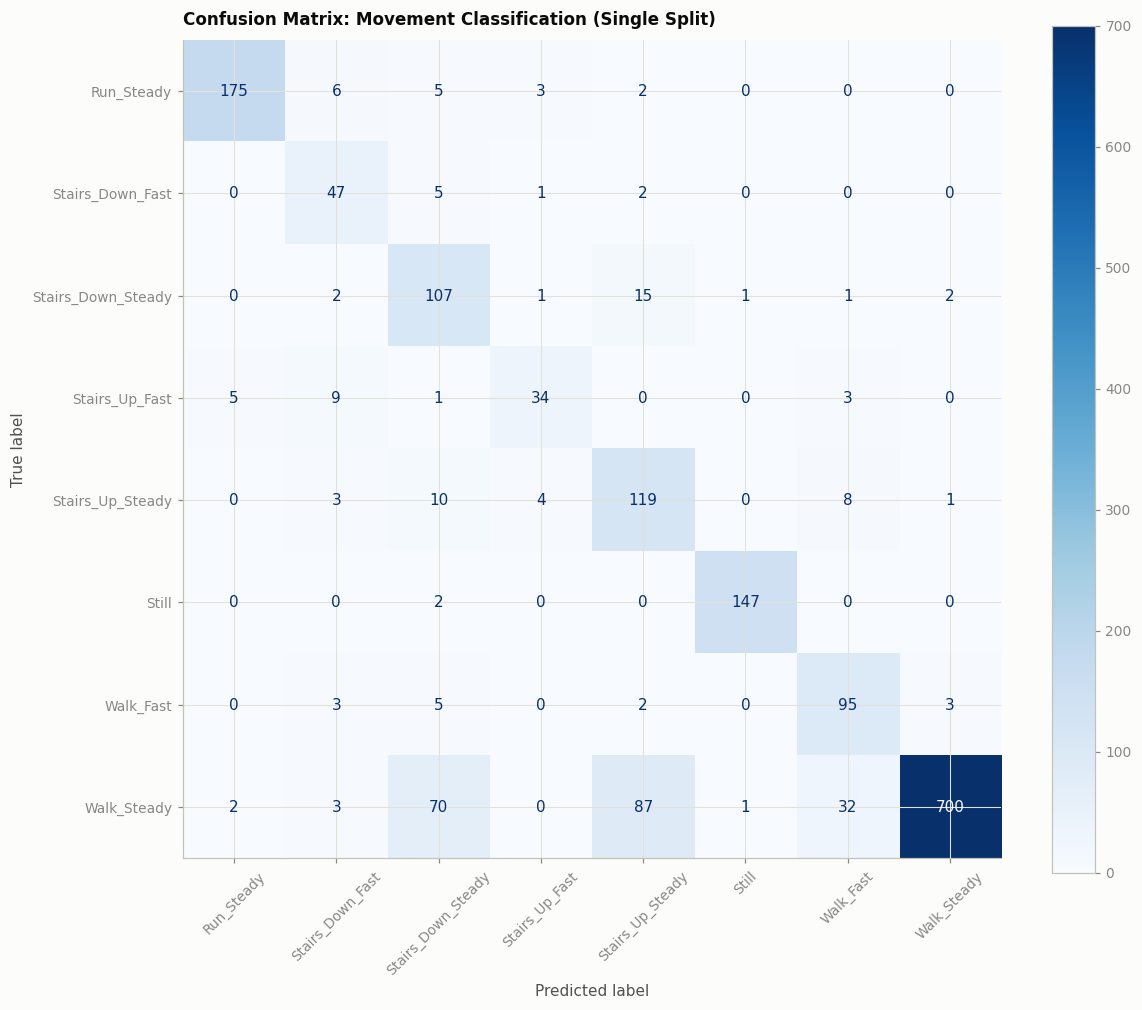

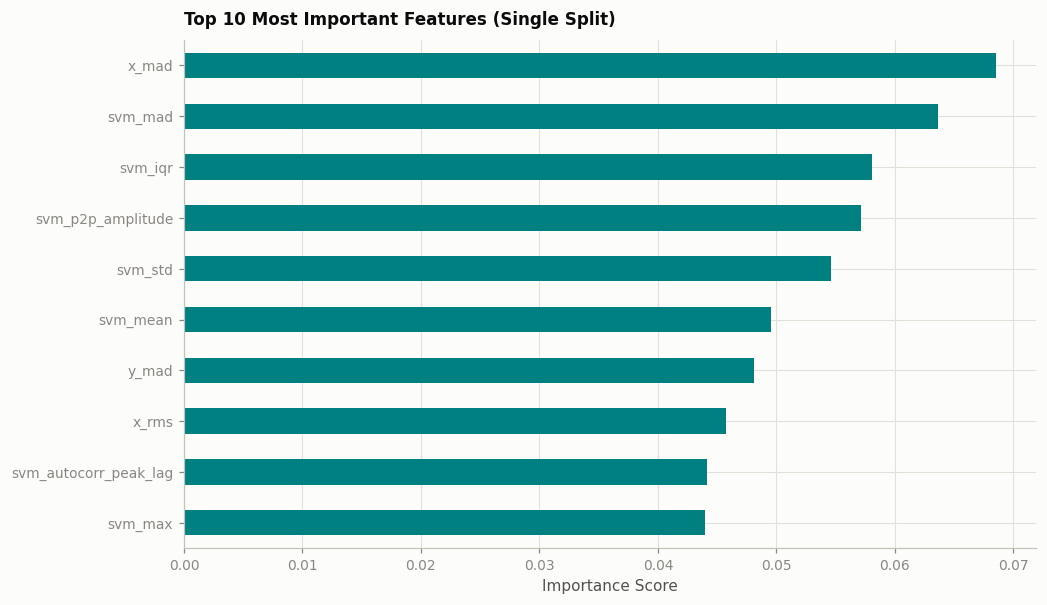


--- Cross-Validation Results ---
Average Training Accuracy: 0.8598
Average Test Accuracy: 0.8198
Average Training Precision (Macro): 0.8199
Average Test Precision (Macro): 0.7553
Average Training Recall (Macro): 0.9152
Average Test Recall (Macro): 0.8351
Average Training F1-Score (Macro): 0.8544
Average Test F1-Score (Macro): 0.7802


In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# 1. Define features and target
features_to_use = [col for col in process_df.columns if col not in ['y_label', 'source_file']]
X = process_df[features_to_use]
y = process_df['y_label']

# 2. Split data (80% train, 20% test) for initial evaluation and confusion matrix
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Initialize and Train Random Forest for initial evaluation
# To avoid overfitting, consider tuning these parameters:
# - max_depth: Limits the depth of each tree (e.g., 5-10) to prevent memorization.
# - min_samples_leaf: Minimum samples required to be at a leaf node (e.g., 3, 5) to make leaves more general.
# - min_samples_split: Minimum samples required to split an internal node (e.g., 5, 10).
# - max_features: Number of features to consider for the best split (e.g., 'sqrt', 'log2') to promote diversity.
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced', # Walk_Steady outnumbers Stairs_Up_Fast ~15x; balance so the model
                              # stops defaulting to the majority class on ambiguous windows
    max_depth=9, # Tuned parameter to reduce overfitting
    min_samples_leaf=3, # Tuned parameter to reduce overfitting
    min_samples_split=4, # Tuned parameter to reduce overfitting
    max_features='sqrt', # Tuned parameter to reduce overfitting
    n_jobs=-1,
    random_state=42
)
rf_model.fit(X_train, y_train)

# 4. Predictions and Evaluation (initial split)
print("\n--- Initial Model Evaluation (Single Split) ---")
y_pred = rf_model.predict(X_test)
print("Classification Report:")
print(classification_report(y_test, y_pred))

# 5. Plot Confusion Matrix (initial split)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_estimator(rf_model, X_test, y_test, ax=ax, cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix: Movement Classification (Single Split)')
plt.show()

# 6. Feature Importance (initial split)
importances = pd.Series(rf_model.feature_importances_, index=features_to_use).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
importances.head(10).plot(kind='barh', color='teal')
plt.title('Top 10 Most Important Features (Single Split)')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.show()

# 7. Cross-validation
print("\n--- Cross-Validation Results ---")

# Define the cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize a new Random Forest Classifier for cross-validation with same tuned parameters
rf_model_cv = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    max_depth=9, # Tuned parameter to reduce overfitting
    min_samples_leaf=3, # Tuned parameter to reduce overfitting
    min_samples_split=4, # Tuned parameter to reduce overfitting
    max_features='sqrt', # Tuned parameter to reduce overfitting
    n_jobs=-1,
    random_state=42
)

# Perform cross-validation
cv_results = cross_validate(rf_model_cv, X, y, cv=cv, scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'], return_train_score=True)

# Print average cross-validation results
print(f"Average Training Accuracy: {np.mean(cv_results['train_accuracy']):.4f}")
print(f"Average Test Accuracy: {np.mean(cv_results['test_accuracy']):.4f}")
print(f"Average Training Precision (Macro): {np.mean(cv_results['train_precision_macro']):.4f}")
print(f"Average Test Precision (Macro): {np.mean(cv_results['test_precision_macro']):.4f}")
print(f"Average Training Recall (Macro): {np.mean(cv_results['train_recall_macro']):.4f}")
print(f"Average Test Recall (Macro): {np.mean(cv_results['test_recall_macro']):.4f}")
print(f"Average Training F1-Score (Macro): {np.mean(cv_results['train_f1_macro']):.4f}")
print(f"Average Test F1-Score (Macro): {np.mean(cv_results['test_f1_macro']):.4f}")

#### OptTuna Optimization for Huperparamters




In [ ]:
# !pip install optuna

import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, train_test_split
import numpy as np # Import numpy for mean and abs

# 1. Prepare data (Ensure X and y are available from process_df)
features_to_use = [col for col in process_df.columns if col not in ['y_label', 'source_file', 'spec_entropy']]
X = process_df[features_to_use]
y = process_df['y_label']

# 2. Split data to define X_train and y_train for the objective function
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

def objective(trial):
    # 3. Define the search space for hyperparameters
    max_depth = trial.suggest_int('max_depth', 5, 13)  # was capped at 10; train/test gap was
                                                        # only ~3pts, so there was headroom
    min_samples_split = trial.suggest_int('min_samples_split', 2, 20)
    min_samples_leaf = trial.suggest_int('min_samples_leaf', 1, 20)

    # 4. Initialize the model with suggested parameters
    clf = RandomForestClassifier(
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        n_estimators=100,
        class_weight='balanced',
        n_jobs=-1,
        random_state=42
    )

    # 5. Calculate cross-validation scores using cross_validate to get both train and test scores
    cv_results = cross_validate(clf, X_train, y_train, cv=5,
                                scoring='f1_macro', return_train_score=True, n_jobs=-1)

    test_score = np.mean(cv_results['test_score'])
    train_score = np.mean(cv_results['train_score'])

    # Calculate the generalization gap (absolute difference between train and test scores)
    generalization_gap = abs(train_score - test_score)

    # Penalty factor for the generalization gap. This can be tuned if needed.
    # A higher factor penalizes larger gaps more. Use 0.5 as a starting point.
    penalty_factor = 0.6

    # The objective is to maximize test F1-macro while penalizing a large generalization gap.
    penalized_score = test_score - penalty_factor * generalization_gap

    return penalized_score

# 6. Create and run the Optuna study
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

# 7. Output results
print(f"Best F1-Macro (penalized for generalization gap): {study.best_value:.4f}")
print(f"Best parameters: {study.best_params}")

[I 2026-08-26 12:46:44,928] A new study created in memory with name: no-name-79106385-4074-40e1-a7d6-190172615386
[I 2026-08-26 12:47:14,675] Trial 0 finished with value: 0.7364512193958264 and parameters: {'max_depth': 13, 'min_samples_split': 4, 'min_samples_leaf': 9}. Best is trial 0 with value: 0.7364512193958264.
[I 2026-08-26 12:47:27,265] Trial 1 finished with value: 0.6273224659462685 and parameters: {'max_depth': 6, 'min_samples_split': 4, 'min_samples_leaf': 20}. Best is trial 0 with value: 0.7364512193958264.
[I 2026-08-26 12:47:47,852] Trial 2 finished with value: 0.7614758619146808 and parameters: {'max_depth': 12, 'min_samples_split': 6, 'min_samples_leaf': 2}. Best is trial 2 with value: 0.7614758619146808.
[I 2026-08-26 12:48:04,665] Trial 3 finished with value: 0.6966186020194336 and parameters: {'max_depth': 10, 'min_samples_split': 8, 'min_samples_leaf': 19}. Best is trial 2 with value: 0.7614758619146808.
[I 2026-08-26 12:48:26,706] Trial 4 finished with value: 0.76

Best F1-Macro (penalized for generalization gap): 0.7699
Best parameters: {'max_depth': 13, 'min_samples_split': 10, 'min_samples_leaf': 2}


In [ ]:
from sklearn.metrics import f1_score

# 1. גזירת הפרמטרים הכי טובים שמצאנו
best_params = study.best_params

# 2. יצירת המודל הסופי עם הפרמטרים האלו
final_clf_rdc = RandomForestClassifier(
    **best_params,
    n_estimators=100,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)

# 3. אימון המודל על כל נתוני האימון
final_clf_rdc.fit(X_train, y_train)

# 4. חישוב ה-F1 Macro על ה-Train ועל ה-Test
y_train_pred = final_clf_rdc.predict(X_train)
y_test_pred = final_clf_rdc.predict(X_test)

train_f1_macro = f1_score(y_train, y_train_pred, average='macro')
test_f1_macro = f1_score(y_test, y_test_pred, average='macro')

print(f"📊 Train F1-Macro: {train_f1_macro:.4f}")
print(f"🎯 Test F1-Macro:  {test_f1_macro:.4f}")

📊 Train F1-Macro: 0.9509
🎯 Test F1-Macro:  0.8620


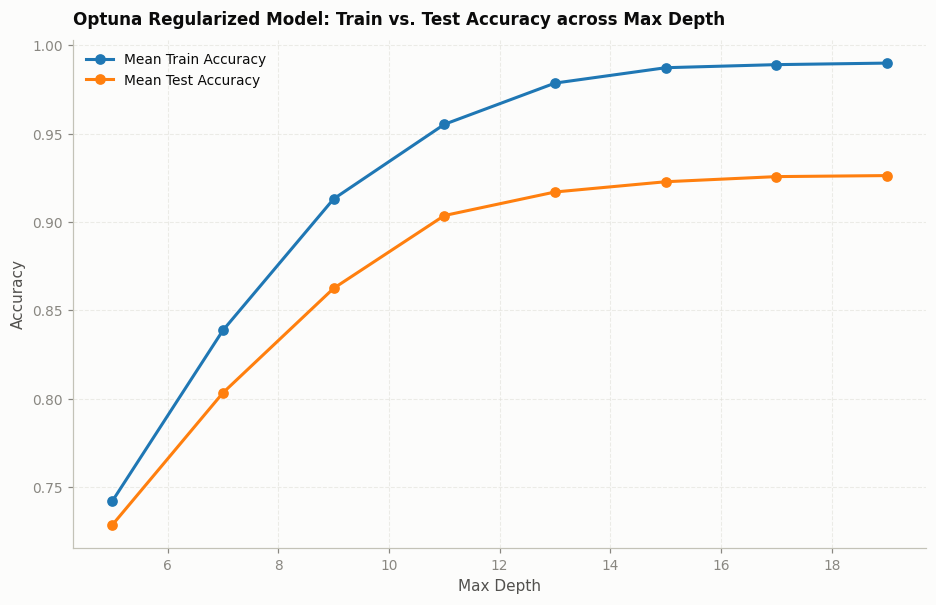

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.ensemble import RandomForestClassifier

# 1. שליפת הפרמטרים המנצחים מאופטונה
best_min_split = study.best_params['min_samples_split']
best_min_leaf = study.best_params['min_samples_leaf']

# 2. הגדרת טווח העומק שנבדוק (כמו בגרף המקורי שלך)
max_depths = np.arange(5, 21, 2)
train_scores = []
test_scores = []

# 3. אימון ובדיקה עבור כל עומק
for depth in max_depths:
    clf = RandomForestClassifier(
        max_depth=depth,
        min_samples_split=best_min_split,
        min_samples_leaf=best_min_leaf,
        n_estimators=100,
        n_jobs=-1,
        random_state=42
    )

    # אימון
    clf.fit(X_train, y_train)

    # שמירת תוצאות
    train_scores.append(clf.score(X_train, y_train))
    test_scores.append(clf.score(X_test, y_test))

# 4. יצירת הגרף "אחד ליד השני"
plt.figure(figsize=(10, 6))
plt.plot(max_depths, train_scores, marker='o', label='Mean Train Accuracy', color='#1f77b4')
plt.plot(max_depths, test_scores, marker='o', label='Mean Test Accuracy', color='#ff7f0e')

plt.title('Optuna Regularized Model: Train vs. Test Accuracy across Max Depth')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()



--- Final Model Evaluation (Optuna Optimized) ---
Classification Train Report:
                    precision    recall  f1-score   support

        Run_Steady       1.00      0.97      0.98       765
  Stairs_Down_Fast       0.95      1.00      0.97       222
Stairs_Down_Steady       0.82      0.98      0.89       517
    Stairs_Up_Fast       0.93      0.99      0.96       209
  Stairs_Up_Steady       0.79      0.96      0.86       580
             Still       1.00      1.00      1.00       595
         Walk_Fast       0.96      0.99      0.97       430
       Walk_Steady       1.00      0.93      0.96      3577

          accuracy                           0.95      6895
         macro avg       0.93      0.98      0.95      6895
      weighted avg       0.96      0.95      0.96      6895


--- Final Model Evaluation (Optuna Optimized) ---
Classification Report:
                    precision    recall  f1-score   support

        Run_Steady       0.96      0.97      0.96       191
  

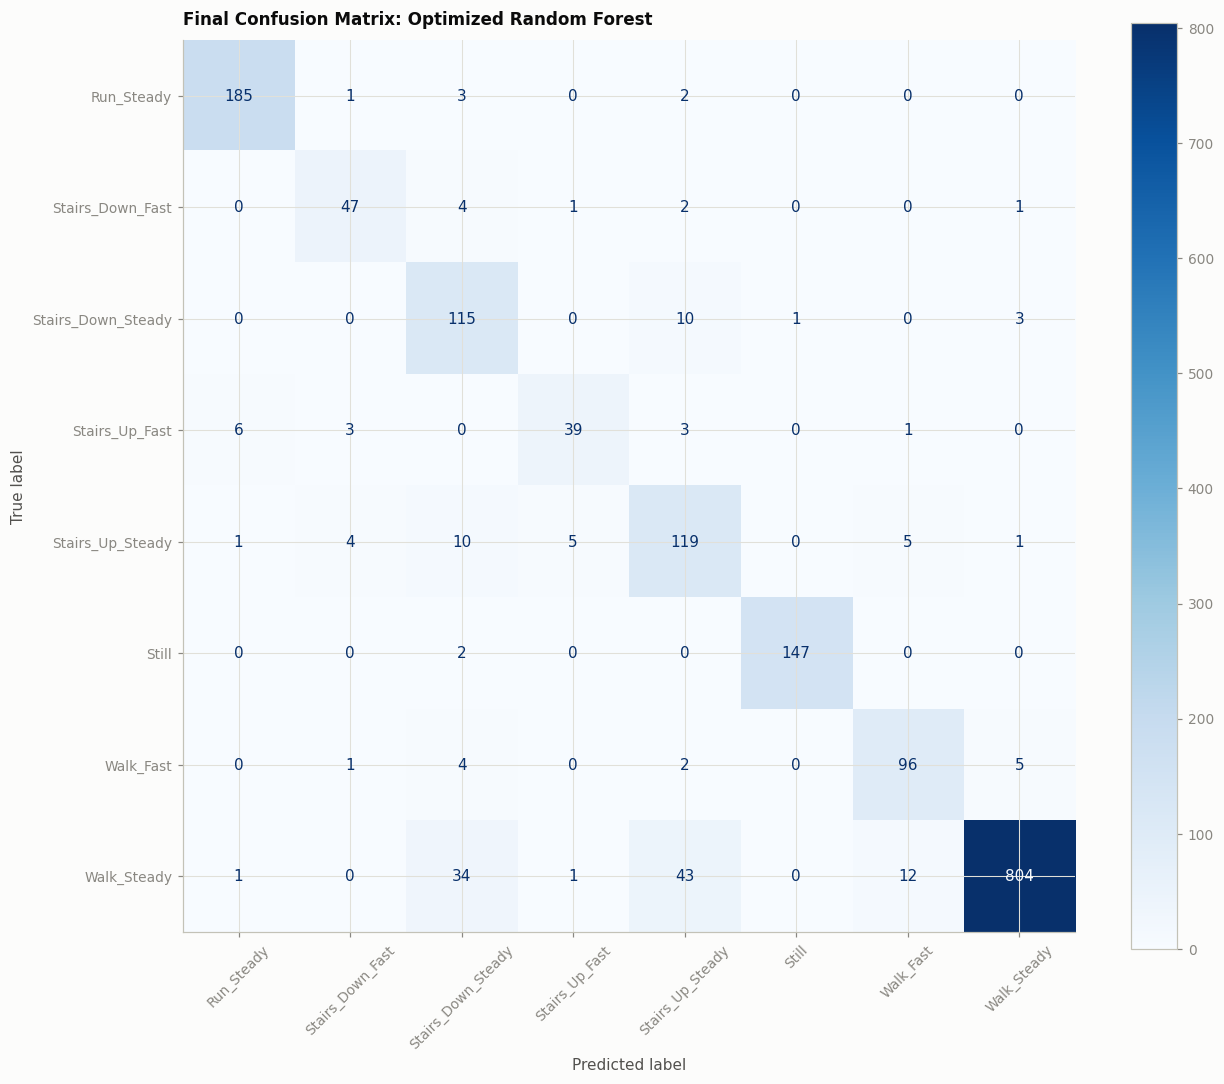

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Predict on the test set using the final model
y_pred_final = final_clf_rdc.predict(X_test)
y_pred_train_final = final_clf_rdc.predict(X_train)
# 2. Print Classification Report
print("\n--- Final Model Evaluation (Optuna Optimized) ---")
print("Classification Train Report:")
print(classification_report(y_train, y_pred_train_final))
# 2. Print Classification Report
print("\n--- Final Model Evaluation (Optuna Optimized) ---")
print("Classification Report:")
print(classification_report(y_test, y_pred_final))

# 3. Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_estimator(
    final_clf_rdc,
    X_test,
    y_test,
    ax=ax,
    cmap='Blues',
    xticks_rotation=45
)
plt.title('Final Confusion Matrix: Optimized Random Forest')
plt.tight_layout()
plt.show()

#### Unknow Activity Recognize

##### Strategy for 'Unknown' Classification

Instead of forcing the Random Forest to pick one of your training labels, you can use the confidence scores.

1. **Get Probabilities**: Use `rf_model.predict_proba(X_test)` to get an array where each row represents the probability (from 0 to 1) for every possible activity.
2. **Find the Maximum**: For each row, identify the highest probability score.
3. **Apply a Threshold**: If that maximum score is less than, say, 0.60 (60%), you label that window as `'Unknown'`. Otherwise, you keep the predicted label.


In [ ]:
import numpy as np

# 1. Get the probabilities for each class using the test set (X_test)
# Hint: Use the method that sounds like 'predict probability'
probs = final_clf_rdc.predict_proba(X_test)

# 2. Find the maximum probability for each individual prediction
max_probs = np.max(probs, axis=1)

# 3. Define your threshold
threshold = 0.25

# 4. Count how many fall below the threshold
unknown_count = np.sum(max_probs < threshold)
total_count = len(max_probs)

print(f"Windows below {threshold*100}% confidence: {unknown_count} out of {total_count}")
print(f"Percentage of 'Unknown' data: {(unknown_count/total_count)*100:.2f}%")

Windows below 25.0% confidence: 5 out of 1724
Percentage of 'Unknown' data: 0.29%


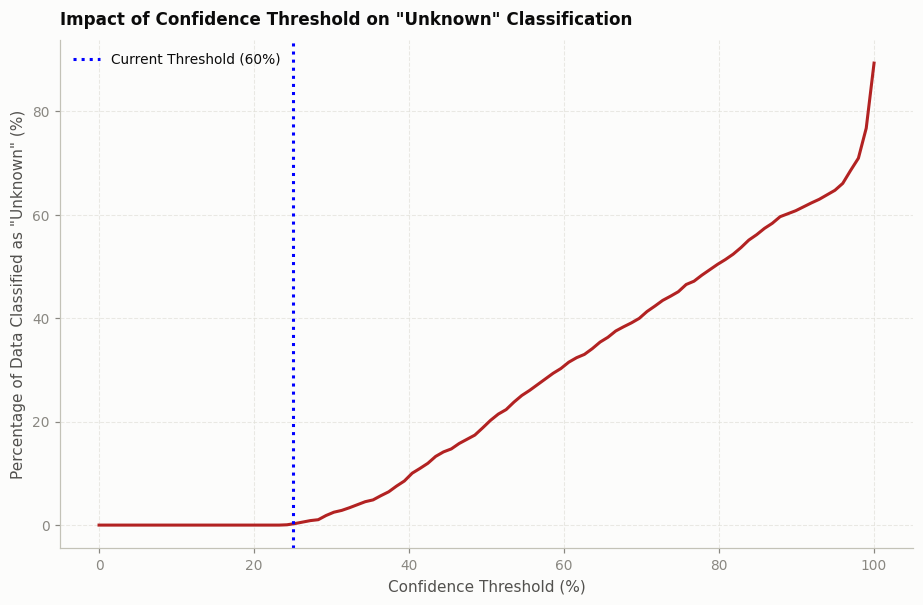

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Create a range of thresholds from 0.0 to 1.0
thresholds = np.linspace(0, 1, 100)

# 2. Calculate the percentage of 'Unknown' for each threshold
# Hint: You can use a list comprehension or a loop to repeat the logic from the previous cell
unknown_percentages = [
    (np.sum(max_probs < t) / len(max_probs)) * 100
    for t in thresholds
]

# 3. Plot the results
plt.figure(figsize=(10, 6))
plt.plot(thresholds * 100, unknown_percentages, color='firebrick', linewidth=2)
plt.title('Impact of Confidence Threshold on "Unknown" Classification')
plt.xlabel('Confidence Threshold (%)')
plt.ylabel('Percentage of Data Classified as "Unknown" (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.axvline(x=25, color='blue', linestyle=':', label='Current Threshold (60%)')
plt.legend()
plt.show()

#### Save model to disk

In [ ]:
import joblib
from pathlib import Path

# 1. Define the save path in Google Drive
# Using the previously defined ROOT variable for consistency
MODEL_SAVE_PATH = Path('/content/drive/MyDrive/FINALE_RF') / "final_optimized_rf_model.joblib"

# 2. Save the model
try:
    joblib.dump(final_clf_rdc, MODEL_SAVE_PATH)
    print(f"✅ Model successfully saved to: {MODEL_SAVE_PATH}")
except Exception as e:
    print(f"❌ Error saving the model: {e}")

# 3. Instruction to reload the model later:
# loaded_model = joblib.load(MODEL_SAVE_PATH)

✅ Model successfully saved to: /content/drive/MyDrive/FINALE_RF/final_optimized_rf_model.joblib


### XGBoost


--- Training XGBoost Model ---


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning:

[11:01:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.





--- Initial XGBoost Model Evaluation (Single Split) ---
Classification Report:
                    precision    recall  f1-score   support

        Run_Steady       0.99      0.99      0.99       177
  Stairs_Down_Fast       0.90      0.81      0.85        53
Stairs_Down_Steady       0.86      0.86      0.86       124
    Stairs_Up_Fast       0.93      0.86      0.90        50
  Stairs_Up_Steady       0.93      0.83      0.88       136
             Still       0.99      0.99      0.99       141
         Walk_Fast       0.93      0.90      0.92        91
       Walk_Steady       0.96      0.99      0.98       763

          accuracy                           0.95      1535
         macro avg       0.94      0.91      0.92      1535
      weighted avg       0.95      0.95      0.95      1535



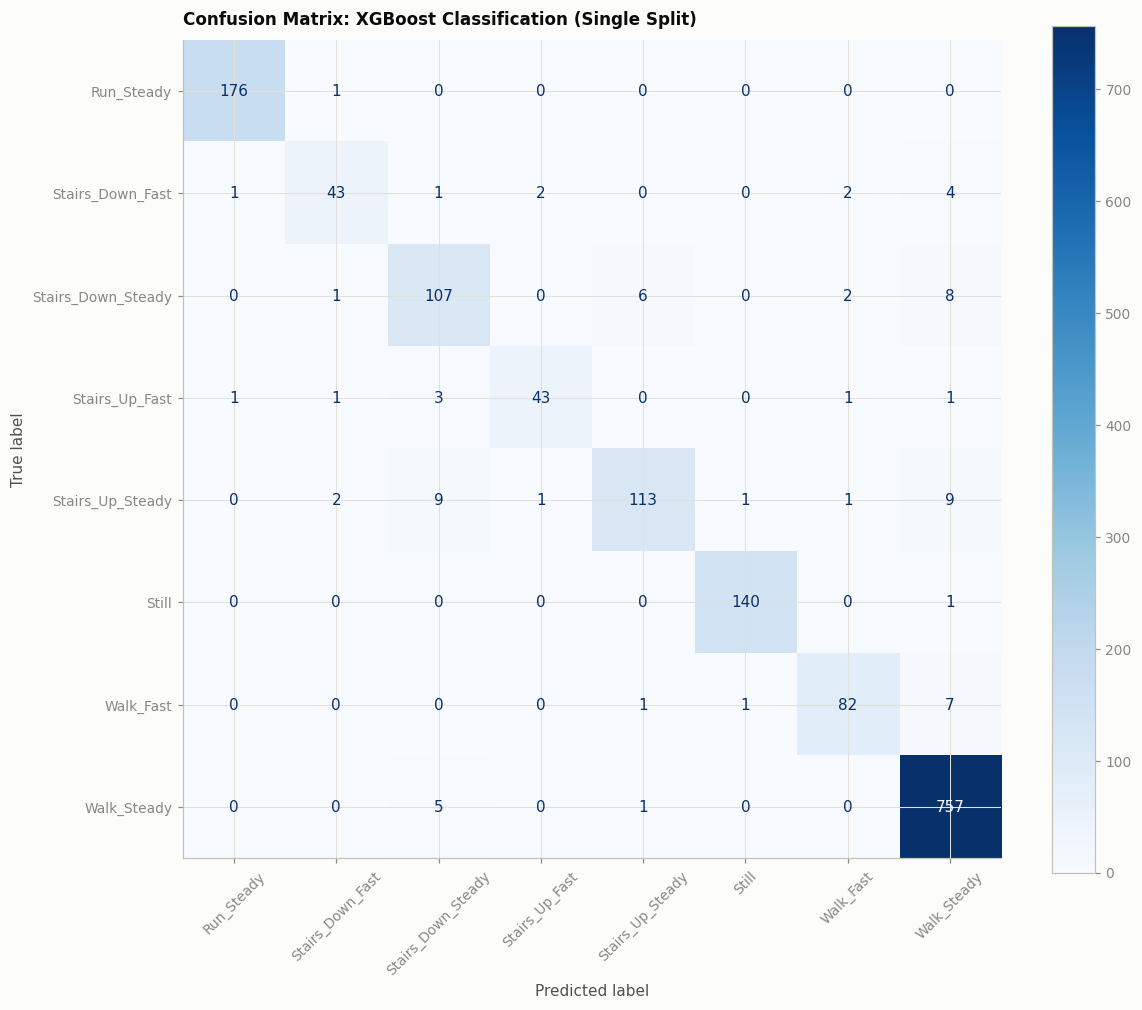

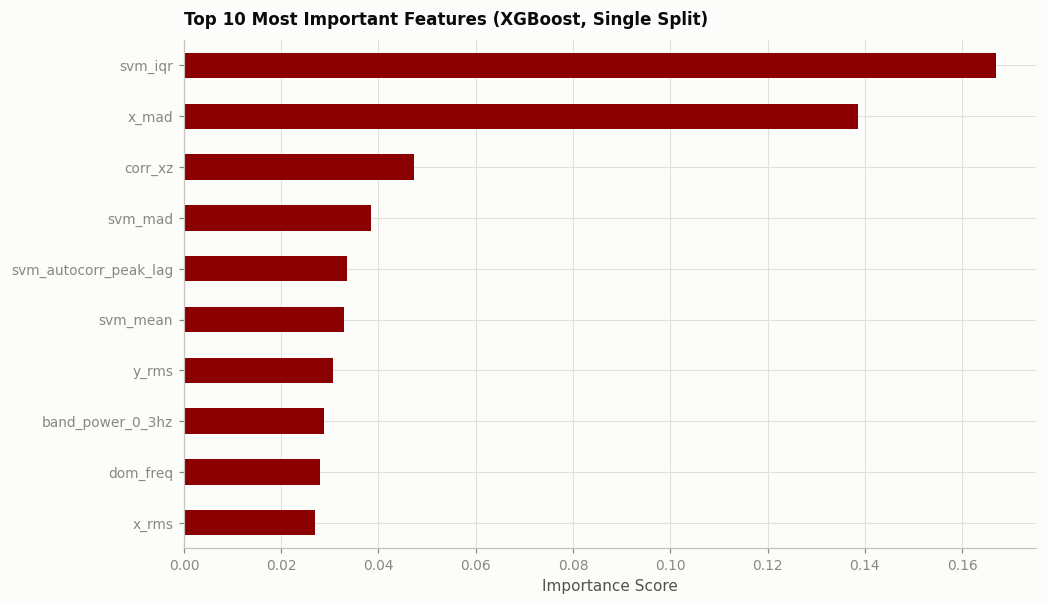


--- XGBoost Cross-Validation Results ---


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning:

[11:01:17] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning:

[11:01:22] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning:

[11:01:30] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning:

[11:01:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning:

[11:01:43] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.




Average Training Accuracy (XGBoost): 0.9986
Average Test Accuracy (XGBoost): 0.9446
Average Training Precision (Macro, XGBoost): 0.9989
Average Test Precision (Macro, XGBoost): 0.9221
Average Training Recall (Macro, XGBoost): 0.9983
Average Test Recall (Macro, XGBoost): 0.8969
Average Training F1-Score (Macro, XGBoost): 0.9986
Average Test F1-Score (Macro, XGBoost): 0.9085


In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder # Import LabelEncoder
import matplotlib.pyplot as plt
import numpy as np

# 1. Define features and target
# Ensure features_to_use is defined consistently, excluding 'y_label', 'source_file', and original 'spec_entropy'
features_to_use = [col for col in process_df.columns if col not in ['y_label', 'source_file', 'spec_entropy']]
X = process_df[features_to_use]
y = process_df['y_label']

# 2. Encode string labels to numerical labels for XGBoost
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# 3. Split data (80% train, 20% test) for initial evaluation
X_train, X_test, y_train_encoded, y_test_encoded = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Get original string labels for confusion matrix display
# This is derived from the original y (before splitting) and then matched
y_true_labels_test = label_encoder.inverse_transform(y_test_encoded)


# 4. Initialize and Train XGBoost Classifier
# Using some default parameters, but these can be tuned later via GridSearchCV
xgb_model = XGBClassifier(
    objective='multi:softmax', # For multi-class classification
    num_class=len(label_encoder.classes_), # Number of unique classes
    eval_metric='mlogloss',    # Evaluation metric for multi-class log loss
    use_label_encoder=False,   # Suppress warning
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42
)

print("\n--- Training XGBoost Model ---")
xgb_model.fit(X_train, y_train_encoded)

# 5. Predictions and Evaluation (initial split)
print("\n--- Initial XGBoost Model Evaluation (Single Split) ---")
y_pred_xgb_encoded = xgb_model.predict(X_test)
y_pred_xgb_labels = label_encoder.inverse_transform(y_pred_xgb_encoded)
print("Classification Report:")
print(classification_report(y_true_labels_test, y_pred_xgb_labels))

# 6. Plot Confusion Matrix (initial split)
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(y_true_labels_test, y_pred_xgb_labels, ax=ax, cmap='Blues', xticks_rotation=45)
plt.title('Confusion Matrix: XGBoost Classification (Single Split)')
plt.show()

# 7. Feature Importance (initial split)
# XGBoost's feature importances are often calculated based on 'weight', 'gain', or 'cover'
# Default is 'weight' (number of times a feature appears in trees)
importances_xgb = pd.Series(xgb_model.feature_importances_, index=features_to_use).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
importances_xgb.head(10).plot(kind='barh', color='darkred')
plt.title('Top 10 Most Important Features (XGBoost, Single Split)')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.show()

# 8. Cross-validation
print("\n--- XGBoost Cross-Validation Results ---")

# Define the cross-validation strategy
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize XGBoost Classifier for cross-validation with same parameters
# ensure use_label_encoder=False is set to avoid future warnings
xgb_model_cv = XGBClassifier(
    objective='multi:softmax',
    num_class=len(label_encoder.classes_),
    eval_metric='mlogloss',
    use_label_encoder=False,
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42
)

# Perform cross-validation using the encoded labels
cv_results_xgb = cross_validate(xgb_model_cv, X, y_encoded, cv=cv, scoring=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'], return_train_score=True)

# Print average cross-validation results
print(f"Average Training Accuracy (XGBoost): {np.mean(cv_results_xgb['train_accuracy']):.4f}")
print(f"Average Test Accuracy (XGBoost): {np.mean(cv_results_xgb['test_accuracy']):.4f}")
print(f"Average Training Precision (Macro, XGBoost): {np.mean(cv_results_xgb['train_precision_macro']):.4f}")
print(f"Average Test Precision (Macro, XGBoost): {np.mean(cv_results_xgb['test_precision_macro']):.4f}")
print(f"Average Training Recall (Macro, XGBoost): {np.mean(cv_results_xgb['train_recall_macro']):.4f}")
print(f"Average Test Recall (Macro, XGBoost): {np.mean(cv_results_xgb['test_recall_macro']):.4f}")
print(f"Average Training F1-Score (Macro, XGBoost): {np.mean(cv_results_xgb['train_f1_macro']):.4f}")
print(f"Average Test F1-Score (Macro, XGBoost): {np.mean(cv_results_xgb['test_f1_macro']):.4f}")

#### OptTuna Optimization for Huperparamters


In [ ]:
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.preprocessing import LabelEncoder
import warnings
import pandas as pd
import numpy as np

warnings.filterwarnings('ignore')

# 1. Prepare data and encode string labels to integers
features_to_use = [col for col in process_df.columns if col not in ['y_label', 'source_file', 'spec_entropy']]
X = process_df[features_to_use]
y = process_df['y_label']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split using encoded labels
X_train, X_test, y_train_enc, y_test_enc = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

def objective_xgb(trial):
    # 2. Define parameter search space - Adjusted to combat overfitting
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 150),
        'max_depth': trial.suggest_int('max_depth', 2, 5),  # Lower depth to prevent over-specialization
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9), # Force stochastic sampling
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 0.8),
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 20), # Higher weight for simpler leaves
        'gamma': trial.suggest_float('gamma', 0.1, 5.0), # Minimum loss reduction to split
        'reg_lambda': trial.suggest_float('reg_lambda', 0.1, 10.0, log=True),
        'random_state': 42,
        'eval_metric': 'mlogloss',
        'n_jobs': -1
    }

    # 3. Create model and calculate CV score
    model = XGBClassifier(**params)

    cv_results = cross_validate(model, X_train, y_train_enc, cv=5,
                                scoring='f1_macro', return_train_score=True, n_jobs=-1)

    test_f1 = np.mean(cv_results['test_score'])
    train_f1 = np.mean(cv_results['train_score'])

    # Calculate the generalization gap
    generalization_gap = abs(train_f1 - test_f1)

    # Higher penalty for the generalization gap to favor stability
    penalty_factor = 1.2

    # The objective is to maximize test F1 while penalizing a large generalization gap
    penalized_score = test_f1 - penalty_factor * generalization_gap

    return penalized_score

# 4. Run Optuna study
study = optuna.create_study(direction='maximize')
study.optimize(objective_xgb, n_trials=10)

# 5. Results
print("🎯 Best XGBoost score (penalized F1-Macro):", study.best_value)
print("📊 Best XGBoost parameters:", study.best_params)

[I 2026-08-26 11:56:14,910] A new study created in memory with name: no-name-7629368e-7981-454a-b55f-e99099abc2fa
[I 2026-08-26 11:56:37,426] Trial 0 finished with value: 0.7496961026893412 and parameters: {'n_estimators': 186, 'max_depth': 4, 'learning_rate': 0.12501395525648132, 'subsample': 0.6307941575850232, 'colsample_bytree': 0.707298895534212, 'min_child_weight': 10, 'gamma': 4.107345302759781, 'reg_lambda': 0.41830174613317533}. Best is trial 0 with value: 0.7496961026893412.
[I 2026-08-26 11:56:50,661] Trial 1 finished with value: 0.7308124961612704 and parameters: {'n_estimators': 99, 'max_depth': 3, 'learning_rate': 0.07322392687622829, 'subsample': 0.7813365654247599, 'colsample_bytree': 0.7424366717721871, 'min_child_weight': 13, 'gamma': 4.423428899426408, 'reg_lambda': 0.3933415059178791}. Best is trial 0 with value: 0.7496961026893412.
[I 2026-08-26 11:57:07,965] Trial 2 finished with value: 0.5756133598177805 and parameters: {'n_estimators': 122, 'max_depth': 4, 'lear

🎯 Best XGBoost score (penalized F1-Macro): 0.7629317225722914
📊 Best XGBoost parameters: {'n_estimators': 151, 'max_depth': 4, 'learning_rate': 0.04619408561774542, 'subsample': 0.8489245464919772, 'colsample_bytree': 0.5755667241275841, 'min_child_weight': 17, 'gamma': 1.6068027465168409, 'reg_lambda': 0.111453852417298}



--- Training Optimized XGBoost Model ---

Classification Report Train:


,precision,recall,f1-score,support
Run_Steady,0.990113,0.987324,0.988717,710.000000
Stairs_Down_Fast,0.960000,0.914286,0.936585,210.000000
Stairs_Down_Steady,0.902439,0.822222,0.860465,495.000000
Stairs_Up_Fast,0.920635,0.861386,0.890026,202.000000
Stairs_Up_Steady,0.890566,0.869245,0.879776,543.000000
Still,0.984155,0.991135,0.987633,564.000000
Walk_Fast,0.959064,0.901099,0.929178,364.000000
Walk_Steady,0.958717,0.990161,0.974185,3049.000000
accuracy,0.953560,0.953560,0.953560,0.953560
macro avg,0.945711,0.917107,0.930821,6137.000000



Classification Report Test:


,precision,recall,f1-score,support
Run_Steady,0.972222,0.988701,0.980392,177.000000
Stairs_Down_Fast,0.888889,0.754717,0.816327,53.000000
Stairs_Down_Steady,0.817308,0.685484,0.745614,124.000000
Stairs_Up_Fast,0.886364,0.780000,0.829787,50.000000
Stairs_Up_Steady,0.860870,0.727941,0.788845,136.000000
Still,0.958904,0.992908,0.975610,141.000000
Walk_Fast,0.895349,0.846154,0.870056,91.000000
Walk_Steady,0.926380,0.989515,0.956907,763.000000
accuracy,0.918567,0.918567,0.918567,0.918567
macro avg,0.900786,0.845677,0.870442,1535.000000


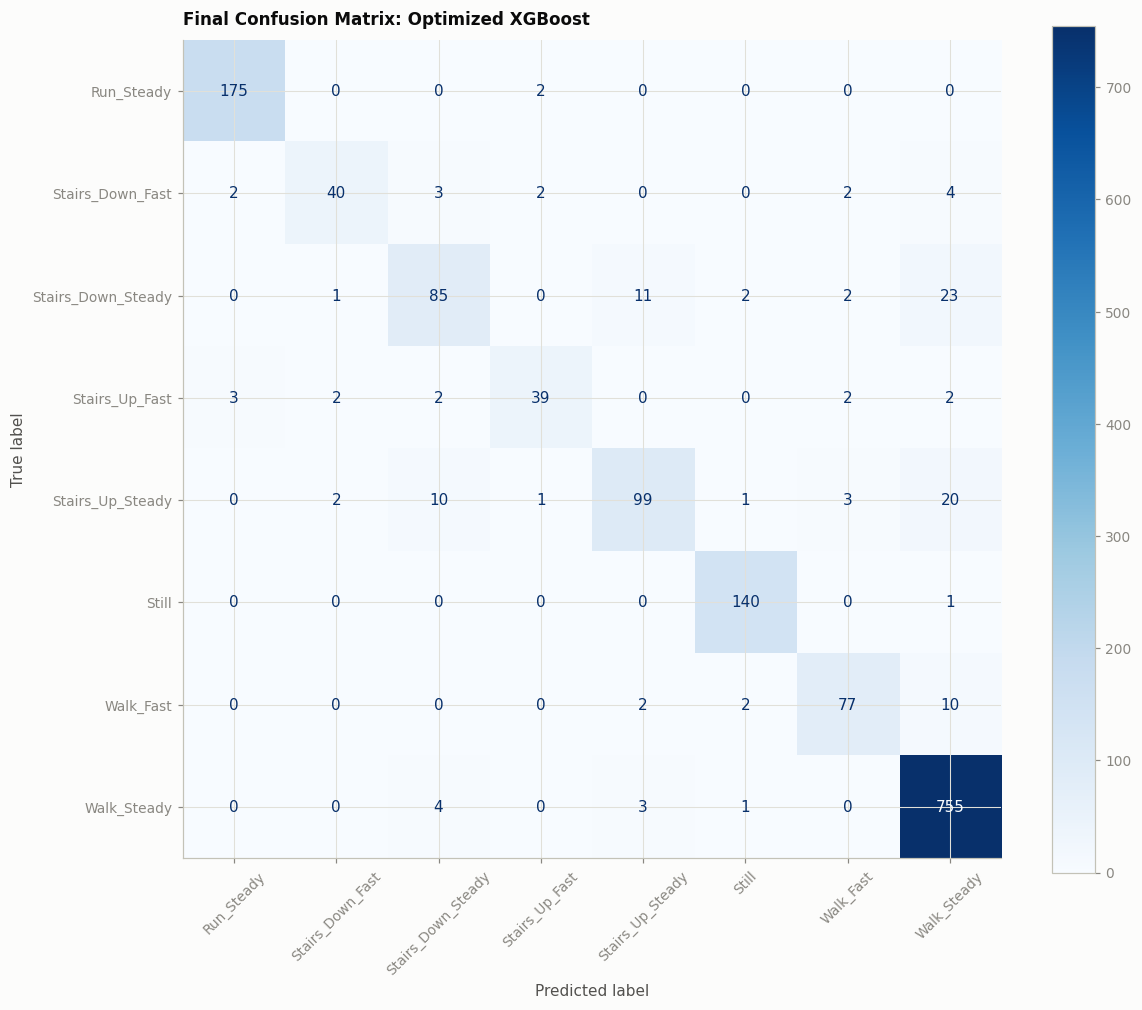

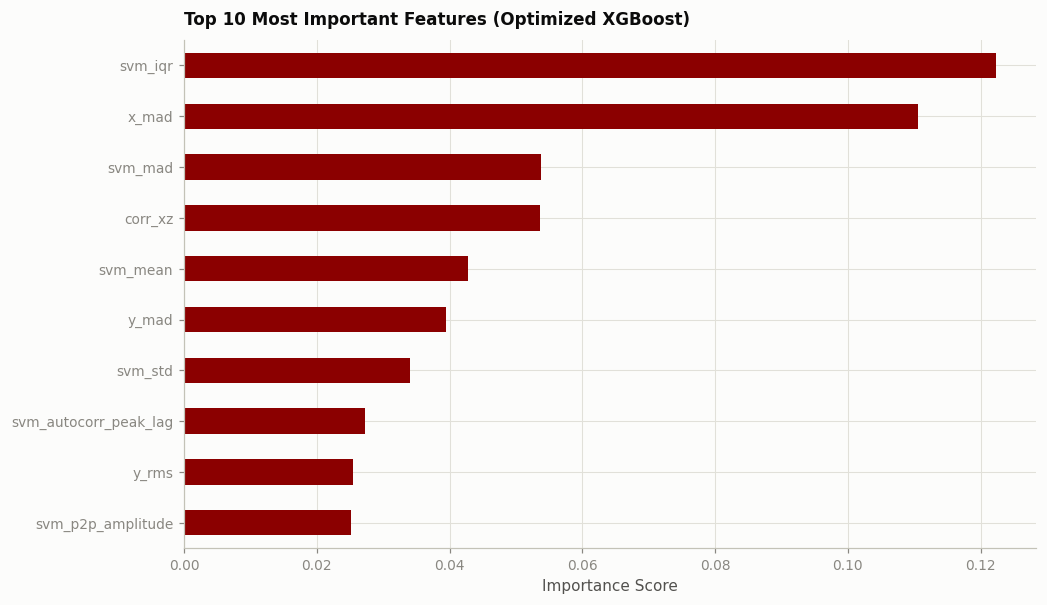

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 1. Get the best parameters found in the previous Optuna cell
# FIXED: study is the variable name generated by the Optuna cell
best_params_xgb = study.best_params

# 2. Create the final model with these parameters
final_clf_xgb = XGBClassifier(
    **best_params_xgb,
    n_jobs=-1,
    random_state=42
)

# 3. Prepare features and target
features_to_use = [col for col in process_df.columns if col not in ['y_label', 'source_file', 'spec_entropy']]
X = process_df[features_to_use]
y = process_df['y_label']

# 4. Encode string labels to numerical labels for XGBoost
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# 5. Split data (80% train, 20% test)
X_train, X_test, y_train_encoded, y_test_encoded = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print("\n--- Training Optimized XGBoost Model ---")
final_clf_xgb.fit(X_train, y_train_encoded)

def get_report_df(y_true, y_pred, title):
    report = classification_report(y_true, y_pred, output_dict=True)
    df = pd.DataFrame(report).transpose()
    return df

# 6. Evaluation
y_pred_xgb_encoded = final_clf_xgb.predict(X_test)
y_true_labels_test = label_encoder.inverse_transform(y_test_encoded)
y_pred_xgb_labels = label_encoder.inverse_transform(y_pred_xgb_encoded)

y_pred_train_xgb_encoded = final_clf_xgb.predict(X_train)
y_true_labels_train = label_encoder.inverse_transform(y_train_encoded)
y_pred_train_xgb_labels = label_encoder.inverse_transform(y_pred_train_xgb_encoded)

print("\nClassification Report Train:")
display(get_report_df(y_true_labels_train, y_pred_train_xgb_labels, "Train").style.background_gradient(cmap='Greens', subset=['f1-score']))

print("\nClassification Report Test:")
display(get_report_df(y_true_labels_test, y_pred_xgb_labels, "Test").style.background_gradient(cmap='Blues', subset=['f1-score']))

# 7. Plot Confusion Matrix
fig, ax = plt.subplots(figsize=(12, 10))
ConfusionMatrixDisplay.from_predictions(y_true_labels_test, y_pred_xgb_labels, ax=ax, cmap='Blues', xticks_rotation=45)
plt.title('Final Confusion Matrix: Optimized XGBoost')
plt.show()

# 8. Feature Importance
importances_xgb = pd.Series(final_clf_xgb.feature_importances_, index=features_to_use).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
importances_xgb.head(10).plot(kind='barh', color='darkred')
plt.title('Top 10 Most Important Features (Optimized XGBoost)')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.show()

#### Unknow Activity Recognize

##### Strategy for 'Unknown' Classification

Instead of forcing the Random Forest to pick one of your training labels, you can use the confidence scores.

1. **Get Probabilities**: Use `final_clf_xgb.predict_proba(X_test)` to get an array where each row represents the probability (from 0 to 1) for every possible activity.
2. **Find the Maximum**: For each row, identify the highest probability score.
3. **Apply a Threshold**: If that maximum score is less than, say, 0.60 (60%), you label that window as `'Unknown'`. Otherwise, you keep the predicted label.


In [ ]:
import numpy as np

# 1. Get the probabilities for each class using the test set (X_test)
# Hint: Use the method that sounds like 'predict probability'
probs = final_clf_xgb.predict_proba(X_test)

# 2. Find the maximum probability for each individual prediction
max_probs = np.max(probs, axis=1)

# 3. Define your threshold
threshold = 0.40

# 4. Count how many fall below the threshold
unknown_count = np.sum(max_probs < threshold)
total_count = len(max_probs)

print(f"Windows below {threshold*100}% confidence: {unknown_count} out of {total_count}")
print(f"Percentage of 'Unknown' data: {(unknown_count/total_count)*100:.2f}%")

Windows below 40.0% confidence: 32 out of 1724
Percentage of 'Unknown' data: 1.86%


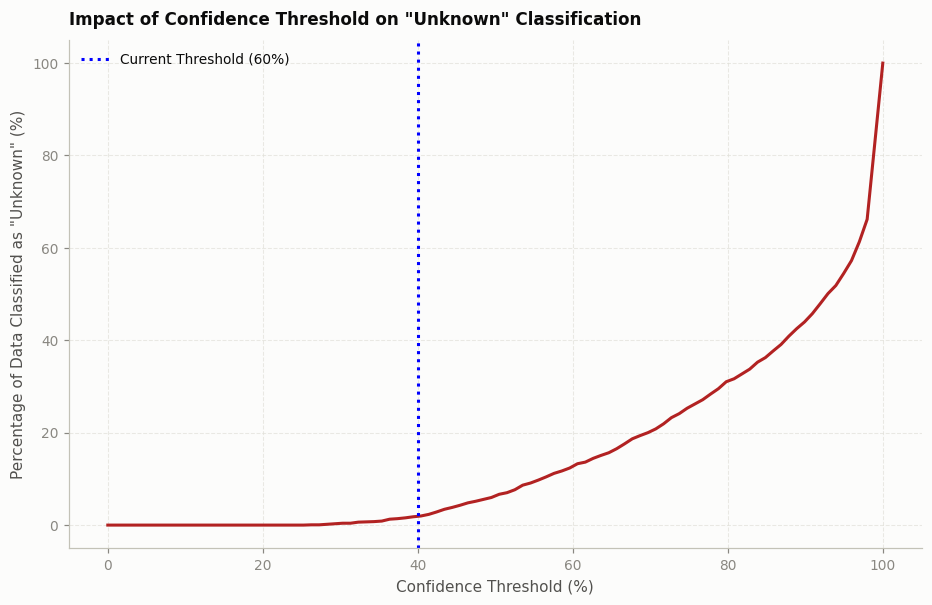

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Create a range of thresholds from 0.0 to 1.0
thresholds = np.linspace(0, 1, 100)

# 2. Calculate the percentage of 'Unknown' for each threshold
# Hint: You can use a list comprehension or a loop to repeat the logic from the previous cell
unknown_percentages = [
    (np.sum(max_probs < t) / len(max_probs)) * 100
    for t in thresholds
]

# 3. Plot the results
plt.figure(figsize=(10, 6))
plt.plot(thresholds * 100, unknown_percentages, color='firebrick', linewidth=2)
plt.title('Impact of Confidence Threshold on "Unknown" Classification')
plt.xlabel('Confidence Threshold (%)')
plt.ylabel('Percentage of Data Classified as "Unknown" (%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.axvline(x=40, color='blue', linestyle=':', label='Current Threshold (60%)')
plt.legend()
plt.show()

#### Save model to disk

In [ ]:
import joblib
from pathlib import Path

# 1. Define the save path in Google Drive
# We will use .json or .ubs for native XGBoost saving to ensure no corruption
MODEL_SAVE_PATH = Path(ROOT) / "final_optimized_xgb_model.json"

# 2. Save the model using XGBoost's native method
# Native saving is more robust than joblib/pickle for XGBoost boosters
try:
    final_clf_xgb.save_model(MODEL_SAVE_PATH)
    print(f"✅ Model successfully saved natively to: {MODEL_SAVE_PATH}")
except Exception as e:
    print(f"❌ Error saving the model: {e}")

# 3. Instruction to reload the model later:
# import xgboost as xgb
# loaded_model = xgb.XGBClassifier()
# loaded_model.load_model(MODEL_SAVE_PATH)

✅ Model successfully saved natively to: /content/drive/MyDrive/final_optimized_xgb_model.json


### Rocket Model

#### Data Loading for genrating feature with rocket

In [ ]:
import os
import numpy as np
import pandas as pd
from scipy.signal import resample
# ─── Windowing parameters ───────────────────────────────────────────────────
# Target window duration in seconds; actual sample count depends on each file's Hz
WINDOW_DURATION = 2.0   # seconds per window
OVERLAP         = 0.5   # fraction of window to overlap between consecutive windows (changed from 1.0)
# All windows are resampled to this fixed length so ROCKET gets uniform input.
# 500 samples = 1 second at the ~500 Hz files; 100-Hz files are upsampled.
TARGET_LEN = 500        # fixed timepoints per window fed to ROCKET

# Accelerometer axis columns (X, Y, Z)
ACCEL_COLS = ['Acceleration x (m/s^2)', 'Acceleration y (m/s^2)', 'Acceleration z (m/s^2)']
def detect_sampling_rate(df, time_col='Time (s)', n_samples=20):
    """Estimate Hz from the median time-step of the first n_samples rows."""
    times = df[time_col].values[:n_samples].astype(float)
    diffs = np.diff(times)
    median_dt = np.median(diffs[diffs > 0])  # guard against duplicate timestamps
    return 1.0 / median_dt


def load_and_window_data(
    data_dirs,
    window_duration=WINDOW_DURATION,
    overlap=OVERLAP,
    target_len=TARGET_LEN,
    accel_cols=ACCEL_COLS,
    time_col='Time (s)',
):
    """
    Load every CSV in data_dirs, auto-detect per-file sampling rate,
    split into 1-second windows, resample each window to target_len,
    and return a 3-D array ready for ROCKET: (N_windows, n_channels, target_len).

    Parameters
    ----------
    data_dirs       : dict  {label: folder_path}
    window_duration : float Desired window length in seconds (default 1.0)
    overlap         : float Fraction of window overlap (default 0.5 = 50%)
    target_len      : int   Fixed output length after resampling (default 500)
    accel_cols      : list  The three X/Y/Z column names
    time_col        : str   Name of the timestamp column

    Returns
    -------
    X : np.ndarray  float32  shape (N_windows, 3, target_len)
    y : np.ndarray  str      shape (N_windows,)
    """
    all_windows = []
    all_labels  = []

    for label, folder in data_dirs.items():
        if not os.path.isdir(folder):
            print(f"[SKIP] Folder not found: {folder}")
            continue

        csv_files = sorted(f for f in os.listdir(folder) if f.lower().endswith('.csv'))
        windows_for_label = 0

        for fname in csv_files:
            fpath = os.path.join(folder, fname)
            try:
                df = pd.read_csv(fpath)

                # Validate required columns
                required = accel_cols + [time_col]
                missing = [c for c in required if c not in df.columns]
                if missing:
                    print(f"  [WARN] {fname}: missing columns {missing} — skipped")
                    continue

                # ── Auto-detect sampling rate from Time column ──────────────────
                hz = detect_sampling_rate(df, time_col=time_col)
                window_size = round(hz * window_duration)  # samples for 1 second
                step_size   = round(window_size * (1 - overlap))

                # Ensure step_size is at least 1 to prevent infinite loops
                if step_size < 1:
                    step_size = 1
                    print(f"  [WARN] {fname}: Adjusted step_size to 1 to prevent infinite loop. Original calculated step_size was {round(window_size * (1 - overlap))}.")

                signal = df[accel_cols].values   # shape: (T, 3)
                T = len(signal)

                # ── Sliding window ──────────────────────────────────────────────
                start = 0
                while start + window_size <= T:
                    window = signal[start : start + window_size, :]  # (window_size, 3)

                    # ── Resample to TARGET_LEN so all windows are the same size ──
                    if window_size != target_len:
                        window = resample(window, target_len, axis=0)

                    all_windows.append(window.T.astype(np.float32))  # (3, target_len)
                    all_labels.append(label)
                    windows_for_label += 1
                    start += step_size

            except Exception as e:
                print(f"  [ERROR] {fname}: {e}")

        print(f"[{label:<25}]  {len(csv_files)} files → {windows_for_label} windows")

    if not all_windows:
        raise RuntimeError("No windows were generated — check your DATA_DIRS paths!")

    X = np.stack(all_windows)  # (N_windows, 3, target_len)
    y = np.array(all_labels)
    return X, y


# ── Run ────────────────────────────────────────────────────────────────────────
X_windows, y_windows = load_and_window_data(DATA_DIRS)

print(f"\n✅ Total windows : {len(X_windows)}")
print(f"   Window shape  : {X_windows.shape}  (N_windows, channels, timepoints)")
print(f"\nClass distribution:")
unique, counts = np.unique(y_windows, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  {cls:<25} {cnt} windows")

[Still                    ]  24 files → 740 windows
[Run_Steady               ]  13 files → 962 windows
[Stairs_Down_Fast         ]  21 files → 275 windows
[Stairs_Down_Steady       ]  32 files → 655 windows
[Stairs_Up_Fast           ]  17 files → 261 windows
[Stairs_Up_Steady         ]  35 files → 729 windows
[Walk_Fast                ]  15 files → 534 windows
[Walk_Steady              ]  34 files → 4764 windows

✅ Total windows : 8920
   Window shape  : (8920, 3, 500)  (N_windows, channels, timepoints)

Class distribution:
  Run_Steady                962 windows
  Stairs_Down_Fast          275 windows
  Stairs_Down_Steady        655 windows
  Stairs_Up_Fast            261 windows
  Stairs_Up_Steady          729 windows
  Still                     740 windows
  Walk_Fast                 534 windows
  Walk_Steady               4764 windows


#### Model Traning

In [ ]:
from sklearn.model_selection import train_test_split
from sktime.transformations.panel.rocket import MiniRocketMultivariate
from sklearn.linear_model import RidgeClassifierCV
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# 1. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_windows, y_windows, test_size=0.2, random_state=42, stratify=y_windows
)

# 2. Transform with 10,000 kernels
# High kernel count captures complex dynamics; needs very high regularization to generalize
rocket = MiniRocketMultivariate(num_kernels=10000, random_state=42)
rocket.fit(X_train)
X_train_transform = rocket.transform(X_train)
X_test_transform  = rocket.transform(X_test)

# 3. Aggressive Regularization Search (Round 2)
# The model selected alpha=1.0 (the minimum) and hit 100% train accuracy.
# We shift the search window higher to force the training accuracy below 1.0.
alphas = np.logspace(2, 10, 50)
clf = RidgeClassifierCV(alphas=alphas, scoring='f1_macro')
clf.fit(X_train_transform, y_train)

print(f"Best Alpha selected: {clf.alpha_:.2e}")

# 4. Final Evaluation
y_pred_test = clf.predict(X_test_transform)
y_pred_train = clf.predict(X_train_transform)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print(f"\n--- Accuracy Check ---")
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")
print(f"Generalization Gap: {(train_acc - test_acc)*100:.2f}%")

print("\n--- Detailed Test Classification Report ---")
print(classification_report(y_test, y_pred_test, zero_division=0))

Best Alpha selected: 1.00e+02

--- Accuracy Check ---
Train Accuracy: 0.9326
Test Accuracy:  0.8991
Generalization Gap: 3.35%

--- Detailed Test Classification Report ---
                    precision    recall  f1-score   support

        Run_Steady       0.97      0.98      0.98       192
  Stairs_Down_Fast       0.88      0.84      0.86        55
Stairs_Down_Steady       0.82      0.74      0.78       131
    Stairs_Up_Fast       0.76      0.56      0.64        52
  Stairs_Up_Steady       0.83      0.66      0.73       146
             Still       0.97      0.98      0.97       148
         Walk_Fast       0.88      0.57      0.69       107
       Walk_Steady       0.90      0.99      0.94       953

          accuracy                           0.90      1784
         macro avg       0.88      0.79      0.83      1784
      weighted avg       0.90      0.90      0.89      1784



#### Unknow Activity Recogination

##### Isoleation Forest

In [ ]:
from sklearn.ensemble import IsolationForest
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

print("--- Training Anomaly Detector (Isolation Forest) ---")
# הגדרת מודל זיהוי החריגים
# contamination = 0.02 מניח שיש כ-2% רעש טבעי בנתוני האימון שלנו
# This parameter explicitly tells the Isolation Forest model to expect approximately 2% of the data to be outliers.
iso_forest = IsolationForest(contamination=0.002, random_state=42)

# אימון על נתוני האימון שעברו טרנספורמציה ב-ROCKET (X_train_transform)
iso_forest.fit(X_train_transform)

print("\n--- Evaluating Test Set with UNKNOWN Detection ---")
# 1. התחזיות הרגילות של מודל ה-Ridge שלך
y_pred_base = clf.predict(X_test_transform)

# 2. זיהוי אנומליות בסט הבדיקה
# מחזיר 1 לדגימות תקינות, ו--1 לדגימות חריגות
anomaly_scores = iso_forest.predict(X_test_transform)

# 3. יצירת מערך תחזיות סופי: דורסים את התחזית הרגילה עם 'Unknown' במקרה של אנומליה
y_pred_with_unknown = np.where(anomaly_scores == -1, 'Unknown', y_pred_base)

# הדפסת פיזור המחלקות החדש
print("New Class Distribution in Predictions:")
unique, counts = np.unique(y_pred_with_unknown, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"{cls:<25} {cnt} windows")

# עדכון רשימת התוויות כדי שהדוח יציג גם את Unknown
all_labels = list(np.unique(y_test)) + ['Unknown']

print(f"\nAccuracy (with Unknown handling): {accuracy_score(y_test, y_pred_with_unknown):.4f}")
print(classification_report(y_test, y_pred_with_unknown, labels=all_labels, zero_division=0))

--- Training Anomaly Detector (Isolation Forest) ---

--- Evaluating Test Set with UNKNOWN Detection ---
New Class Distribution in Predictions:
Run_Steady                194 windows
Stairs_Down_Fast          52 windows
Stairs_Down_Steady        118 windows
Stairs_Up_Fast            37 windows
Stairs_Up_Steady          116 windows
Still                     150 windows
Unknown                   2 windows
Walk_Fast                 69 windows
Walk_Steady               1046 windows

Accuracy (with Unknown handling): 0.8980
                    precision    recall  f1-score   support

        Run_Steady       0.97      0.98      0.97       192
  Stairs_Down_Fast       0.88      0.84      0.86        55
Stairs_Down_Steady       0.82      0.74      0.78       131
    Stairs_Up_Fast       0.76      0.54      0.63        52
  Stairs_Up_Steady       0.83      0.66      0.73       146
             Still       0.97      0.98      0.97       148
         Walk_Fast       0.88      0.57      0.69      

#### Save model to disk

In [ ]:
import joblib
from pathlib import Path

# 1. Define the save paths in Google Drive
# Using the previously defined ROOT variable for consistency
ROCKET_SAVE_PATH = Path(ROOT) / "minirocket_transformer.joblib"
MODEL_SAVE_PATH = Path(ROOT) / "ridge_classifier_rocket.joblib"
ANOMALY_SAVE_PATH = Path(ROOT) / "isolation_forest_anomaly_detector.joblib"
PIPELINE_SAVE_PATH = Path(ROOT) / "rocket_pipeline_complete.joblib"

try:
    # Save individually
    joblib.dump(rocket, ROCKET_SAVE_PATH)
    joblib.dump(clf, MODEL_SAVE_PATH)
    joblib.dump(iso_forest, ANOMALY_SAVE_PATH)

    # Save as a combined dictionary for easier loading as a 'pipeline'
    pipeline = {
        'transformer': rocket,
        'classifier': clf,
        'anomaly_detector': iso_forest
    }
    joblib.dump(pipeline, PIPELINE_SAVE_PATH)

    print(f"✅ MiniRocket Transformer saved to: {ROCKET_SAVE_PATH}")
    print(f"✅ Ridge Classifier saved to: {MODEL_SAVE_PATH}")
    print(f"✅ Isolation Forest saved to: {ANOMALY_SAVE_PATH}")
    print(f"✅ Complete pipeline (with Anomaly Detector) saved to: {PIPELINE_SAVE_PATH}")

except Exception as e:
    print(f"❌ Error saving the models: {e}")

# --- Instructions to reload later ---
# data = joblib.load(PIPELINE_SAVE_PATH)
# rocket_loaded = data['transformer']
# clf_loaded = data['classifier']
# iso_loaded = data['anomaly_detector']
#
# X_transformed = rocket_loaded.transform(X_new)
# anomaly_mask = iso_loaded.predict(X_transformed)
# raw_preds = clf_loaded.predict(X_transformed)
# final_preds = np.where(anomaly_mask == -1, 'Unknown', raw_preds)

✅ MiniRocket Transformer saved to: /content/drive/MyDrive/MLRecords/minirocket_transformer.joblib
✅ Ridge Classifier saved to: /content/drive/MyDrive/MLRecords/ridge_classifier_rocket.joblib
✅ Isolation Forest saved to: /content/drive/MyDrive/MLRecords/isolation_forest_anomaly_detector.joblib
✅ Complete pipeline (with Anomaly Detector) saved to: /content/drive/MyDrive/MLRecords/rocket_pipeline_complete.joblib


## **Detection of Accelerate, Decelerate and Stable**

### Lib and prepration

In [ ]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.frameon": True,
    "legend.framealpha": 0.9,
})

AXIS_COLORS = {"x": "#D64545", "y": "#3F8F3F", "z": "#3564C0"}
STATE_COLORS = {"Accelerate": "#4CAF50", "Decelerate": "#E05252", "Stable": "#B0B0B0"}
RAW_COLOR, SMOOTH_COLOR, DELTA_COLOR = "#B0B0B0", "#1F3B73", "#7A3FA0"

DATA_DIR = Path("/content/drive/MyDrive/accleoration")

To reproduce the "walk → speed up → run → slow down" scenario from real sensor data, three
recordings are stitched end-to-end into one continuous timeline:

| Order | File | Represents |
|---|---|---|
| 1 | `waking_Accelerate.csv` | Walking, gradually speeding up |
| 2 | `running_Accelerate.csv` | Continuing to accelerate into a run |
| 3 | `running_Decelerate.csv` | Running, then slowing down |

In [ ]:
def load_and_stitch(data_dir, files_and_labels):
    segments = []
    time_offset = 0.0
    for filename, label in files_and_labels:
        raw = pd.read_csv(data_dir / filename, encoding="utf-8-sig")
        raw = raw.iloc[:, :4].copy()
        raw.columns = ["timestamp", "x", "y", "z"]

        sample_period = raw["timestamp"].diff().median()
        raw["timestamp"] = raw["timestamp"] - raw["timestamp"].iloc[0] + time_offset
        raw["activity_segment"] = label
        time_offset = raw["timestamp"].iloc[-1] + sample_period

        segments.append(raw)
    return pd.concat(segments, ignore_index=True)


REAL_SEGMENTS = [
    ("waking_Accelerate.csv", "Walking (speeding up)"),
    ("running_Accelerate.csv", "Running (accelerating)"),
    ("running_Decelerate.csv", "Running (decelerating)"),
]

df_real = load_and_stitch(DATA_DIR, REAL_SEGMENTS)
fs_real = 1 / df_real["timestamp"].diff().median()

print(f"Samples: {len(df_real):,}   Duration: {df_real['timestamp'].iloc[-1]:.1f} s   "
      f"Sampling rate: {fs_real:.1f} Hz")
df_real.head()

Samples: 9,263   Duration: 20.5 s   Sampling rate: 451.8 Hz


,timestamp,x,y,z,activity_segment
0,0.000000,-1.890330,2.388037,7.408179,Walking (speeding up)
1,0.002215,-1.933401,2.359323,7.470392,Walking (speeding up)
2,0.004428,-1.942972,2.330609,7.580462,Walking (speeding up)
3,0.006641,-1.952543,2.316252,7.709674,Walking (speeding up)
4,0.008854,-1.976472,2.287539,7.848458,Walking (speeding up)


### Feature Enginnering
Four steps turn the raw tri-axial stream into a per-timestamp trend label:

1. **Magnitude** `‖a‖ = sqrt(x² + y² + z²)` — orientation-independent, so it doesn't matter how the phone is carried.
2. **Smoothing** — a centered rolling mean over a **2.5 s** window averages out individual footstrike spikes while still tracking genuine changes in intensity.
3. **Delta** — `smoothed.diff(periods=Δ)`, where `Δ` corresponds to **1 s**. A single-sample `.diff()` on an already-smoothed signal is dominated by the one sample entering/leaving the rolling window and stays inside the noise floor; differencing over a ~1 s lag instead measures the smoothed signal's slope over a meaningful stretch of time, which is what "accelerating" or "decelerating" actually means physically.
4. **Thresholding** — timestamps are labeled `Accelerate` / `Decelerate` when `delta` exceeds `±k·σ(delta)` (k = 0.6 by default), and `Stable` otherwise. Using a multiple of the delta's own standard deviation keeps the thresholds self-calibrating across recordings with different noise levels, rather than hard-coding a fixed physical unit.

In [ ]:
def compute_magnitude(df):
    return np.sqrt(df["x"] ** 2 + df["y"] ** 2 + df["z"] ** 2)


def smooth_magnitude(magnitude, fs, window_s=2.5):
    window = max(1, int(round(window_s * fs)))
    return magnitude.rolling(window=window, center=True, min_periods=1).mean()


def compute_delta(smoothed, fs, lag_s=1.0):
    periods = max(1, int(round(lag_s * fs)))
    return smoothed.diff(periods=periods)


def classify_trend(delta, pos_threshold, neg_threshold):
    return np.select(
        [delta > pos_threshold, delta < neg_threshold],
        ["Accelerate", "Decelerate"],
        default="Stable",
    )


def apply_pipeline(df, fs, window_s=2.5, lag_s=1.0, k=0.6):
    df = df.copy()
    df["magnitude"] = compute_magnitude(df)
    df["magnitude_smooth"] = smooth_magnitude(df["magnitude"], fs, window_s)
    df["delta"] = compute_delta(df["magnitude_smooth"], fs, lag_s)

    pos_threshold = k * df["delta"].std(skipna=True)
    neg_threshold = -pos_threshold
    df["state"] = classify_trend(df["delta"].fillna(0.0), pos_threshold, neg_threshold)
    return df, pos_threshold, neg_threshold


df_real, pos_thr_real, neg_thr_real = apply_pipeline(df_real, fs_real)

print(f"Thresholds: +{pos_thr_real:.4f} / {neg_thr_real:.4f} m/s^2 per second")
df_real["state"].value_counts()

Thresholds: +2.2964 / -2.2964 m/s^2 per second


,count
state,
Stable,5039
Accelerate,2264
Decelerate,1960


#### Diagnostic Figure

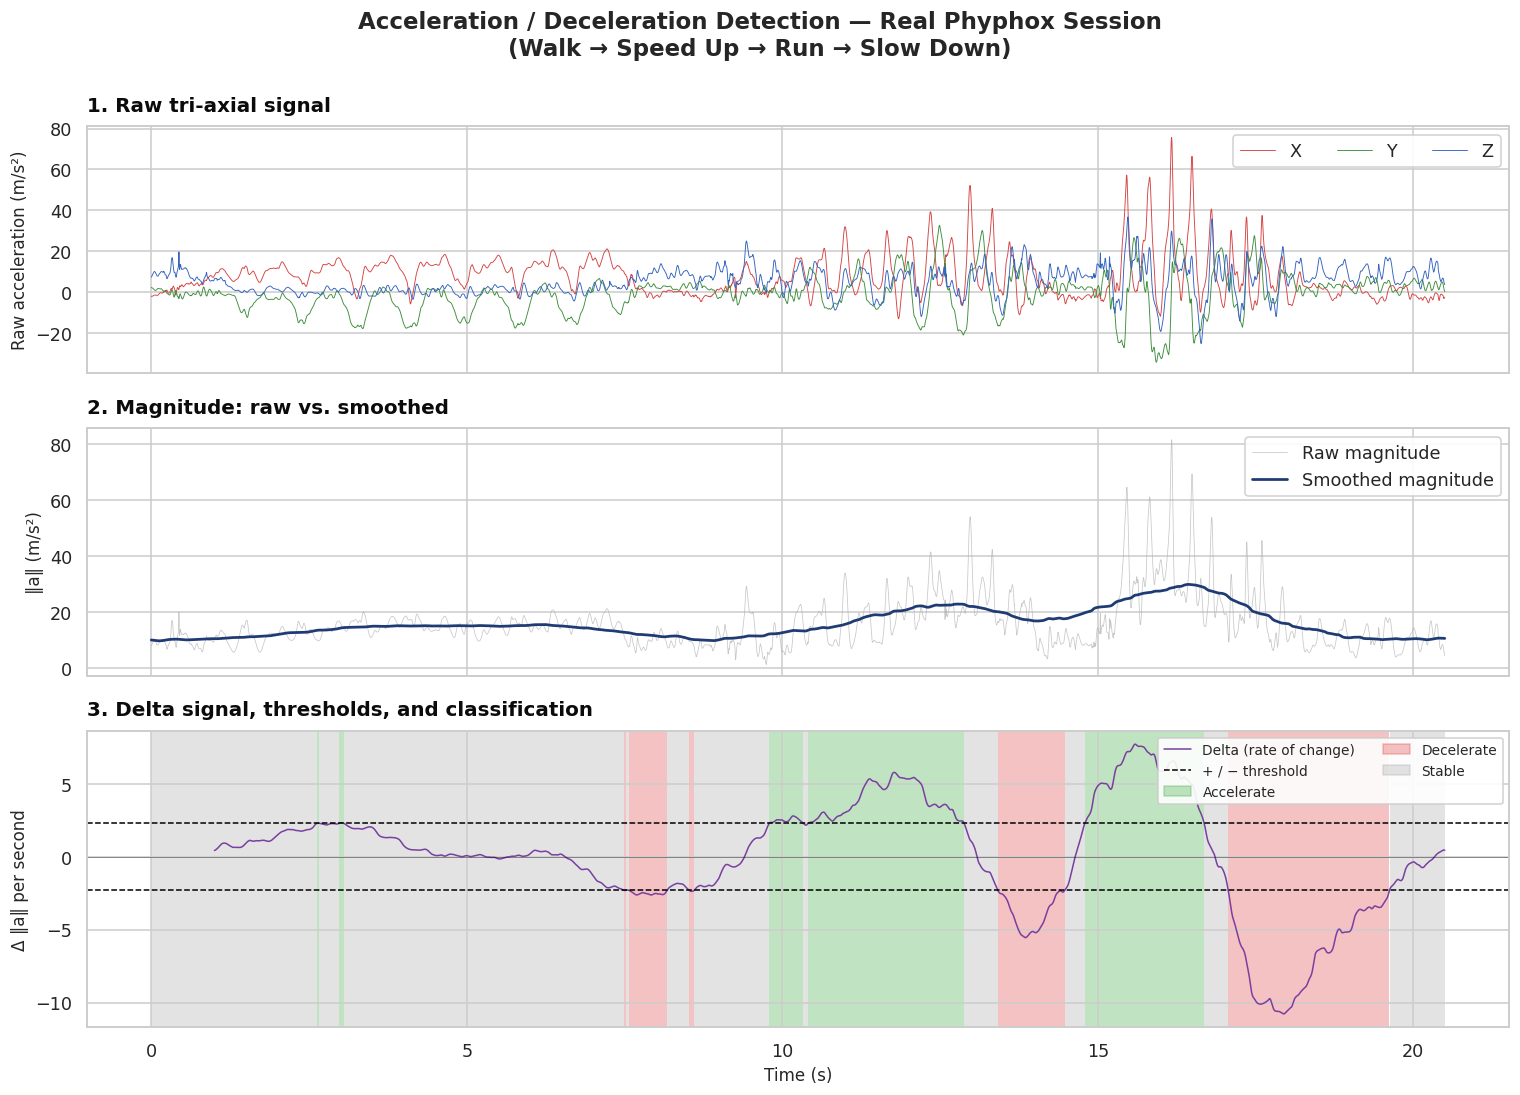

In [ ]:
def shade_state_regions(ax, timestamps, states):
    states = np.asarray(states)
    change_points = np.flatnonzero(states[1:] != states[:-1]) + 1
    boundaries = [0, *change_points, len(states)]
    for start, end in zip(boundaries[:-1], boundaries[1:]):
        ax.axvspan(
            timestamps.iloc[start], timestamps.iloc[end - 1],
            color=STATE_COLORS[states[start]], alpha=0.35, lw=0, zorder=0,
        )


def plot_trend_figure(df, pos_threshold, neg_threshold, title):
    fig, (ax_raw, ax_mag, ax_delta) = plt.subplots(
        3, 1, figsize=(14, 10), sharex=True,
        gridspec_kw={"height_ratios": [1, 1, 1.2]},
    )

    for axis in ("x", "y", "z"):
        ax_raw.plot(df["timestamp"], df[axis], color=AXIS_COLORS[axis], lw=0.6, label=axis.upper())
    ax_raw.set_ylabel("Raw acceleration (m/s²)")
    ax_raw.set_title("1. Raw tri-axial signal")
    ax_raw.legend(loc="upper right", ncol=3)

    ax_mag.plot(df["timestamp"], df["magnitude"], color=RAW_COLOR, lw=0.5, alpha=0.7, label="Raw magnitude")
    ax_mag.plot(df["timestamp"], df["magnitude_smooth"], color=SMOOTH_COLOR, lw=1.8, label="Smoothed magnitude")
    ax_mag.set_ylabel("‖a‖ (m/s²)")
    ax_mag.set_title("2. Magnitude: raw vs. smoothed")
    ax_mag.legend(loc="upper right")

    shade_state_regions(ax_delta, df["timestamp"], df["state"].to_numpy())
    ax_delta.plot(df["timestamp"], df["delta"], color=DELTA_COLOR, lw=1.0, label="Delta (rate of change)")
    ax_delta.axhline(pos_threshold, color="black", ls="--", lw=1.0, label="+ / − threshold")
    ax_delta.axhline(neg_threshold, color="black", ls="--", lw=1.0)
    ax_delta.axhline(0, color="black", lw=0.6, alpha=0.4)
    ax_delta.set_ylabel("Δ ‖a‖ per second")
    ax_delta.set_xlabel("Time (s)")
    ax_delta.set_title("3. Delta signal, thresholds, and classification")

    state_patches = [mpatches.Patch(color=c, alpha=0.35, label=s) for s, c in STATE_COLORS.items()]
    line_handles, line_labels = ax_delta.get_legend_handles_labels()
    ax_delta.legend(handles=line_handles + state_patches, loc="upper right", ncol=2, fontsize=9)

    fig.suptitle(title, fontsize=15, fontweight="bold", y=0.995)
    fig.tight_layout()
    return fig


fig_real = plot_trend_figure(
    df_real, pos_thr_real, neg_thr_real,
    "Acceleration / Deceleration Detection — Real Phyphox Session\n(Walk → Speed Up → Run → Slow Down)",
)
plt.show()

### Check on Inerval run data

Samples: 108,349   Duration: 220.0 s   Sampling rate: 479.6 Hz


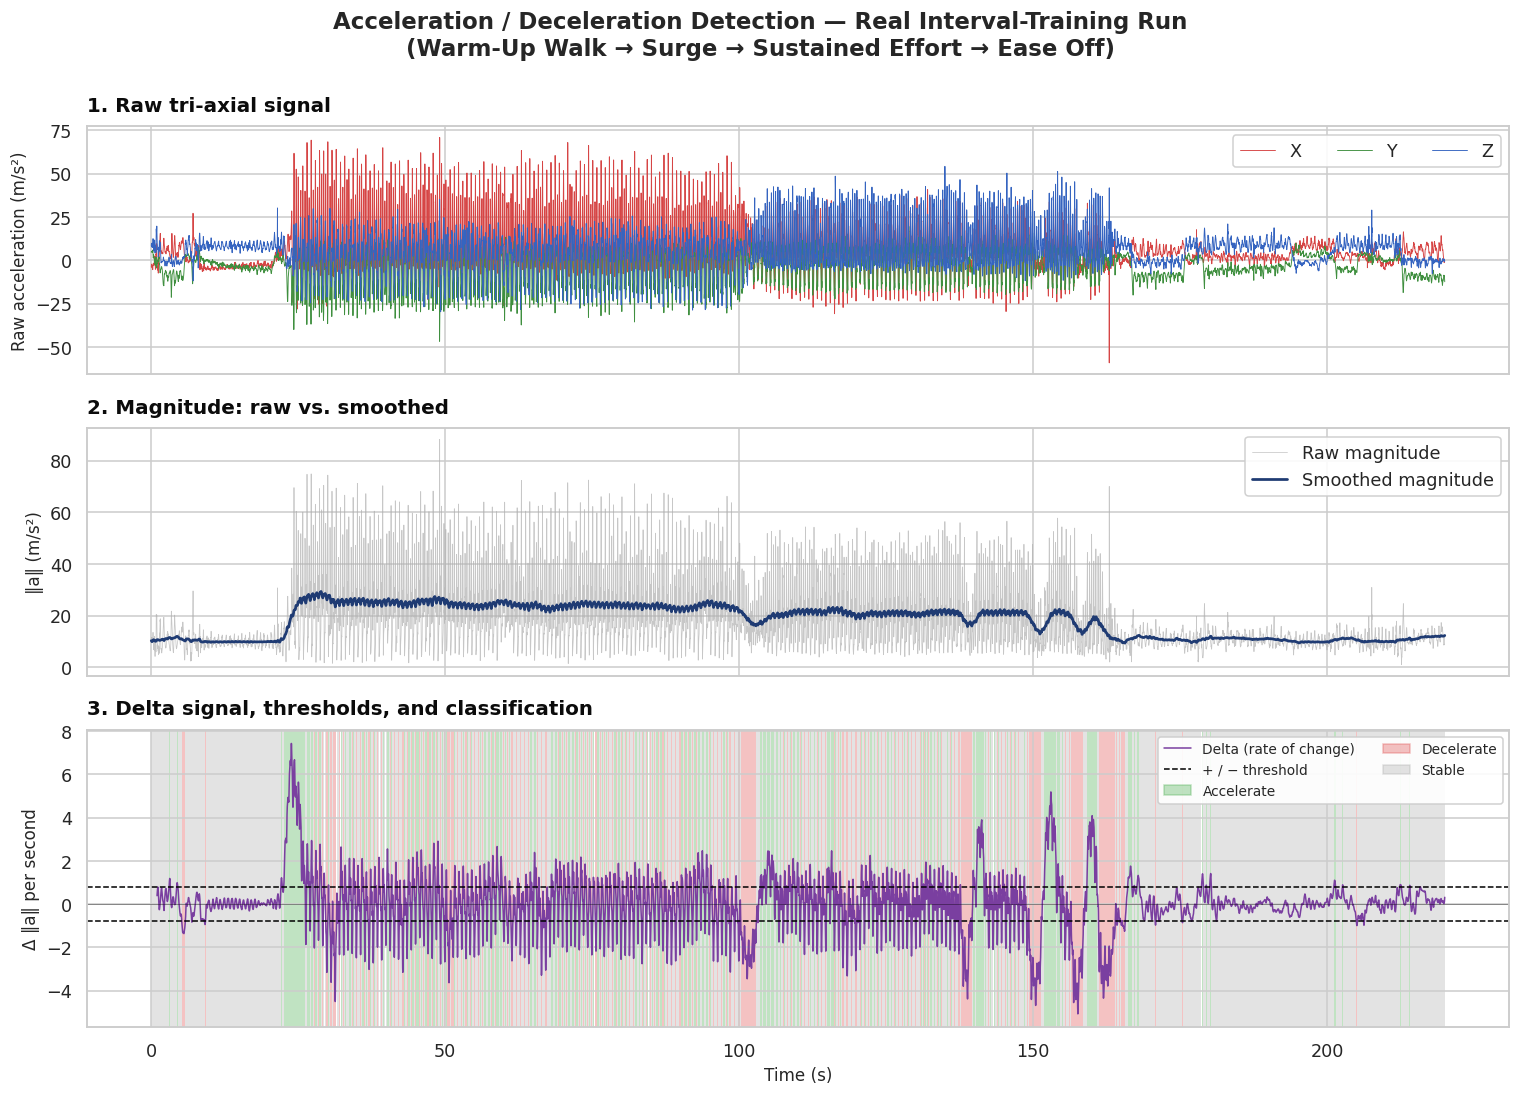

In [ ]:
INTERVALS_RUN_DIR = Path("/content/drive/MyDrive/RecordsCsvData4/Runs/IntervalsRun")
INTERVALS_RUN_FILE = "data_csv_20260702_211230.csv"
ANALYSIS_WINDOW_S = 220  # covers one full warm-up -> surge -> ease-off cycle

raw_intervals = pd.read_csv(INTERVALS_RUN_DIR / INTERVALS_RUN_FILE, encoding="utf-8-sig")
raw_intervals = raw_intervals.iloc[:, :4].copy()
raw_intervals.columns = ["timestamp", "x", "y", "z"]

df_intervals = raw_intervals[raw_intervals["timestamp"] < ANALYSIS_WINDOW_S].reset_index(drop=True)
fs_intervals = 1 / df_intervals["timestamp"].diff().median()

print(f"Samples: {len(df_intervals):,}   Duration: {df_intervals['timestamp'].iloc[-1]:.1f} s   "
      f"Sampling rate: {fs_intervals:.1f} Hz")

df_intervals, pos_thr_intervals, neg_thr_intervals = apply_pipeline(df_intervals, fs_intervals)

fig_intervals = plot_trend_figure(
    df_intervals, pos_thr_intervals, neg_thr_intervals,
    "Acceleration / Deceleration Detection — Real Interval-Training Run\n(Warm-Up Walk → Surge → Sustained Effort → Ease Off)",
)
plt.show()

In [ ]:
def summarize_segments(df, min_duration_s=0.3):
    states = df["state"].to_numpy()
    change_points = np.flatnonzero(states[1:] != states[:-1]) + 1
    boundaries = [0, *change_points, len(states)]

    rows = []
    for start, end in zip(boundaries[:-1], boundaries[1:]):
        rows.append({
            "state": states[start],
            "start_s": df["timestamp"].iloc[start],
            "end_s": df["timestamp"].iloc[end - 1],
            "duration_s": df["timestamp"].iloc[end - 1] - df["timestamp"].iloc[start],
        })

    segments = pd.DataFrame(rows)
    return segments[segments["duration_s"] >= min_duration_s].reset_index(drop=True)
segments_intervals = summarize_segments(df_intervals, min_duration_s=1.5)
segments_intervals.round(2)

,state,start_s,end_s,duration_s
0,Stable,0.01,3.04,3.03
1,Stable,6.94,9.06,2.13
2,Stable,9.23,22.04,12.81
3,Accelerate,22.54,26.18,3.64
4,Decelerate,100.26,102.93,2.67
5,Decelerate,137.71,139.41,1.70
6,Decelerate,149.27,151.36,2.09
7,Accelerate,151.89,153.93,2.04
8,Decelerate,156.47,158.53,2.06
9,Accelerate,159.12,160.83,1.71
